# Wall Segmentation

**Stage 6**  - Segment each room's wall cloud into individual planar walls and flatten them into 2D images.

**Input:** Room wall clouds (`.ply`) from any upstream wall-assignment stage (geometric, SAM, or geometric+SAM).

**Output:** Per-room wall images (black = wall surface, white = void) + `wall_meta.json` with wall geometry.

The wall images are consumed by the next notebook (door/window detection).

In [7]:
import sys, os, glob, logging

def _find_root():
    d = os.path.abspath('')
    while True:
        if os.path.isfile(os.path.join(d, 'pyproject.toml')):
            return d
        p = os.path.dirname(d)
        if p == d:
            return os.path.abspath('')
        d = p

PROJECT_ROOT = _find_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path = [p for p in sys.path if not p.endswith('/src') and not p.endswith('\\src')]
for mod in list(sys.modules):
    if mod == 'scan2bim' or mod.startswith('scan2bim.'):
        del sys.modules[mod]

logging.basicConfig(level=logging.INFO, format='%(message)s')
print('Project root:', PROJECT_ROOT)

Project root: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM


In [8]:
import scan2bim
from scan2bim import artifacts as A

CFG = scan2bim.load_config(start=PROJECT_ROOT)
print(f'Input cloud: {CFG.file_path}')
print(f'Output root: {CFG.out_root}')
print(f'Wall image resolution: {CFG.flat_pixel_m} m/px')

Input cloud: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/data/area1.xyz
Output root: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out
Wall image resolution: 0.04 m/px


## Select upstream wall stage

Choose which method's wall clouds to process. Change `WALL_STAGE` to match your upstream run.

In [9]:
# Choose one:
WALL_STAGE = A.STAGE3          # geometric method
# WALL_STAGE = A.STAGE_SAM_WALLS  # pure-SAM method
# WALL_STAGE = A.STAGE5          # geometric + SAM method

wall_dir = A.load_stage_dir(CFG.out_root, WALL_STAGE)
room_clouds = sorted(glob.glob(os.path.join(wall_dir, 'room_*_walls.ply')))
print(f'Found {len(room_clouds)} room wall clouds in {WALL_STAGE}')
for p in room_clouds:
    print(f'  {os.path.basename(p)}')

Found 53 room wall clouds in stage3_walls
  room_01_walls.ply
  room_02_walls.ply
  room_03_walls.ply
  room_04_walls.ply
  room_05_walls.ply
  room_06_walls.ply
  room_07_walls.ply
  room_08_walls.ply
  room_09_walls.ply
  room_10_walls.ply
  room_11_walls.ply
  room_12_walls.ply
  room_13_walls.ply
  room_14_walls.ply
  room_15_walls.ply
  room_16_walls.ply
  room_17_walls.ply
  room_18_walls.ply
  room_19_walls.ply
  room_20_walls.ply
  room_21_walls.ply
  room_22_walls.ply
  room_23_walls.ply
  room_24_walls.ply
  room_25_walls.ply
  room_26_walls.ply
  room_27_walls.ply
  room_28_walls.ply
  room_29_walls.ply
  room_30_walls.ply
  room_31_walls.ply
  room_32_walls.ply
  room_33_walls.ply
  room_34_walls.ply
  room_35_walls.ply
  room_36_walls.ply
  room_37_walls.ply
  room_38_walls.ply
  room_39_walls.ply
  room_40_walls.ply
  room_41_walls.ply
  room_42_walls.ply
  room_43_walls.ply
  room_44_walls.ply
  room_45_walls.ply
  room_46_walls.ply
  room_47_walls.ply
  room_48_walls.pl

## Run wall segmentation

In [10]:
from scan2bim.wall_seg import run_wall_segmentation

out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, A.STAGE_WALL_SEG))
results = run_wall_segmentation(room_clouds, CFG, out_dir)

total = sum(len(v) for v in results.values())
print(f'\nTotal: {len(results)} rooms, {total} wall images')

Processing room_01
Vertical-surface points: 16631 / 21144 (78.7%)
Angle peaks: 2  at ['90.5', '0.5']
Walls found: 8
  room_01/: saved 8 wall images to /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_wall_seg/room_01
Processing room_02
Vertical-surface points: 61681 / 82338 (74.9%)
Angle peaks: 2  at ['90.5', '179.5']
Walls found: 7
  room_02/: saved 7 wall images to /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_wall_seg/room_02
Processing room_03
Vertical-surface points: 38417 / 47616 (80.7%)
Angle peaks: 2  at ['89.5', '179.5']
Walls found: 11
  room_03/: saved 11 wall images to /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_wall_seg/room_03
Processing room_04
Vertical-surface points: 26168 / 31362 (83.4%)
Angle peaks: 2  at ['89.5', '0.5']
Walls found: 6
  room_04/: saved 6 wall images to /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage


Total: 53 rooms, 326 wall images


## Visualize wall images

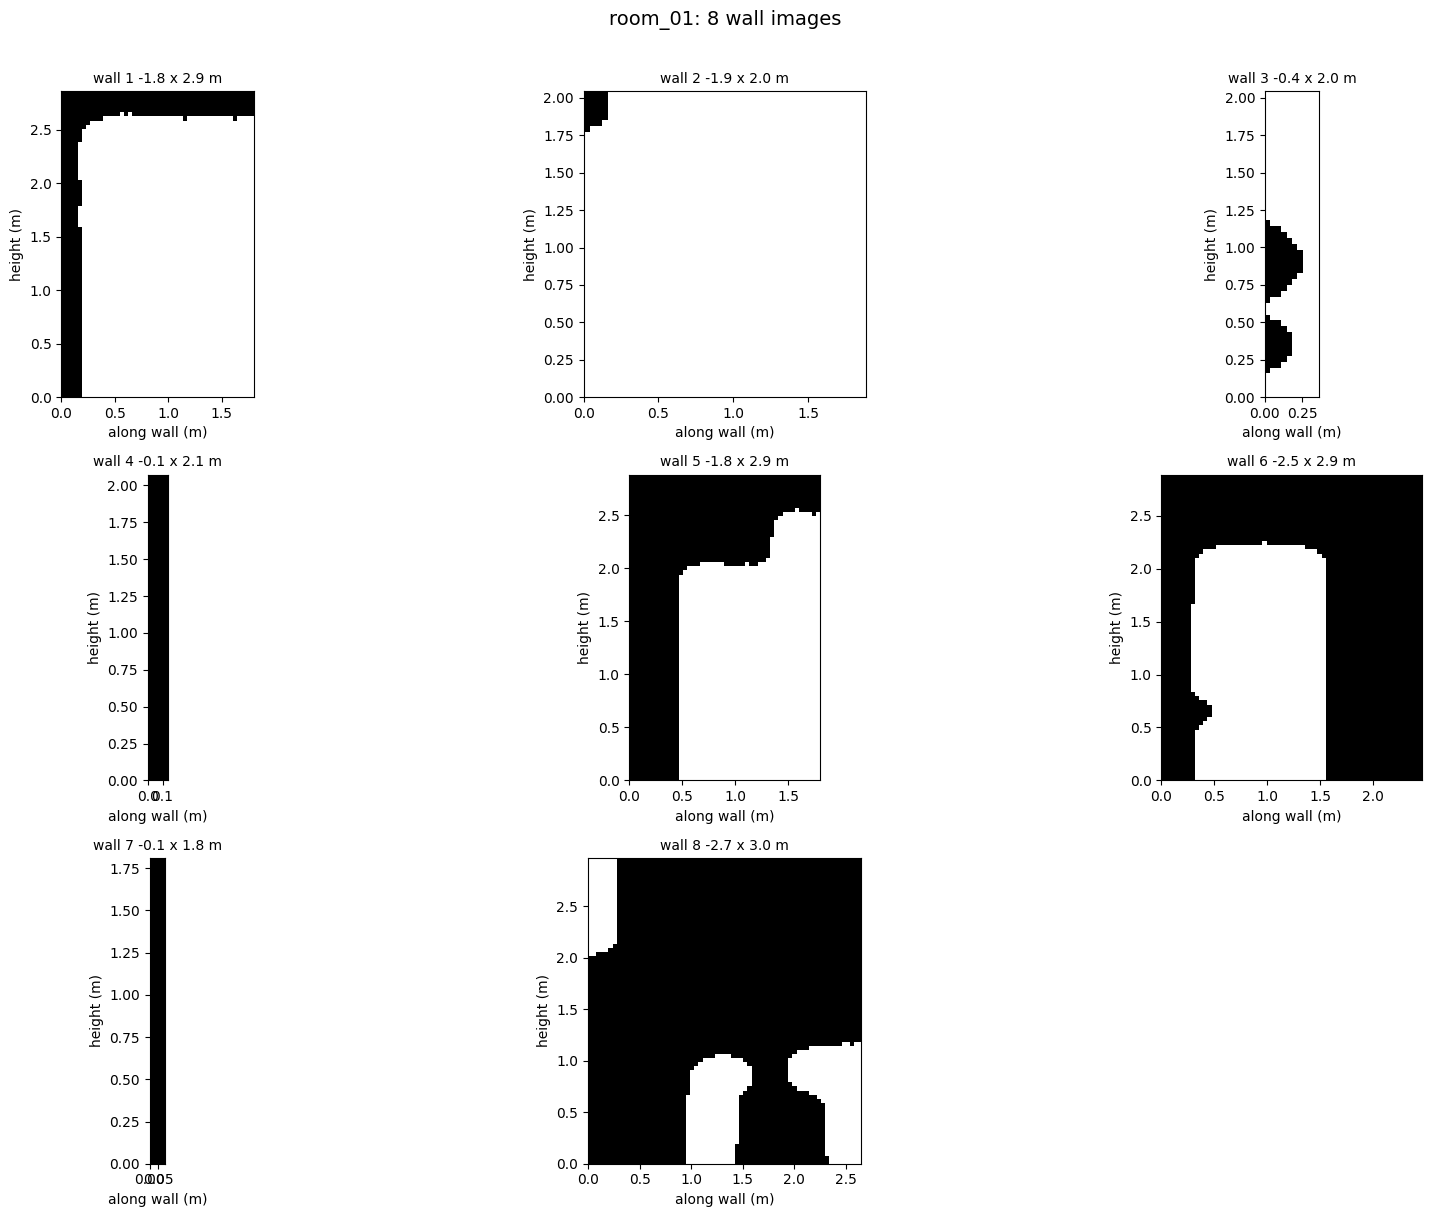

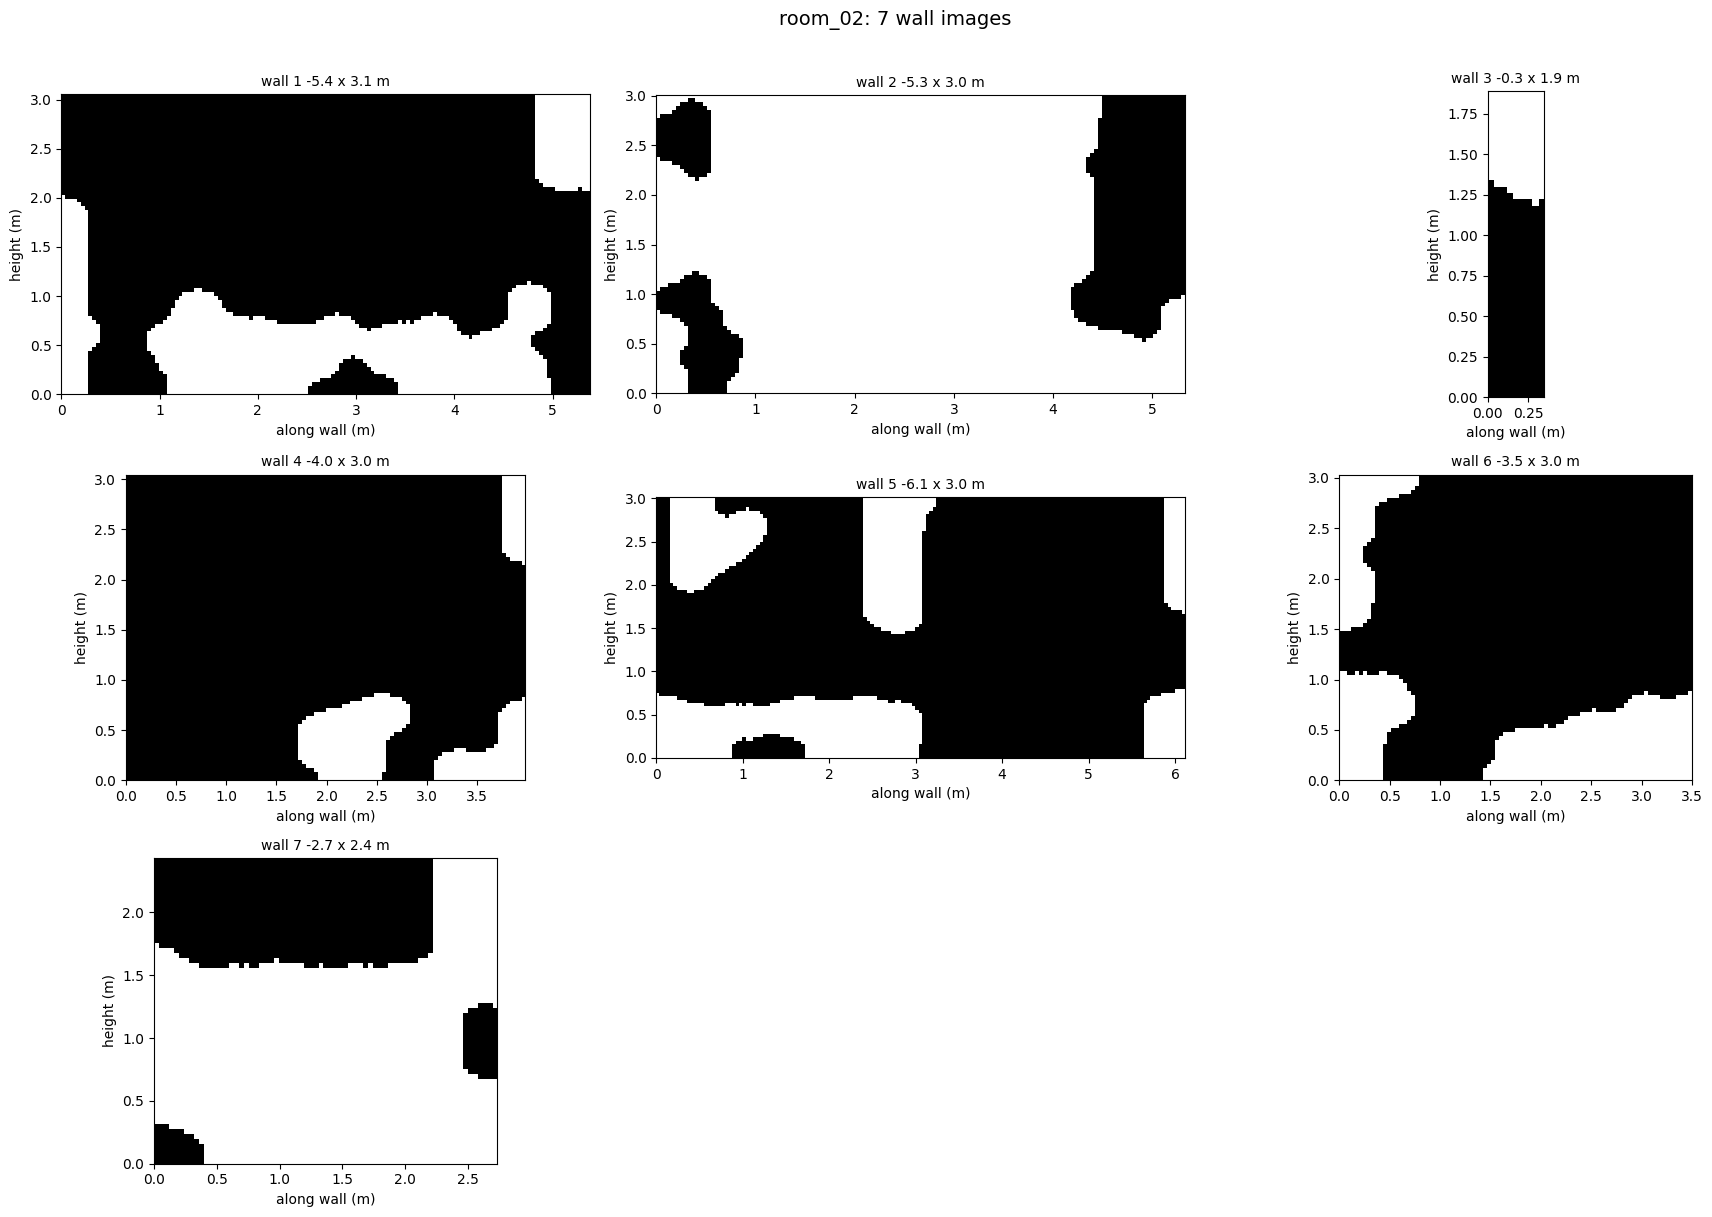

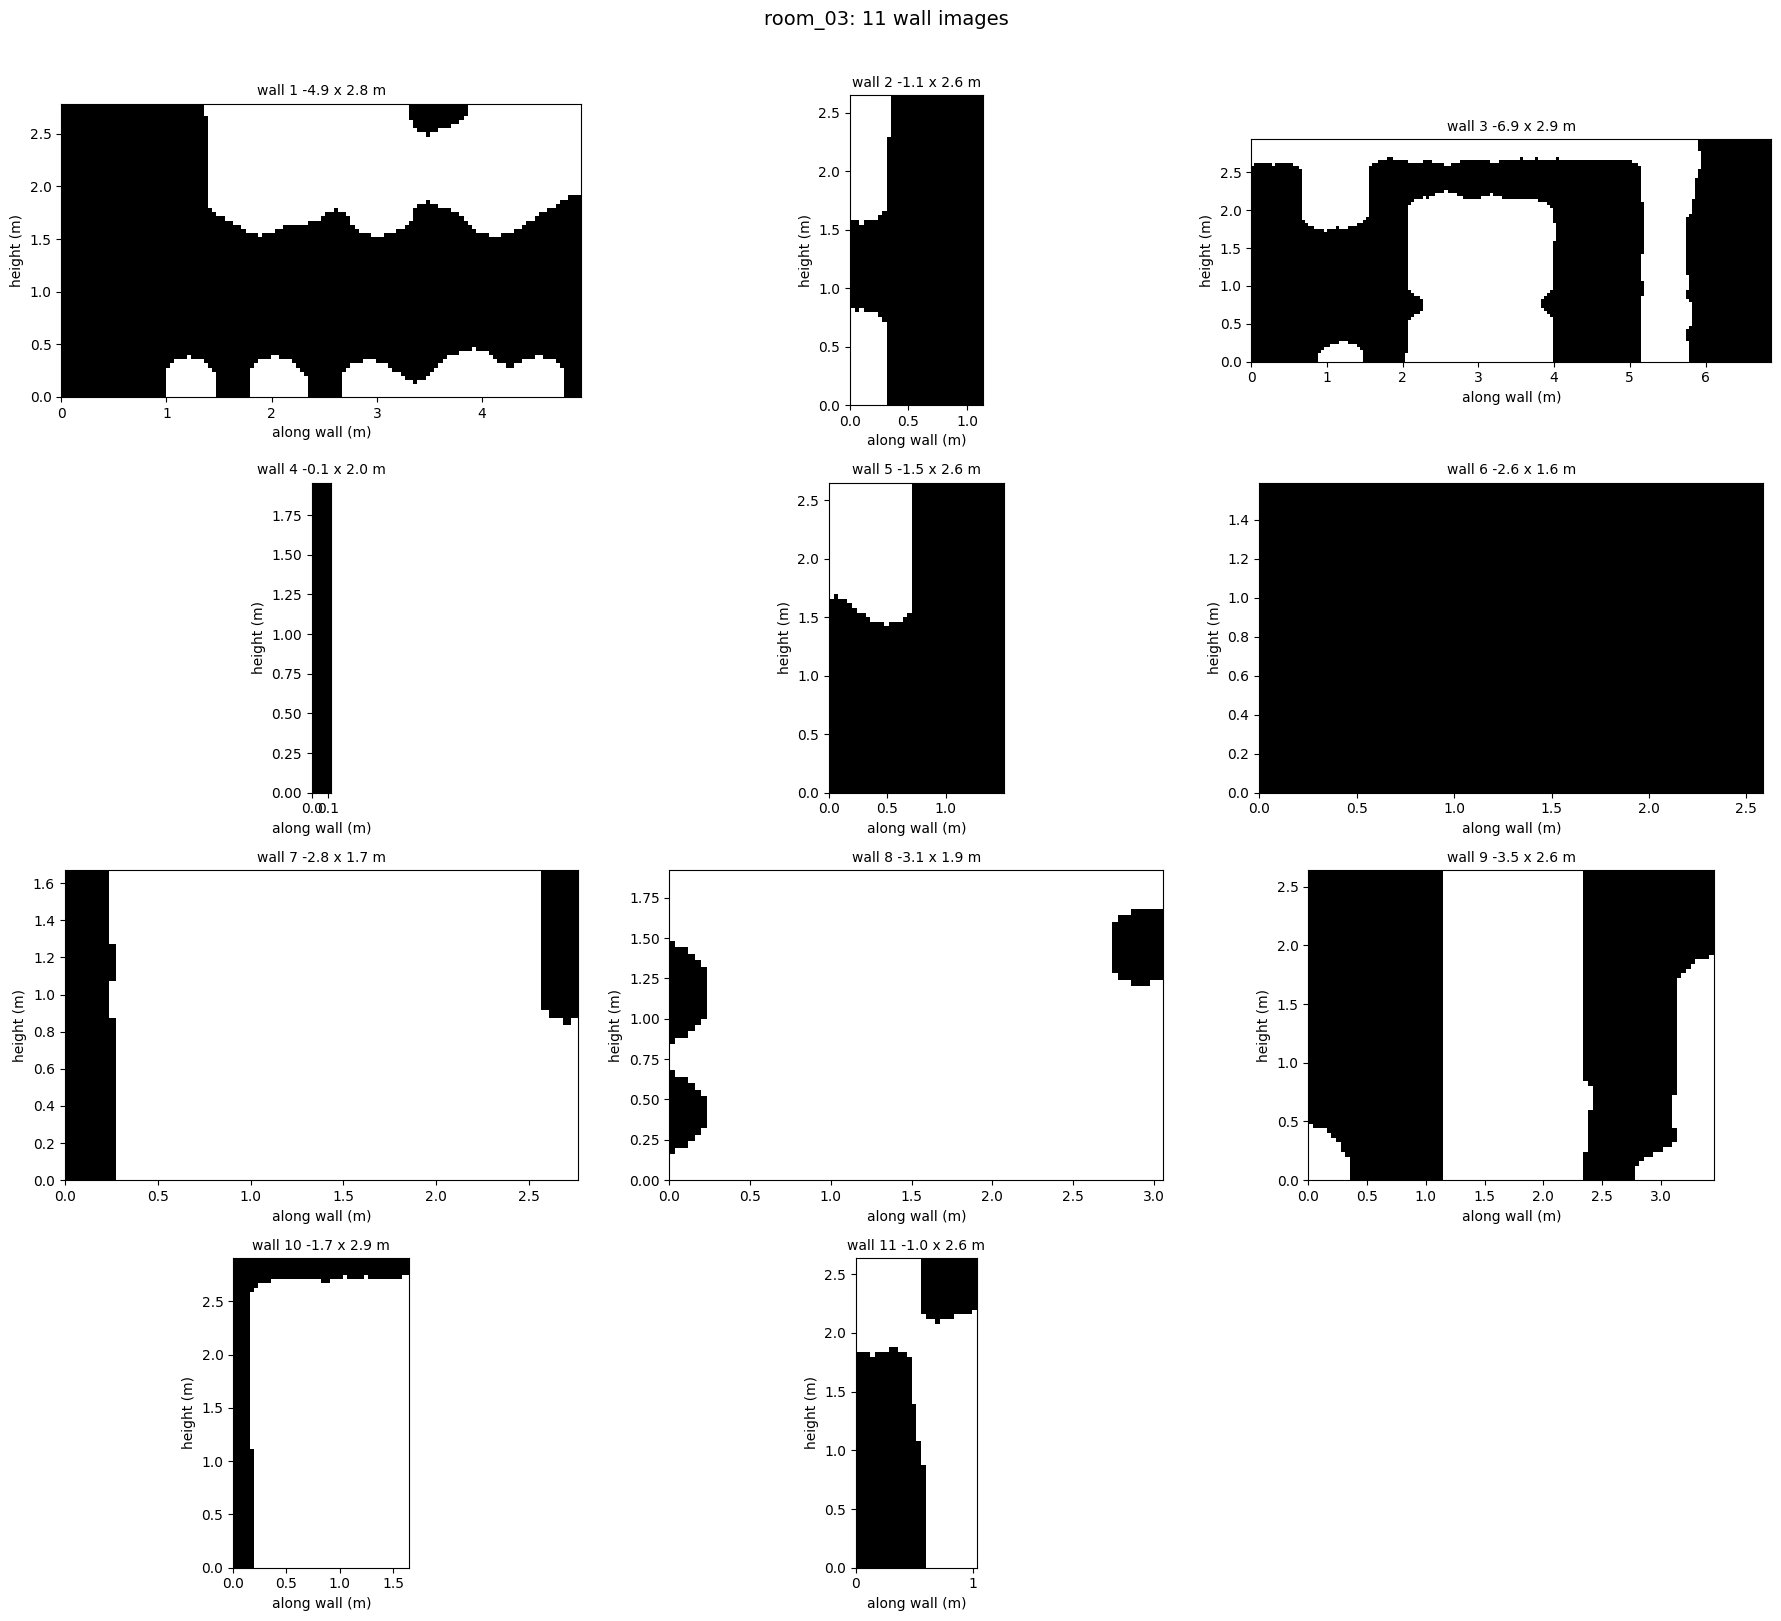

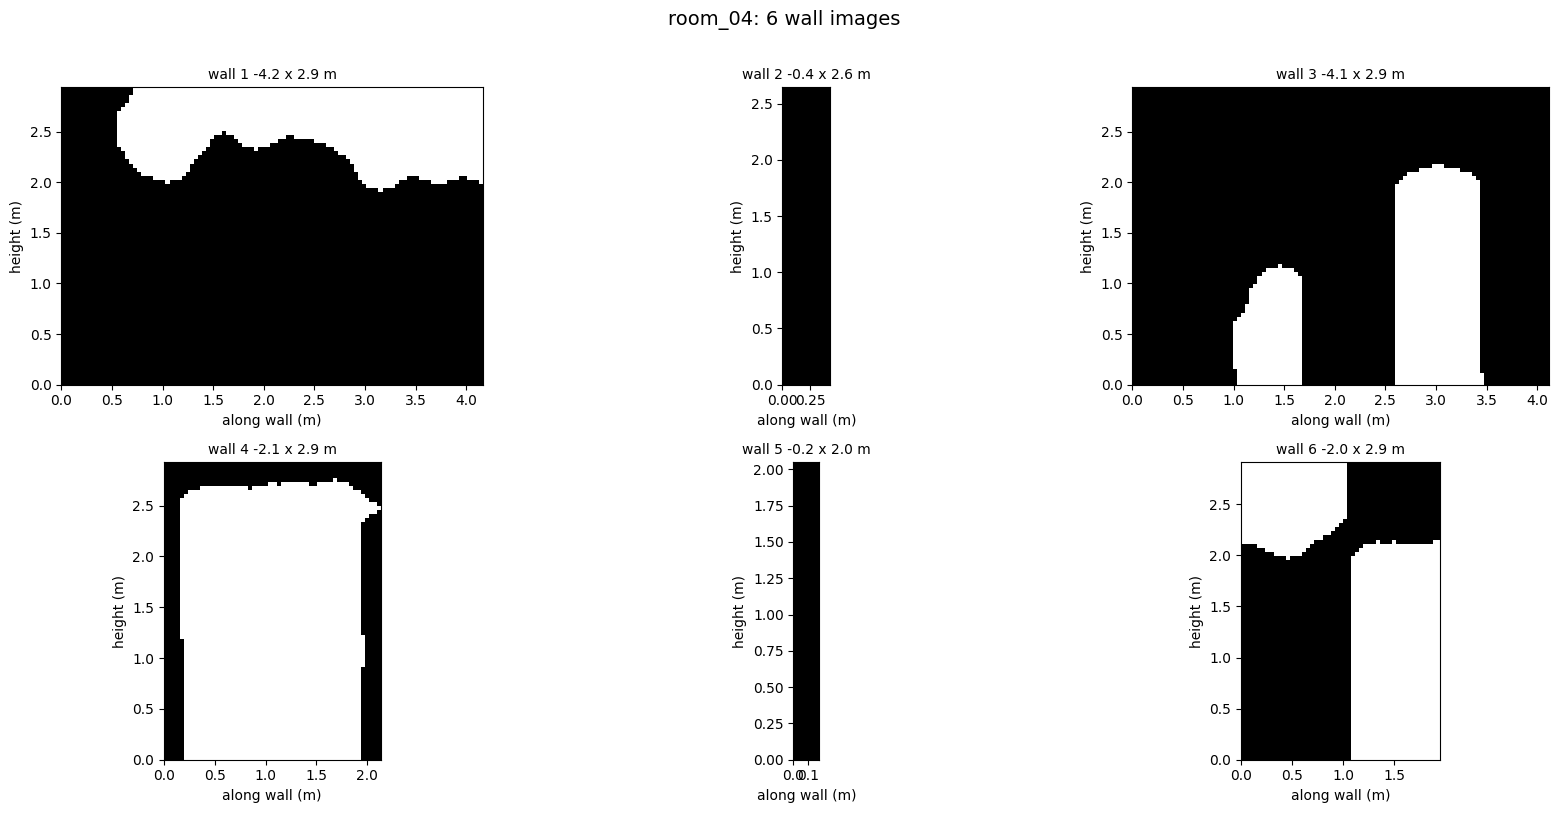

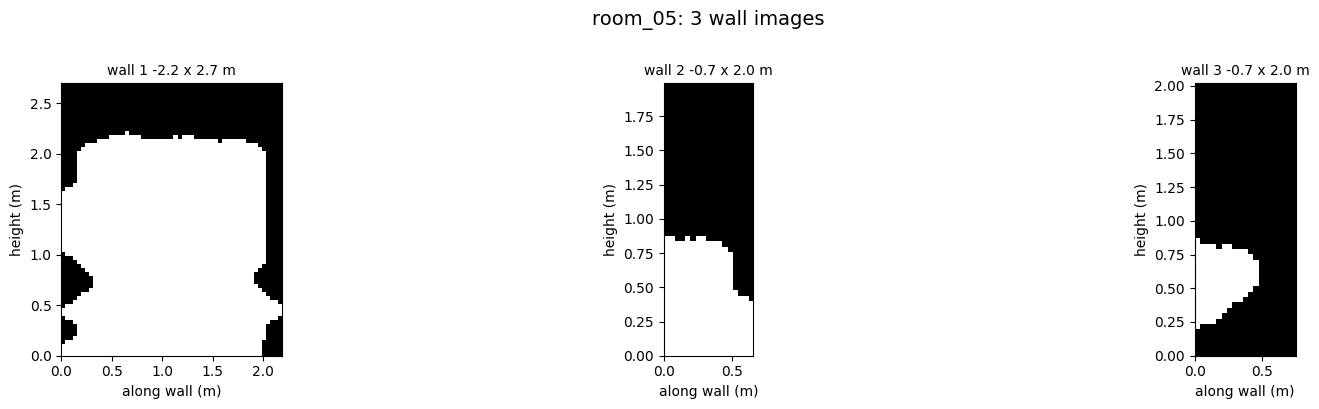

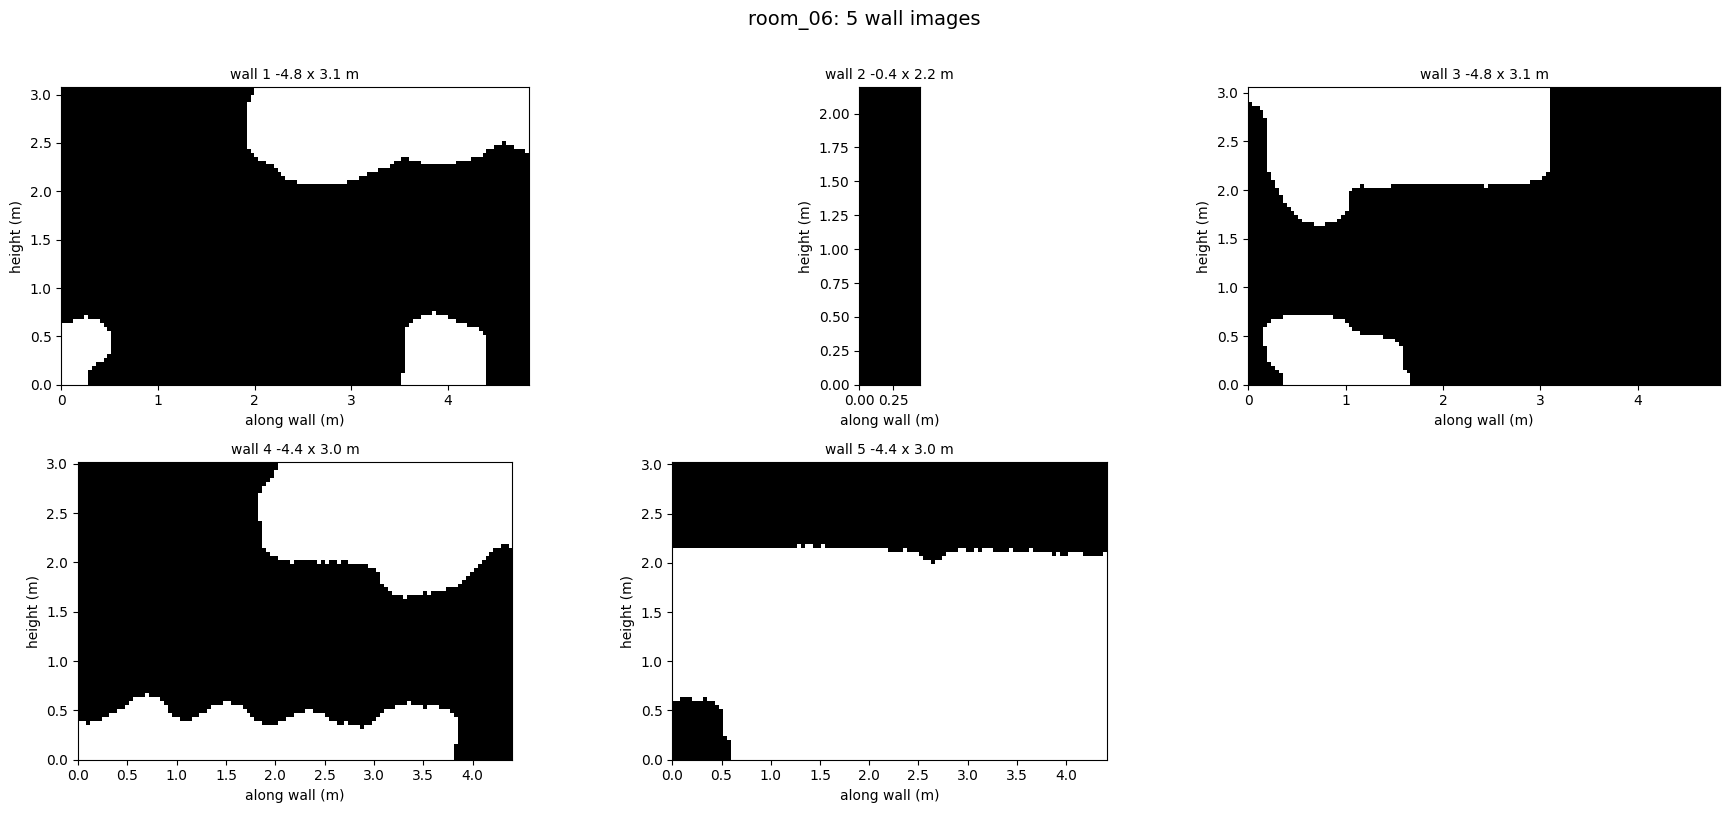

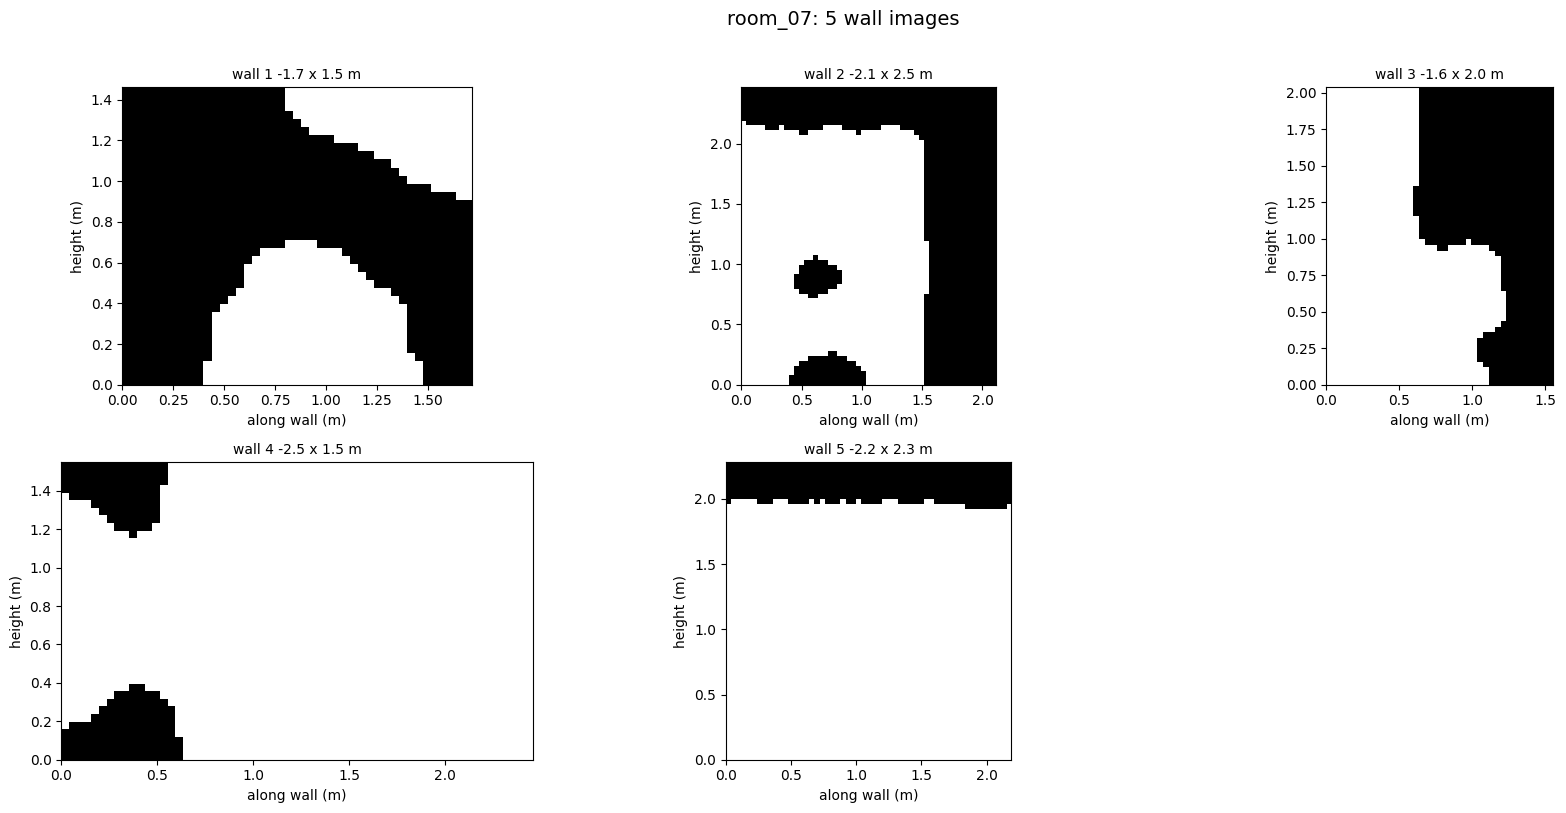

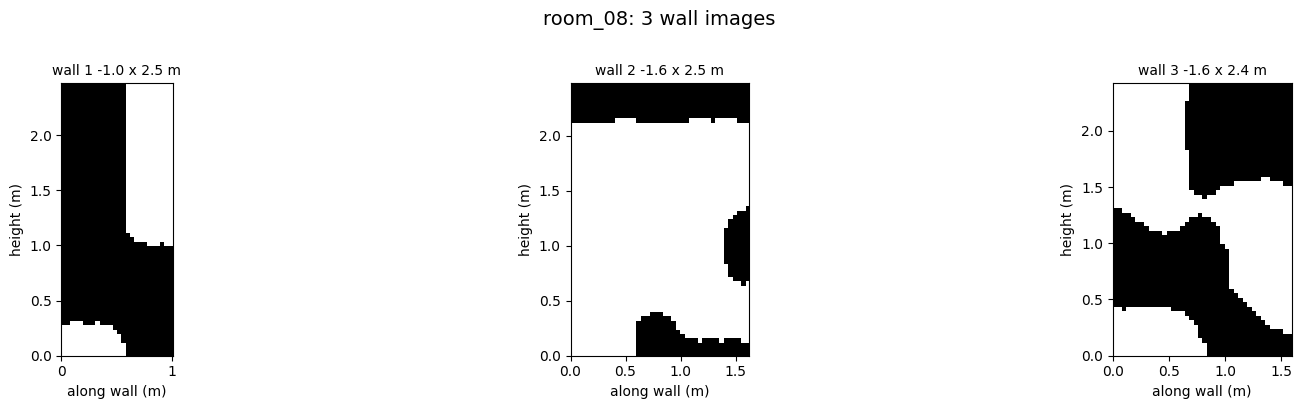

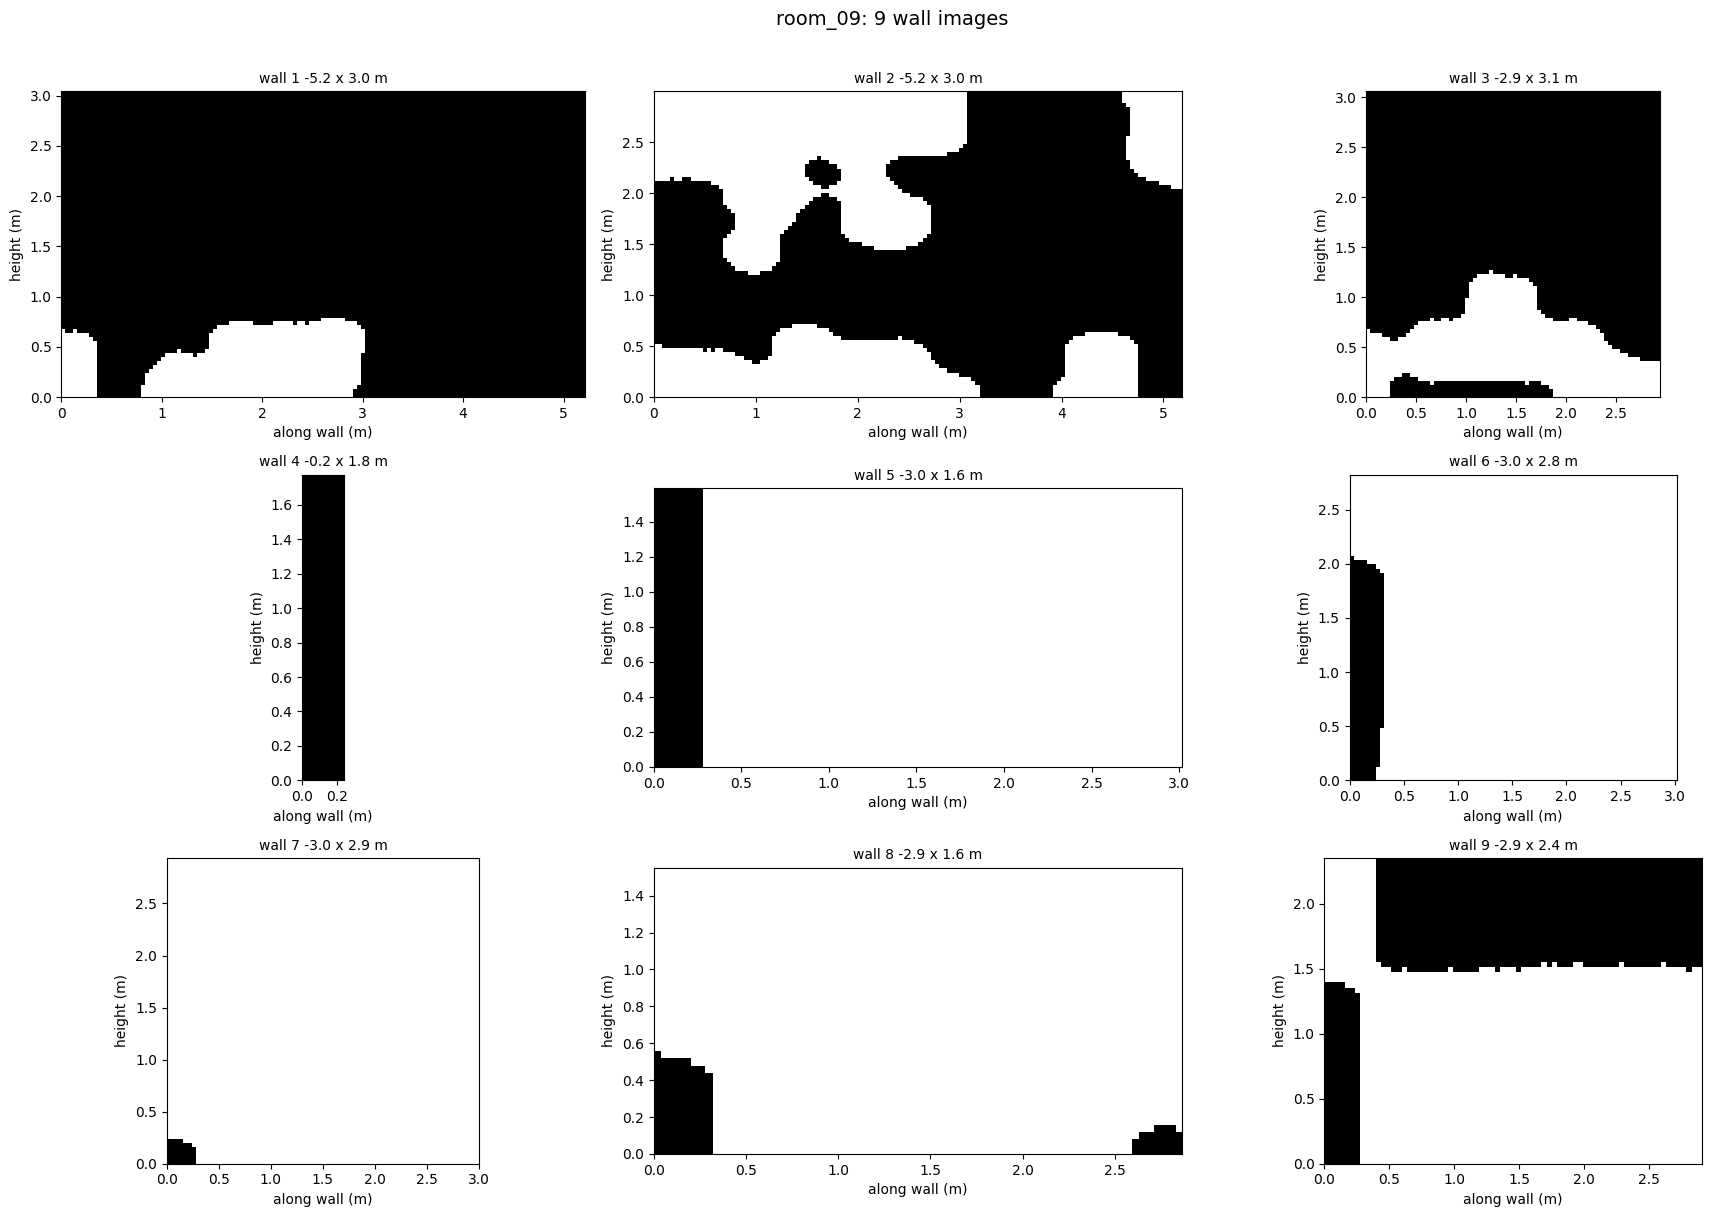

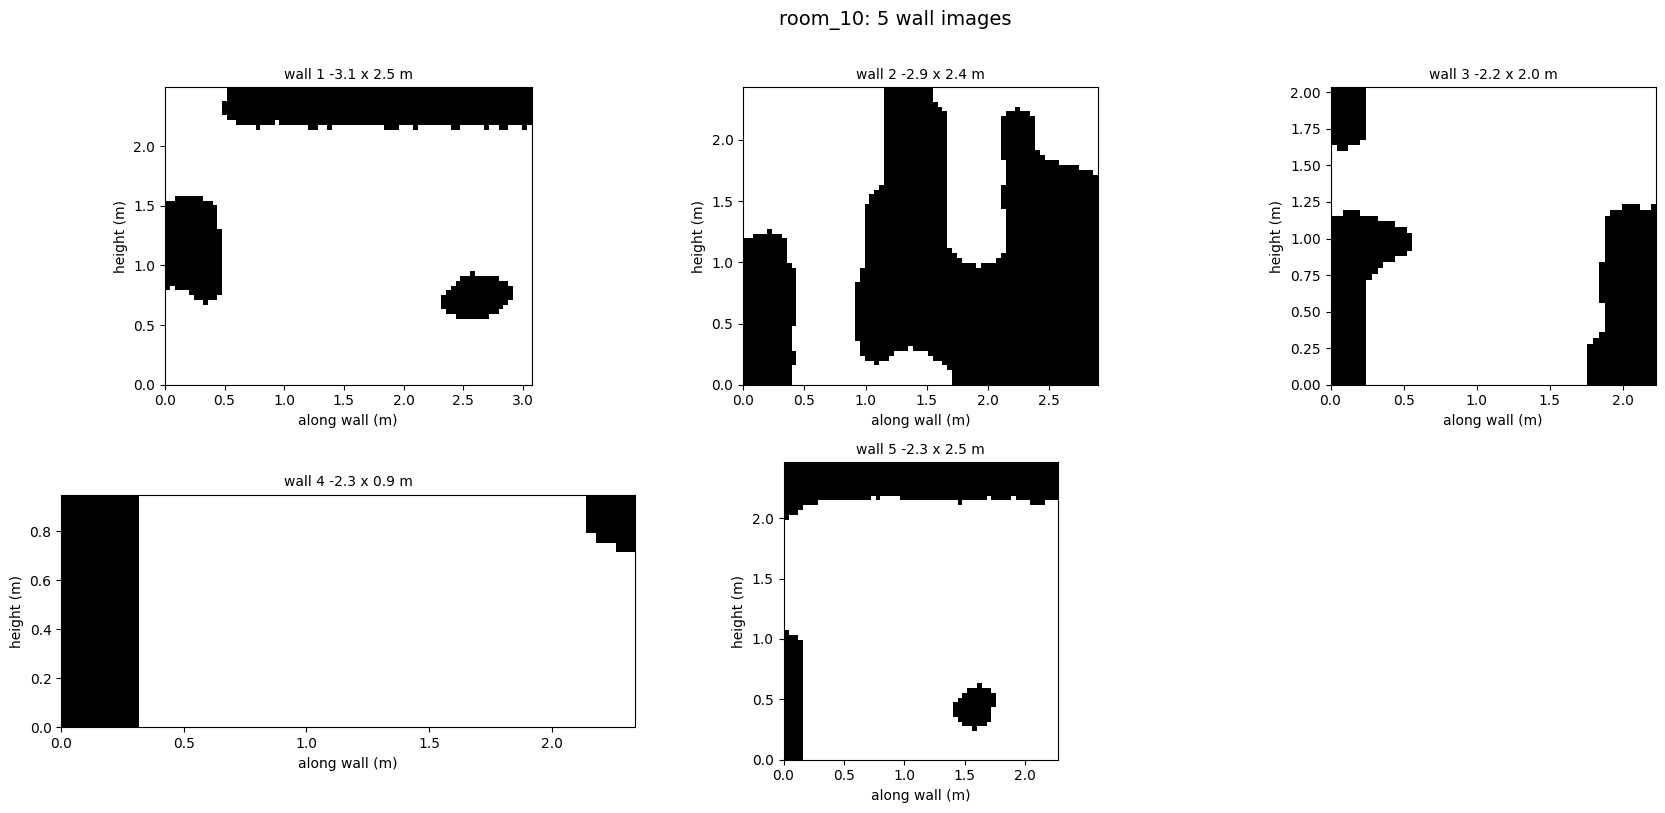

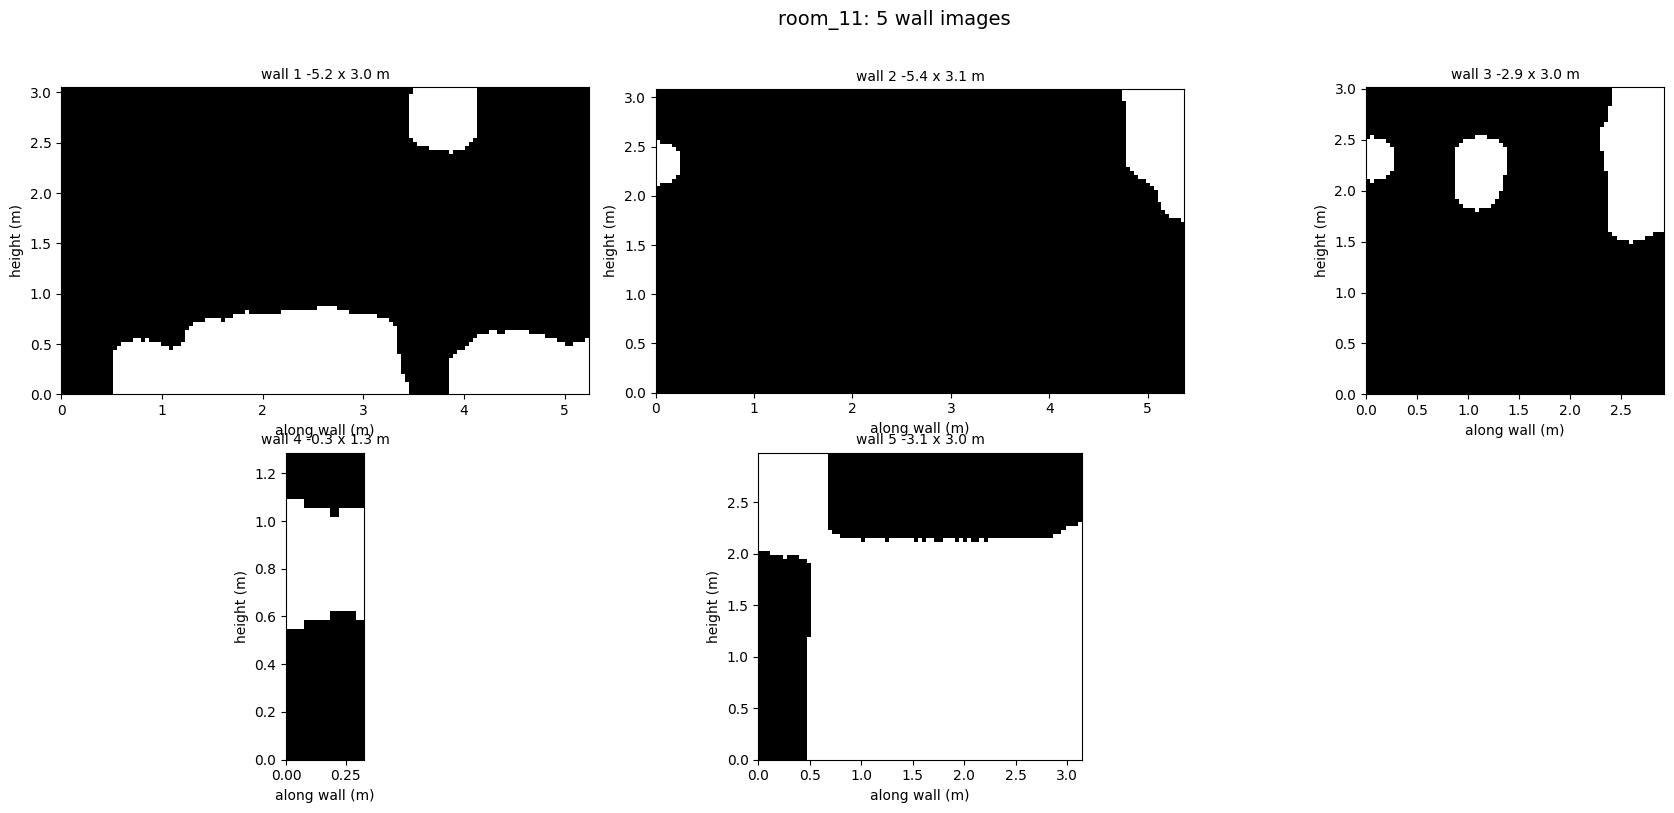

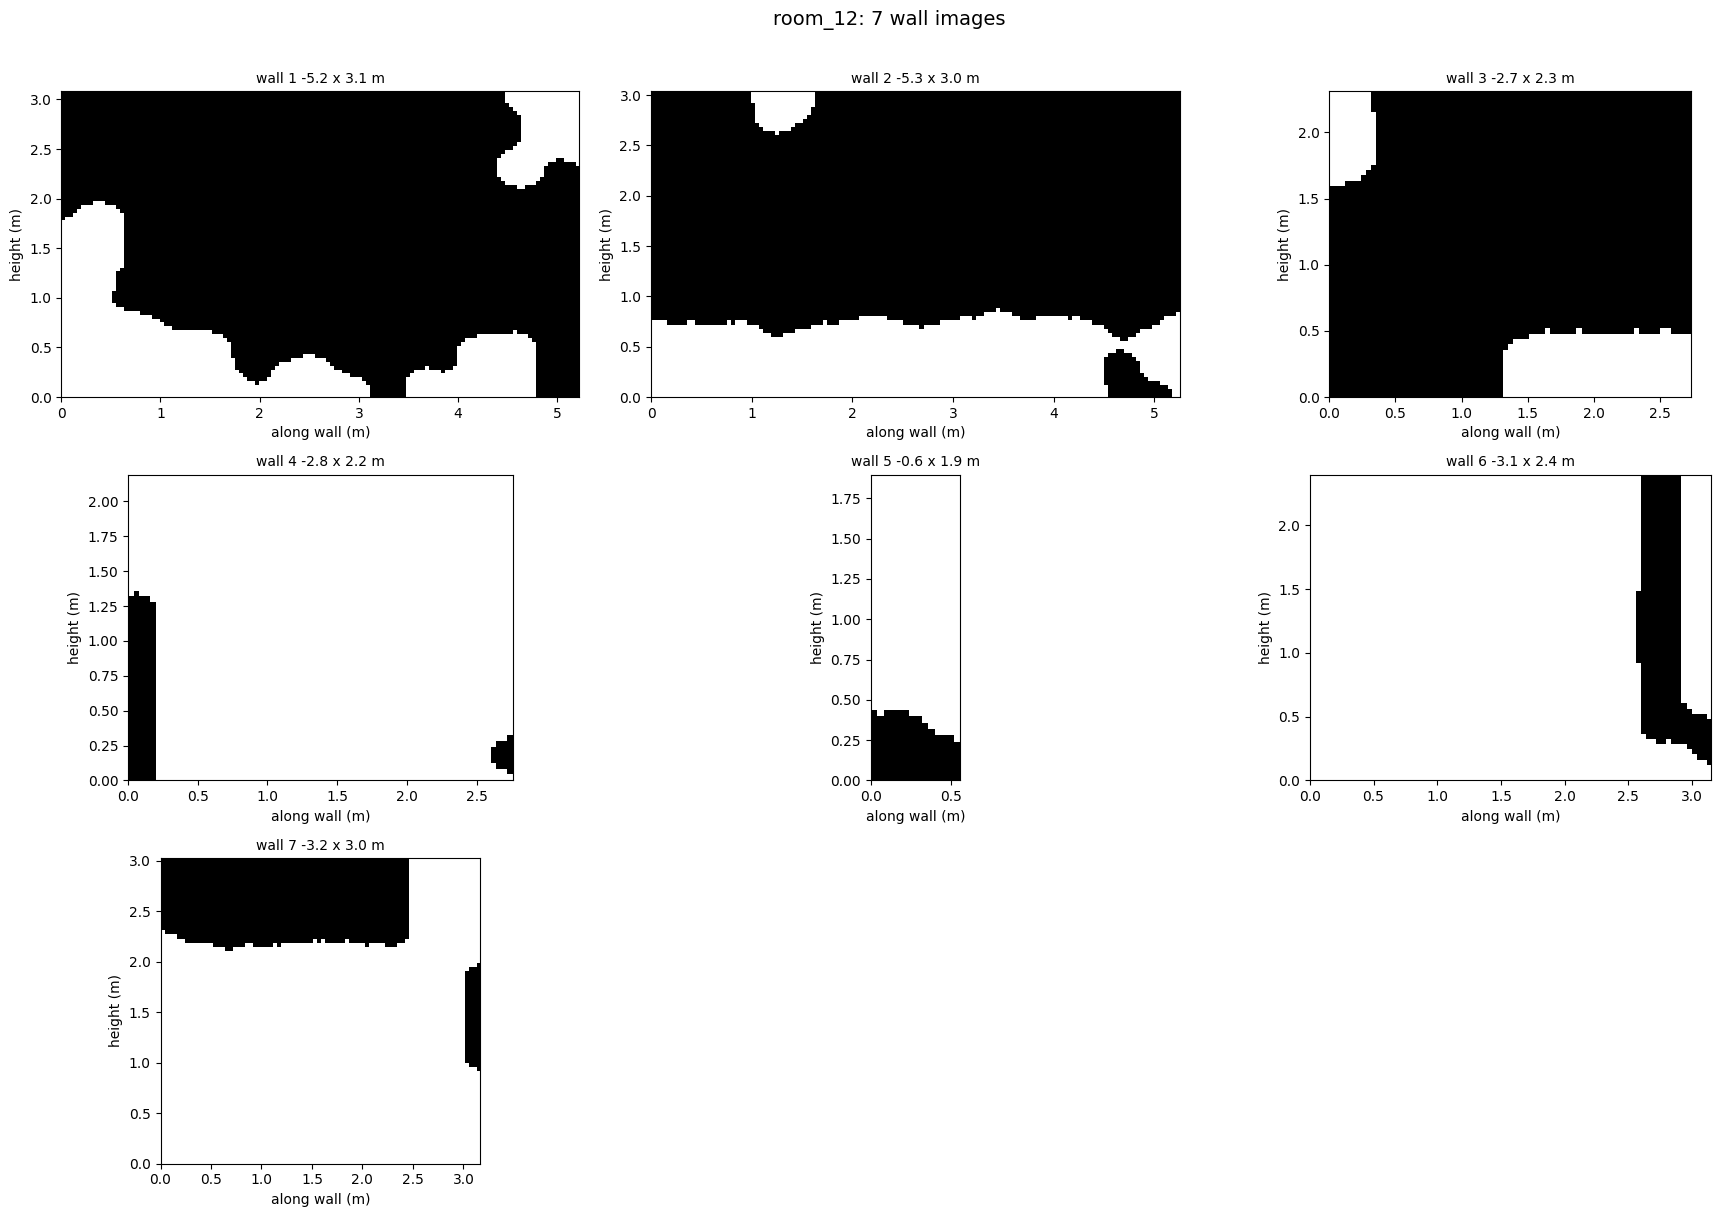

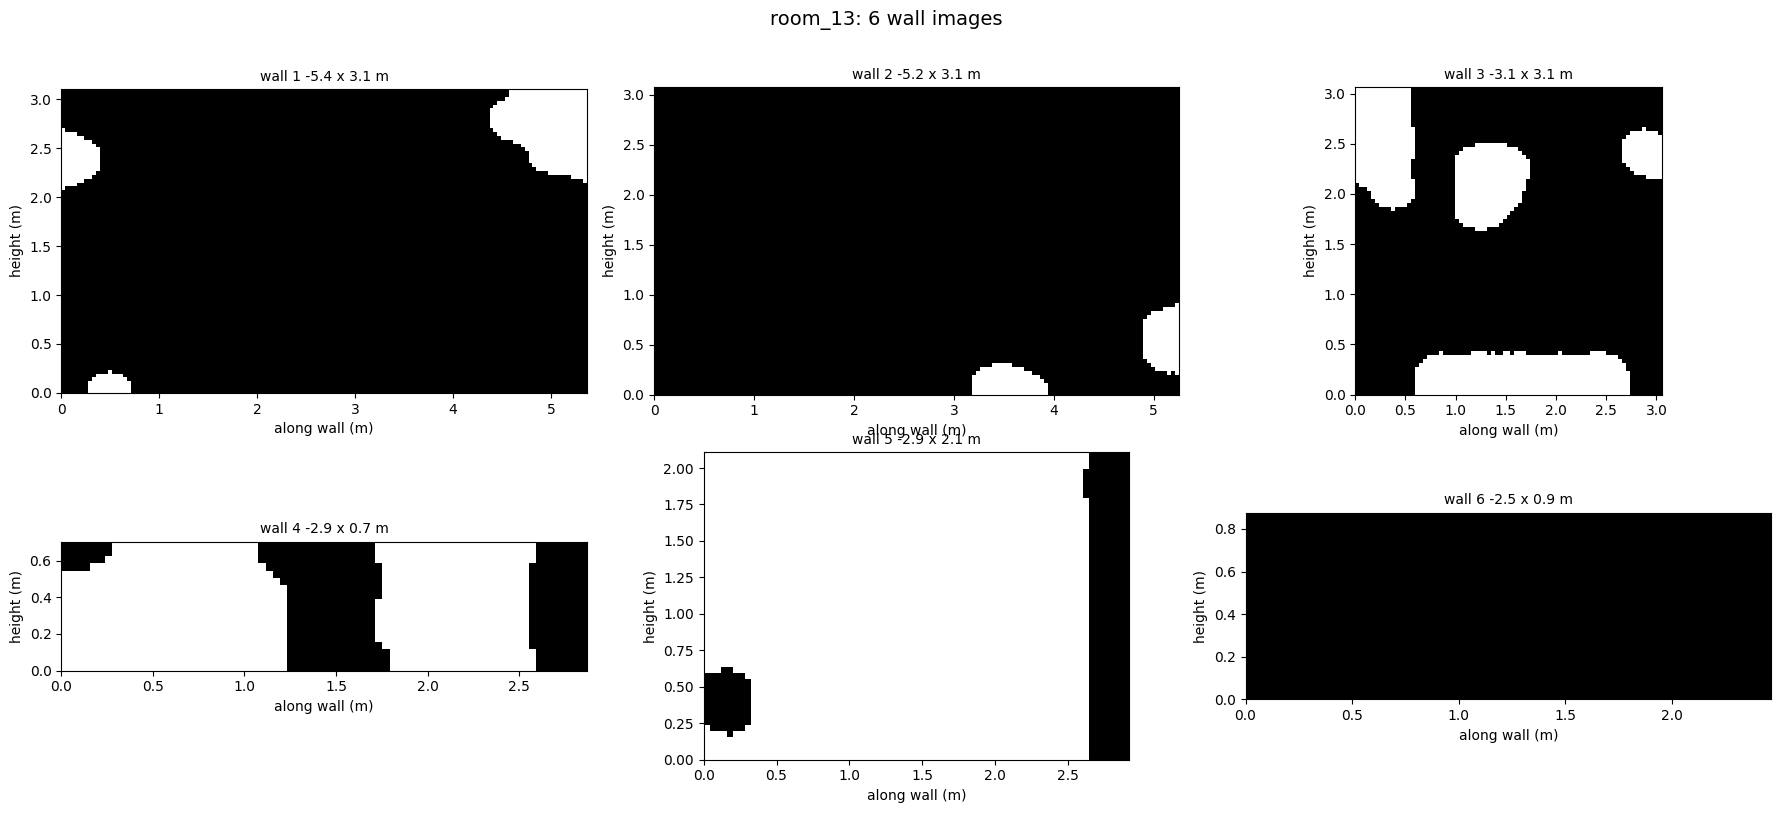

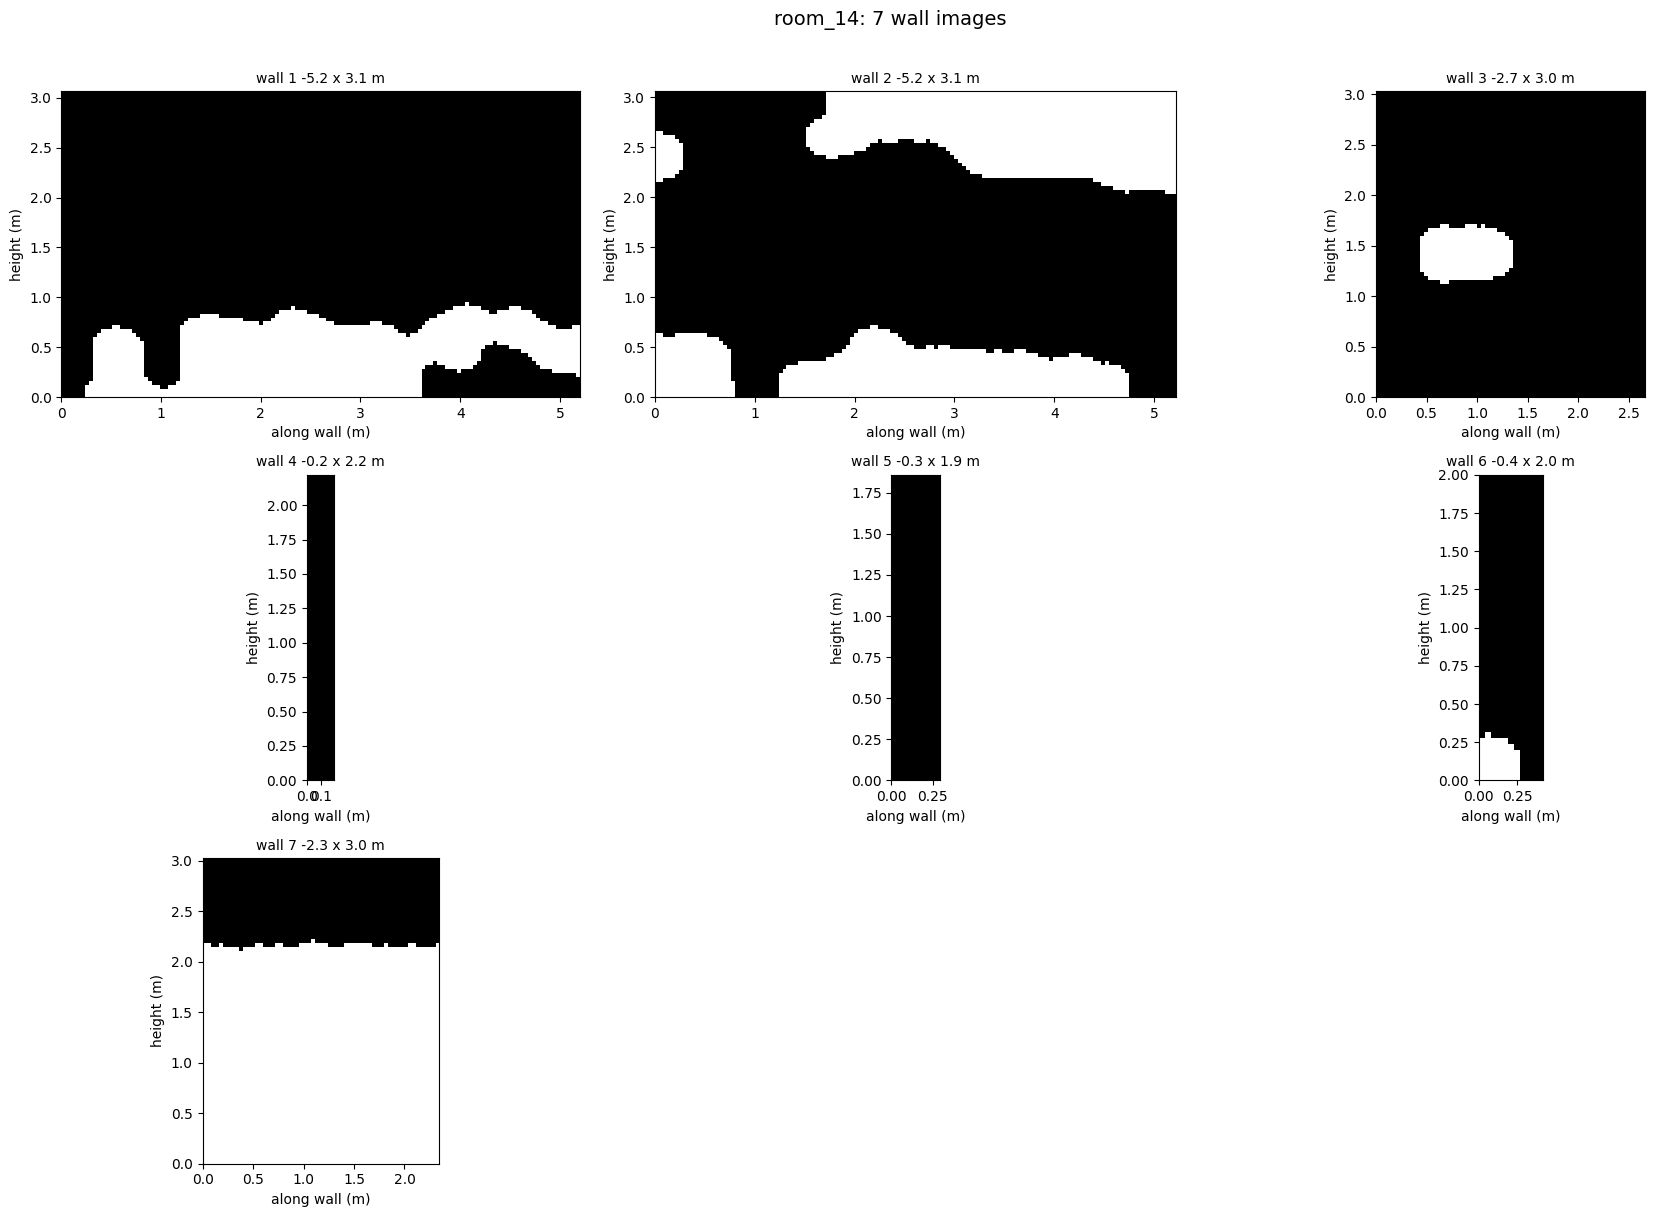

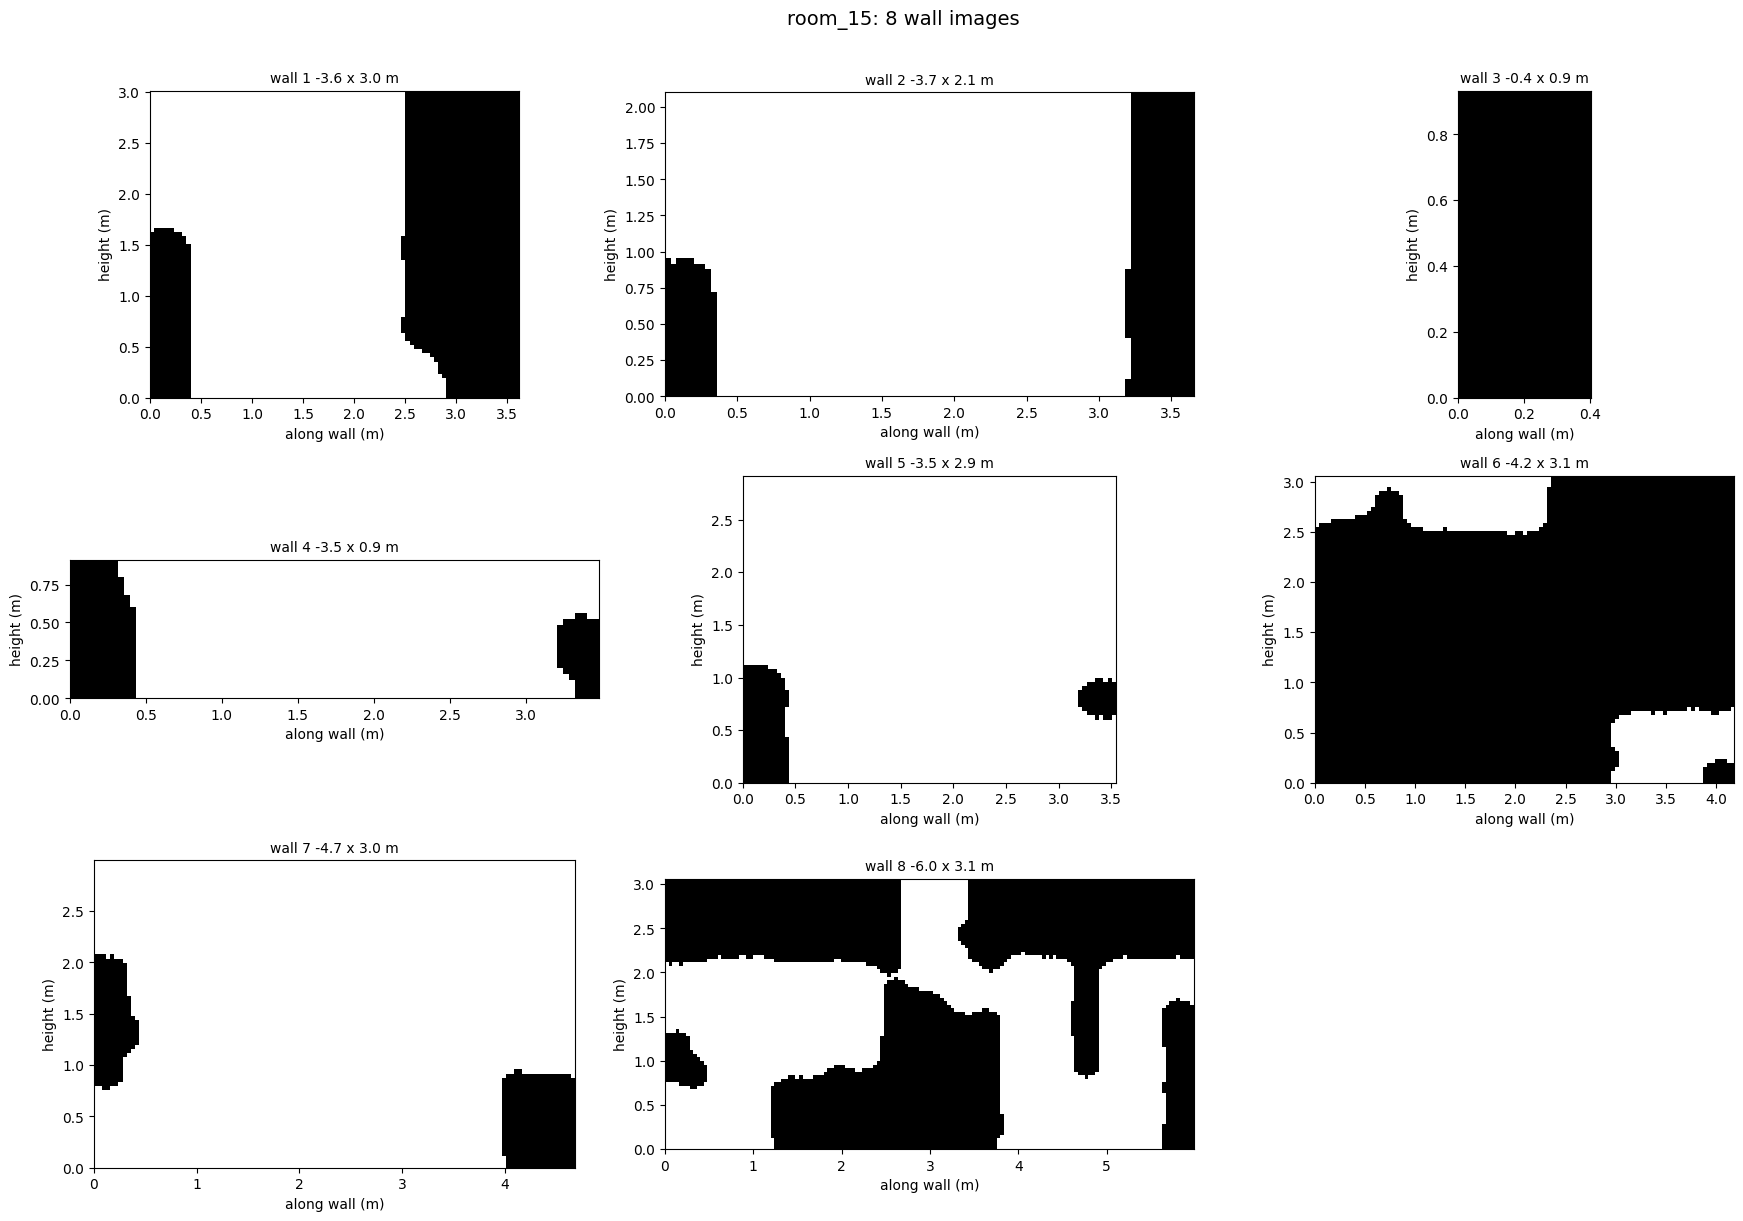

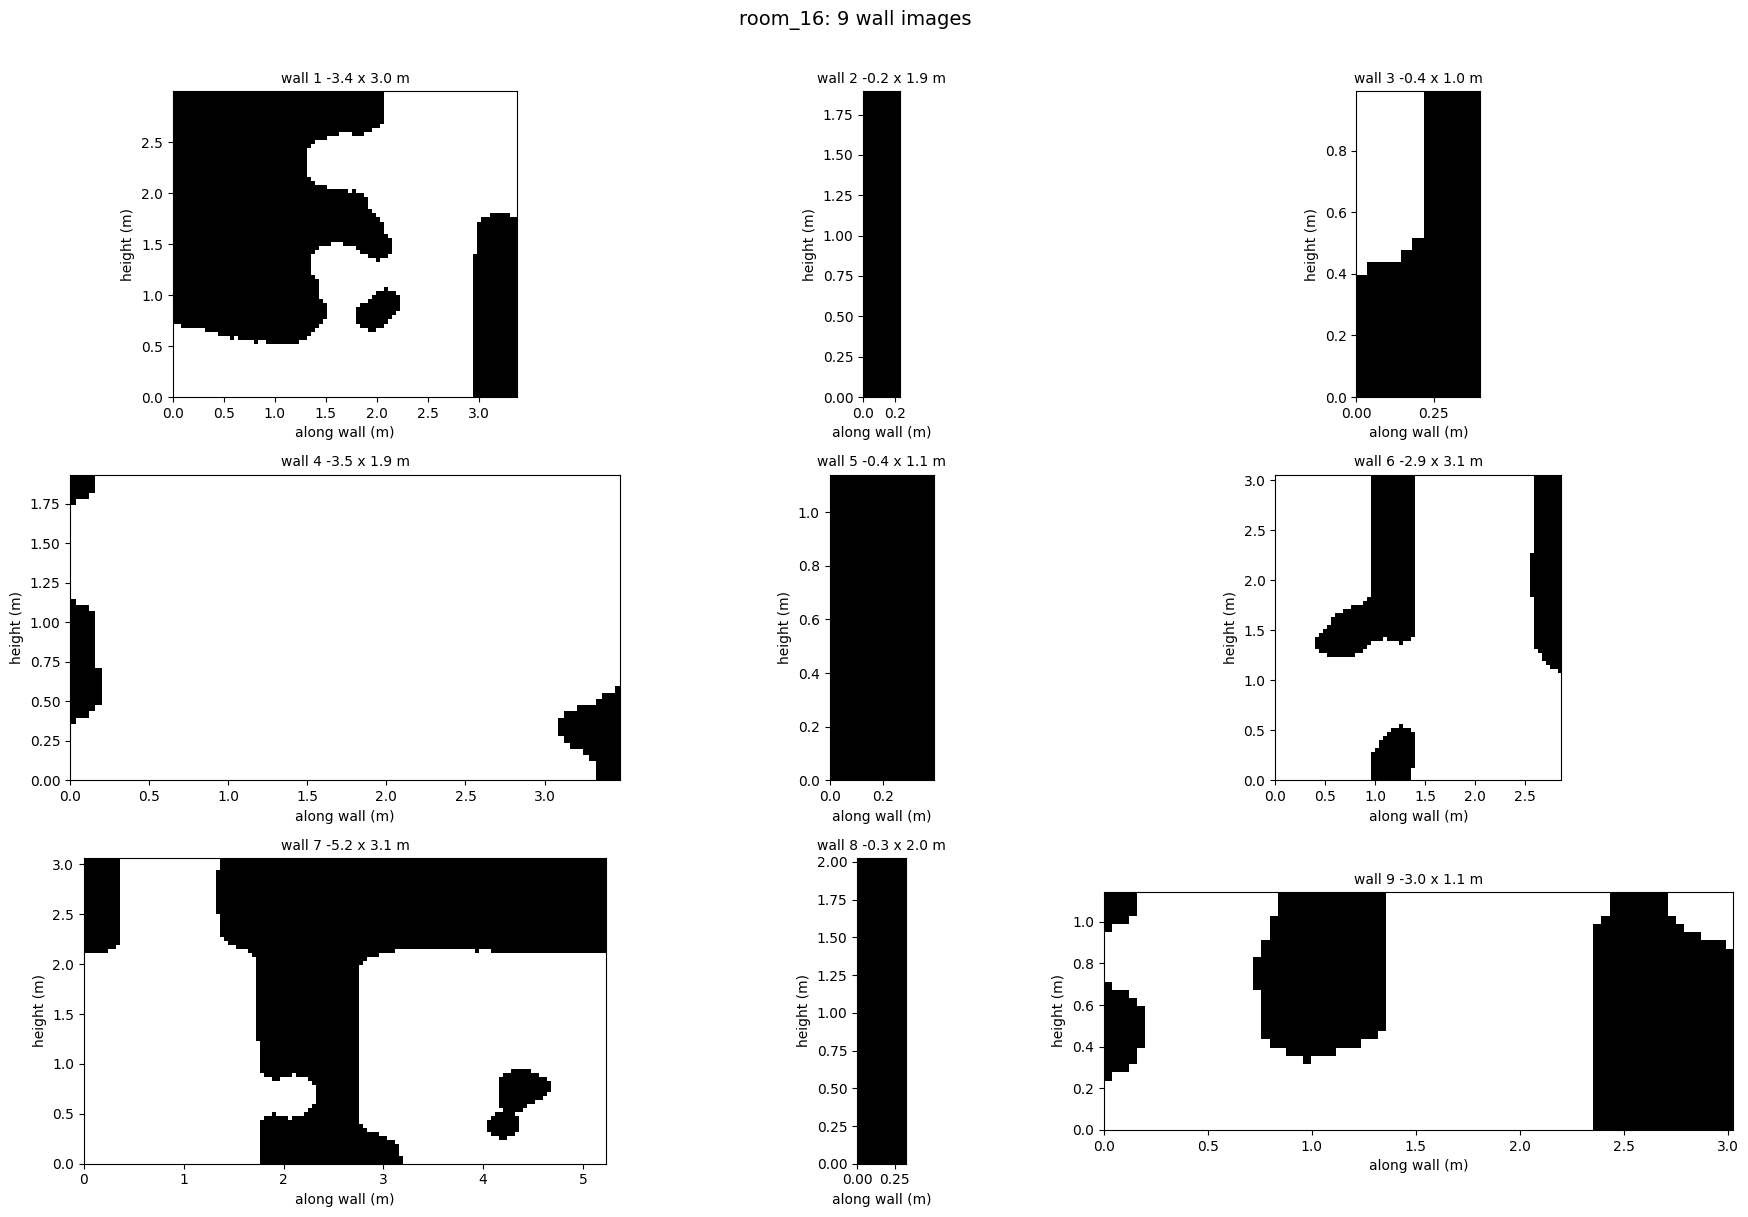

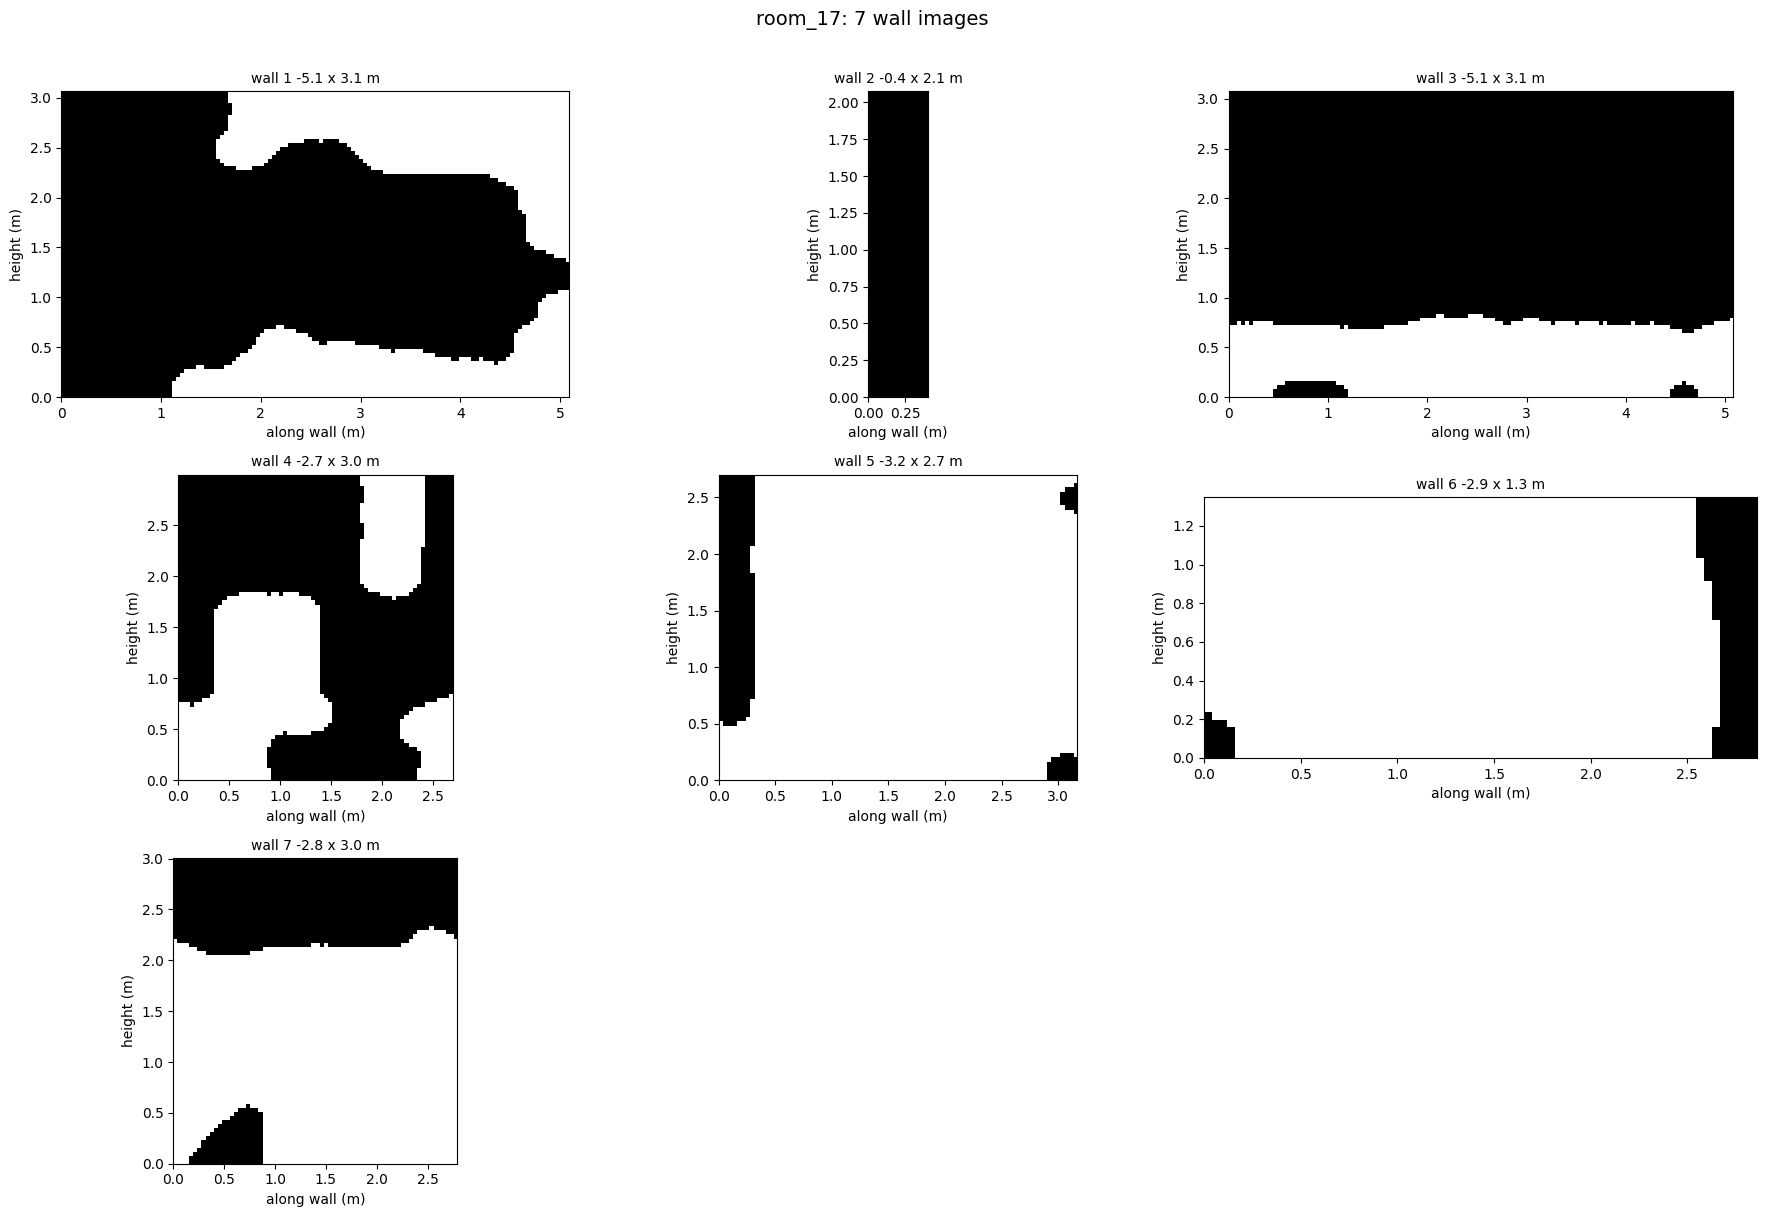

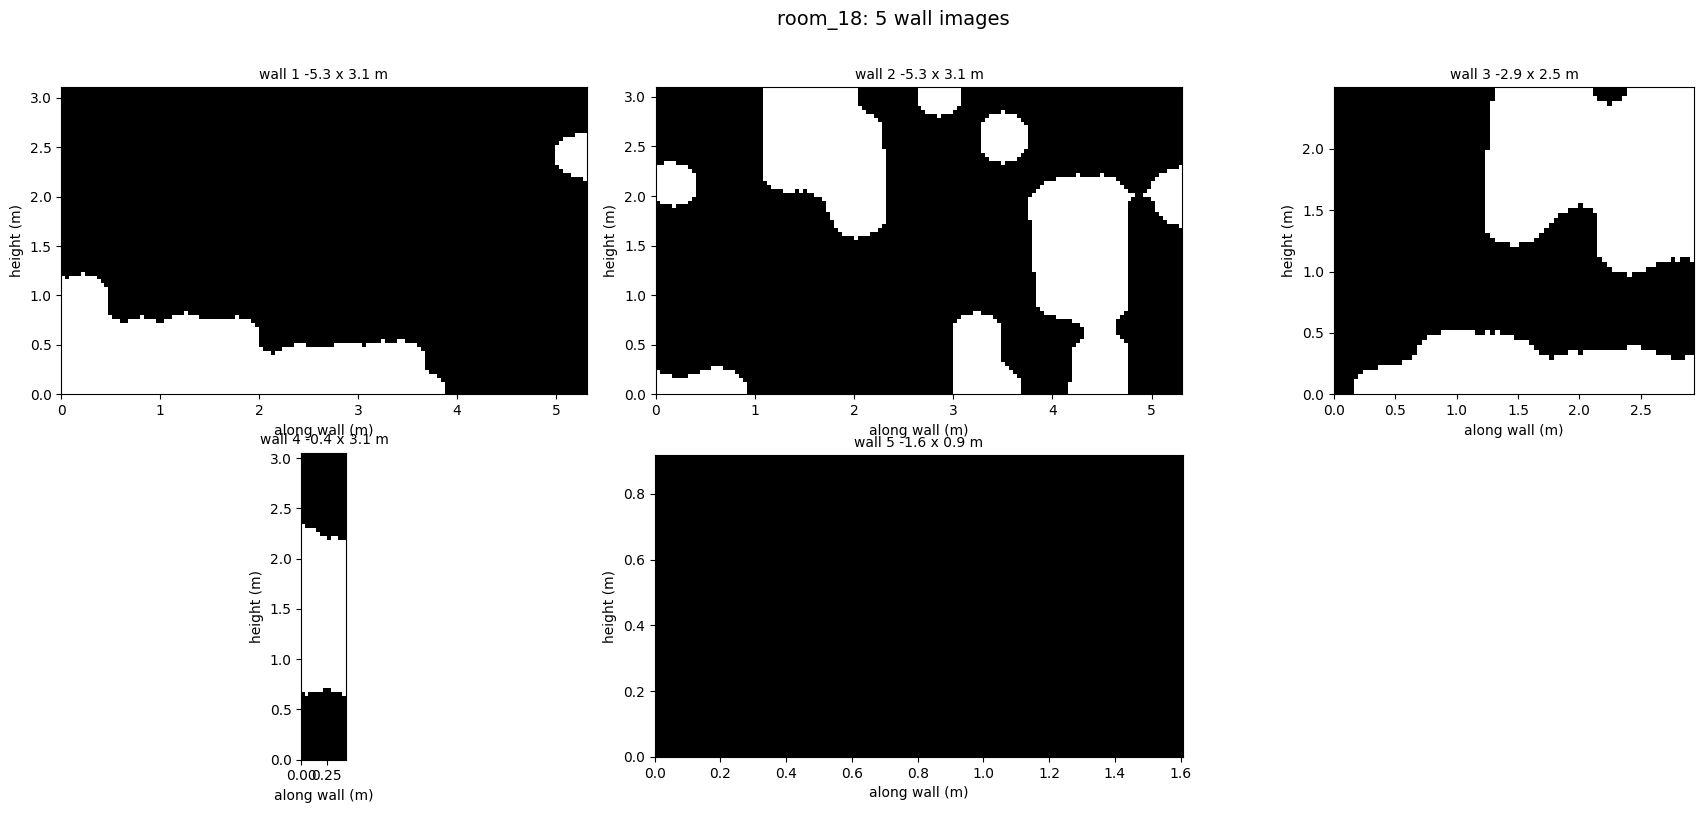

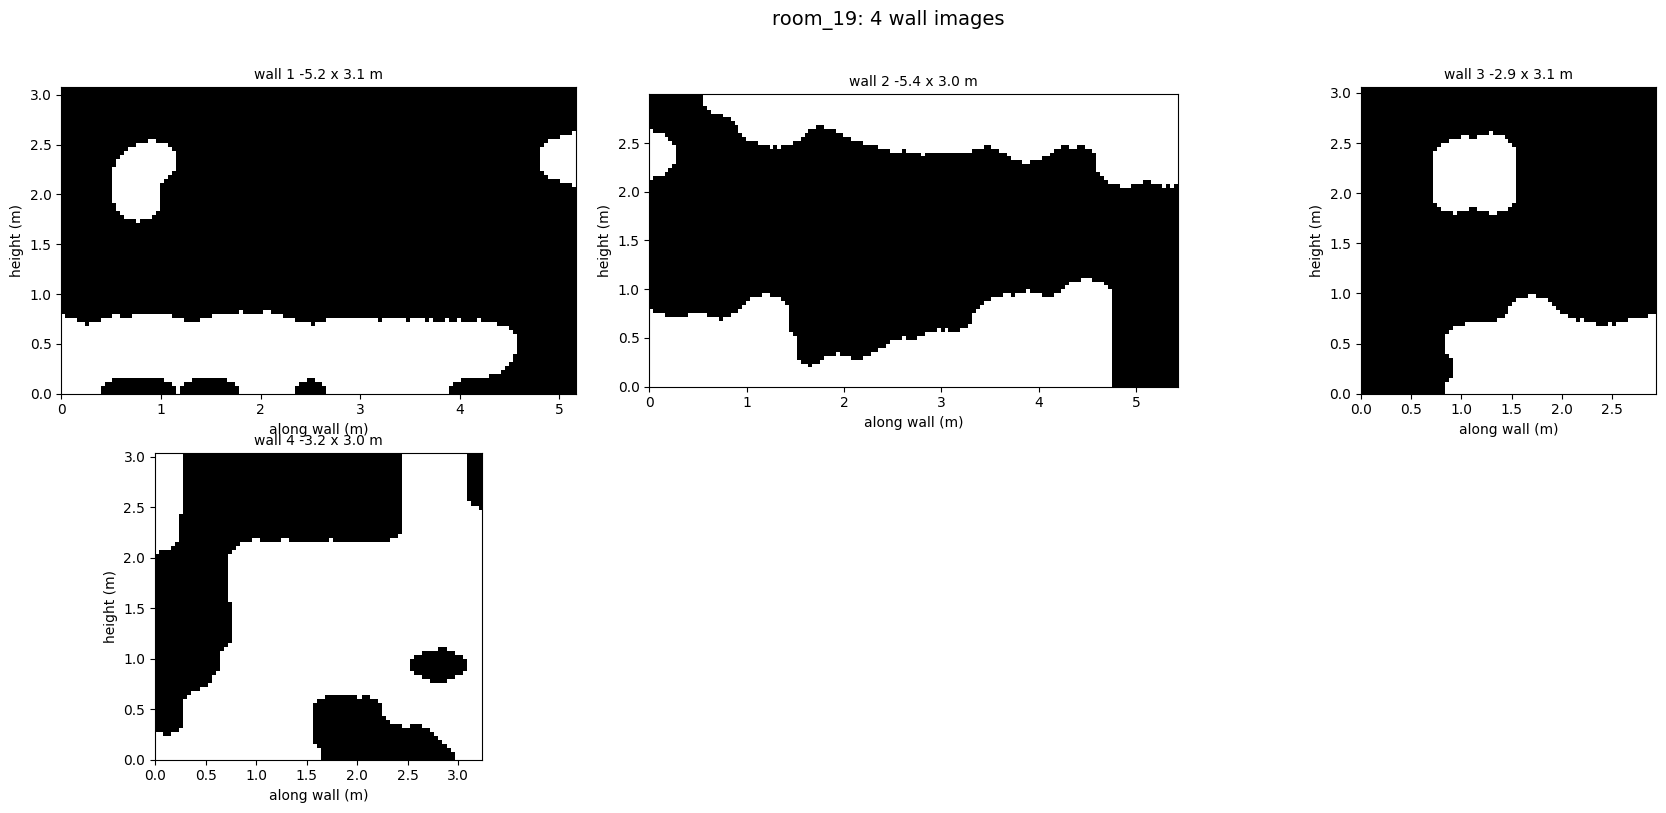

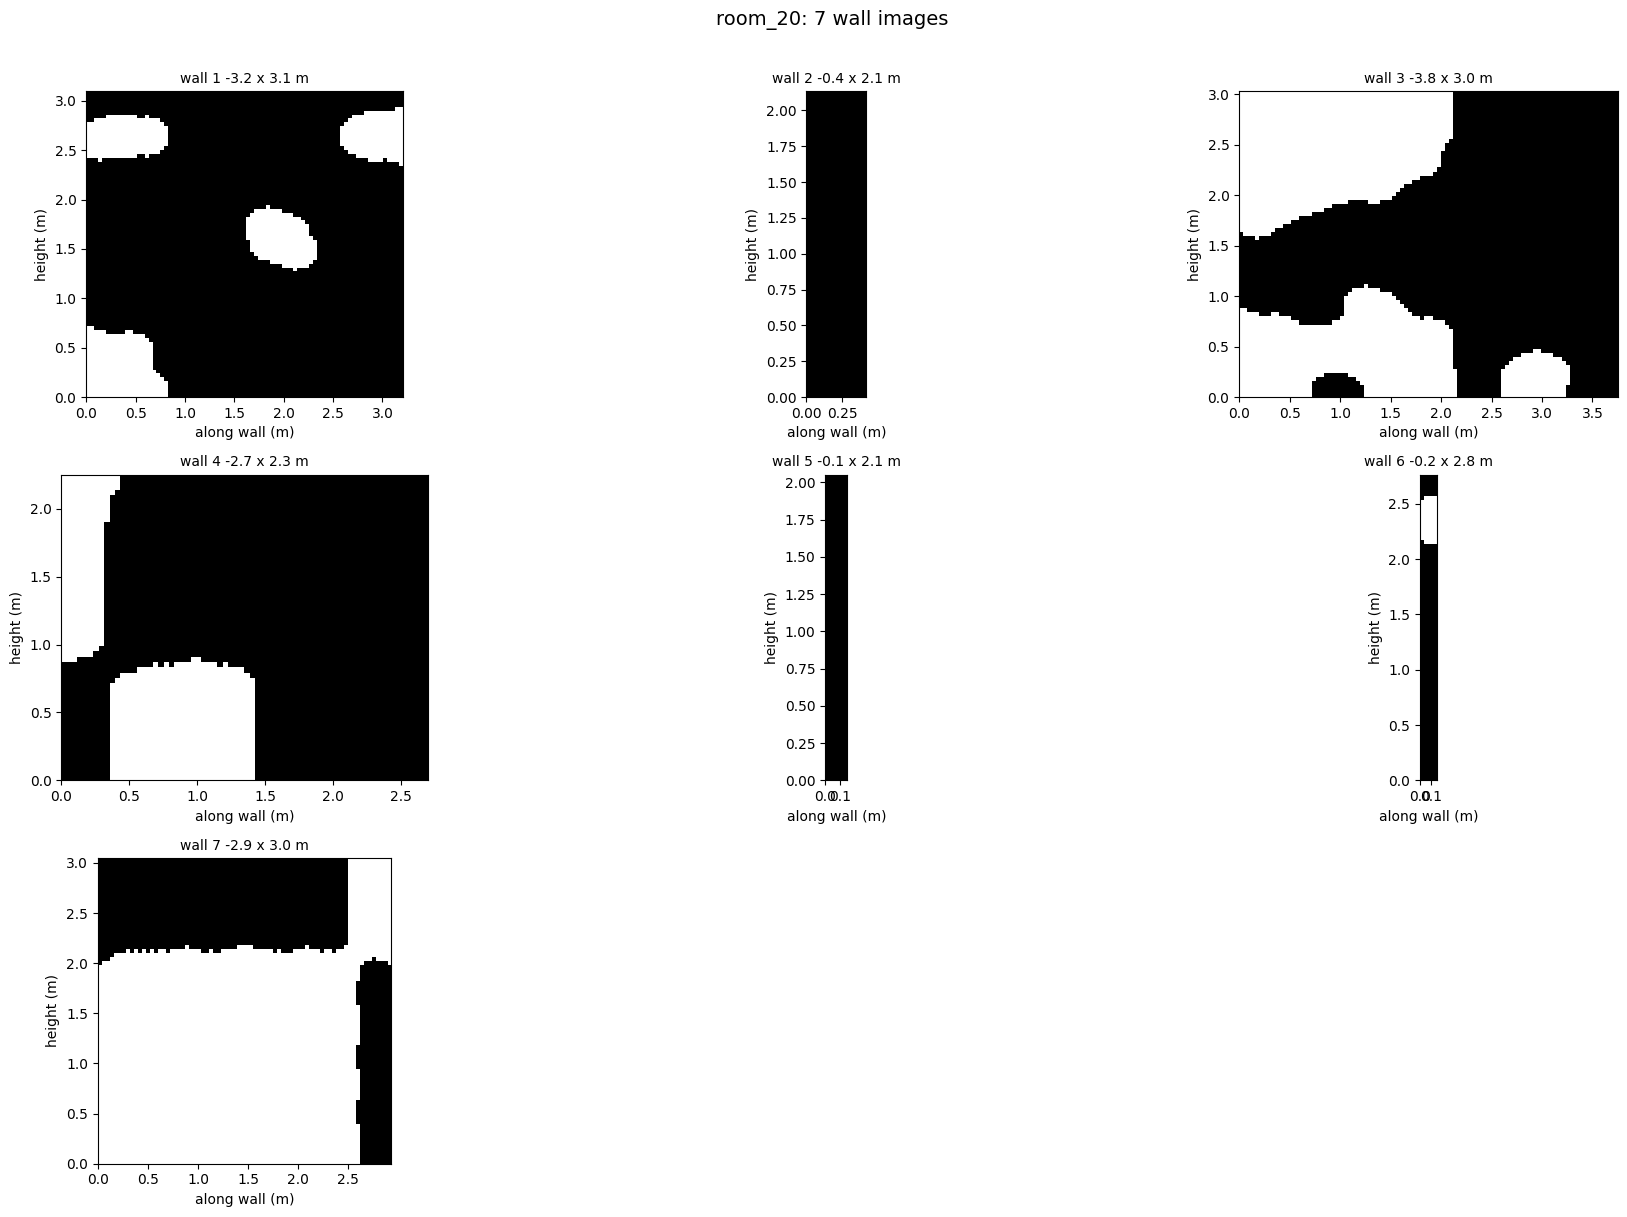

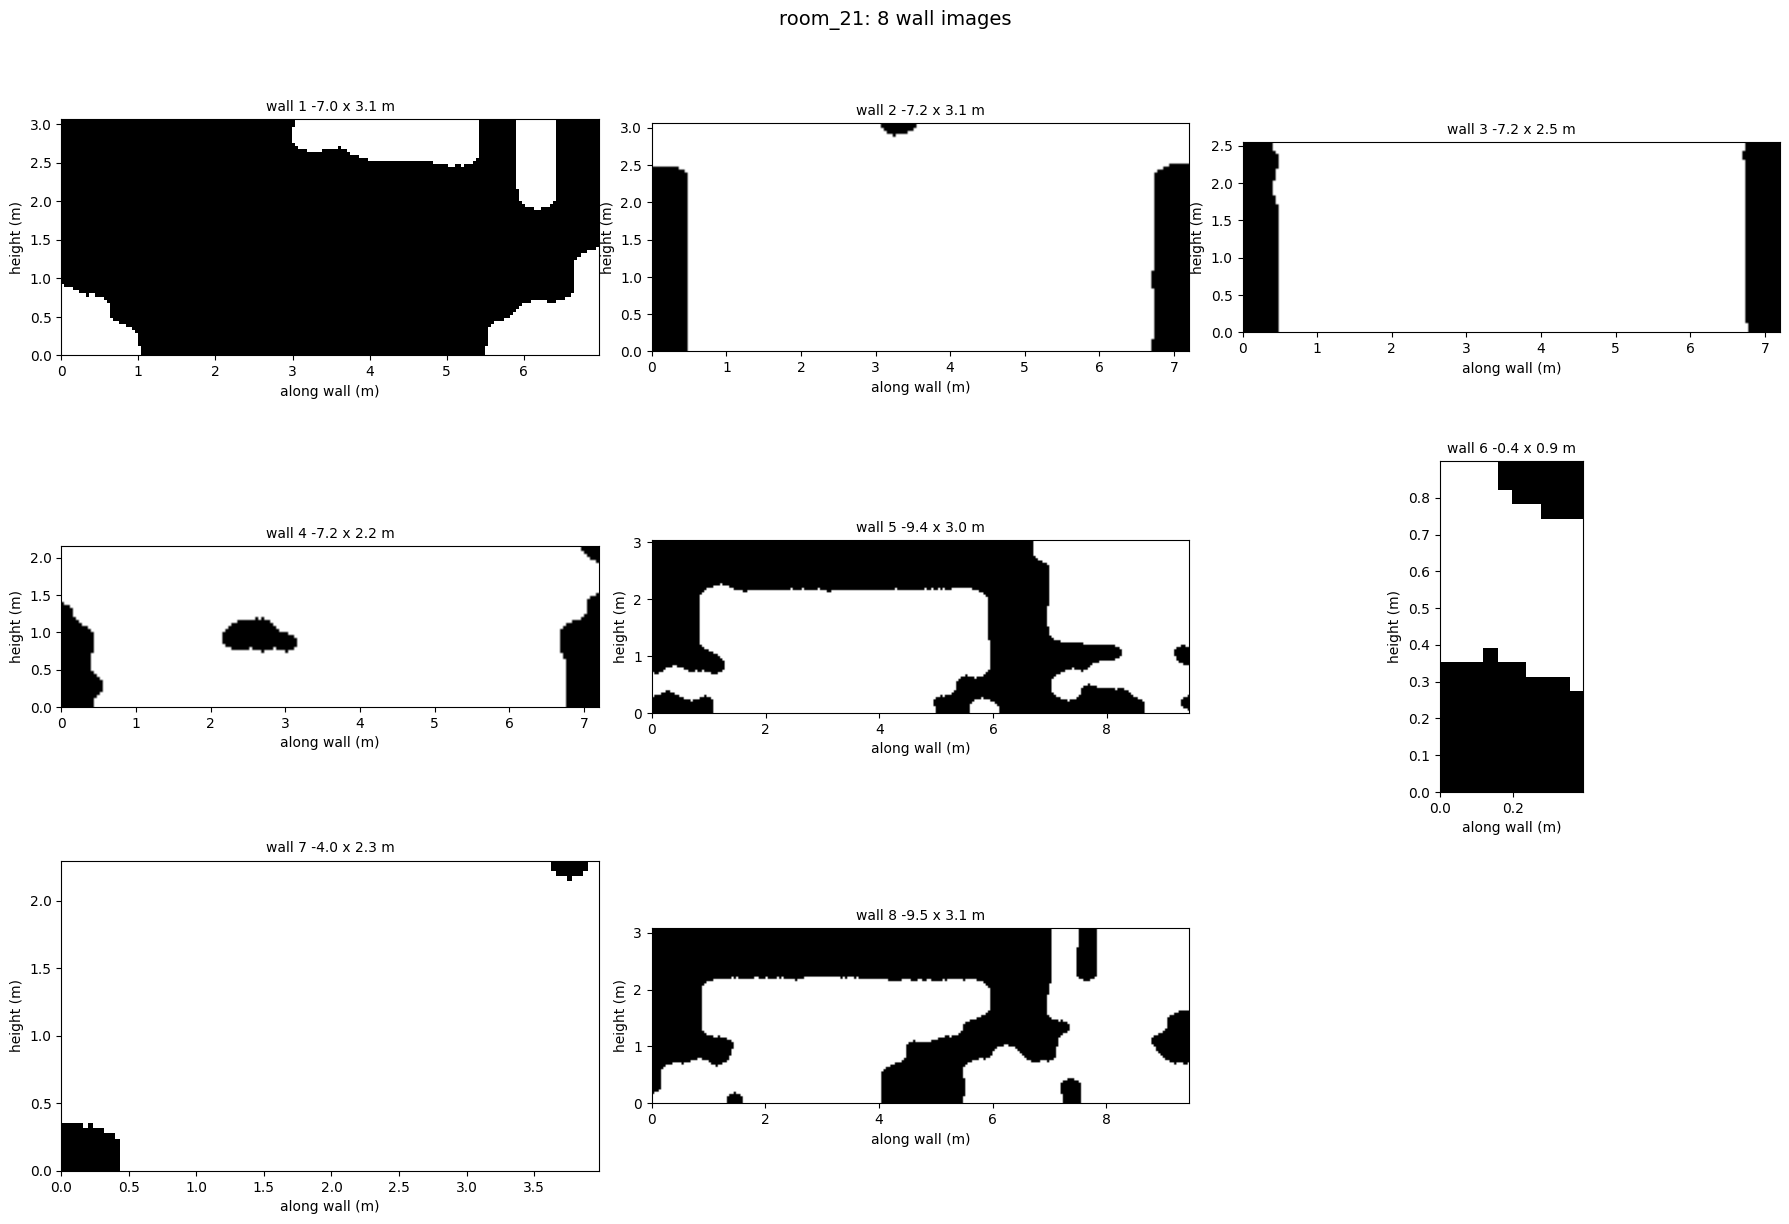

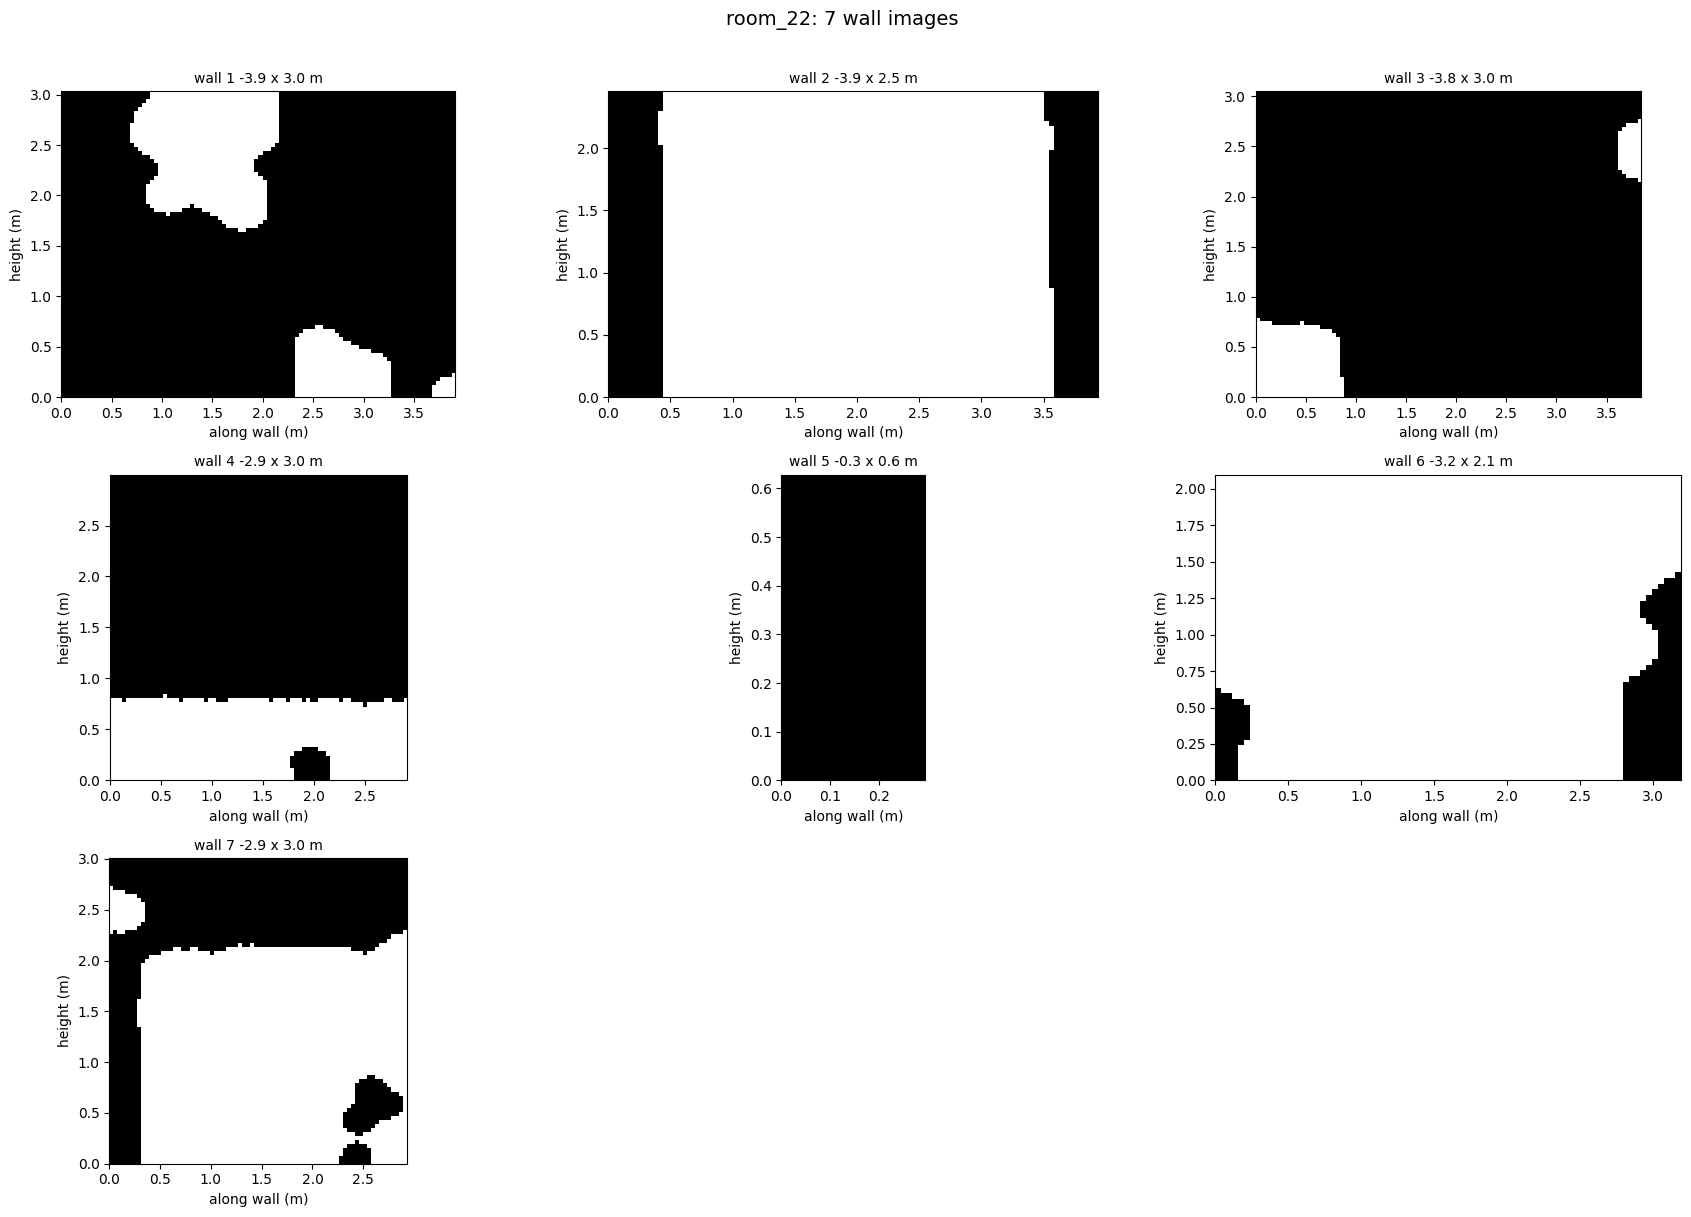

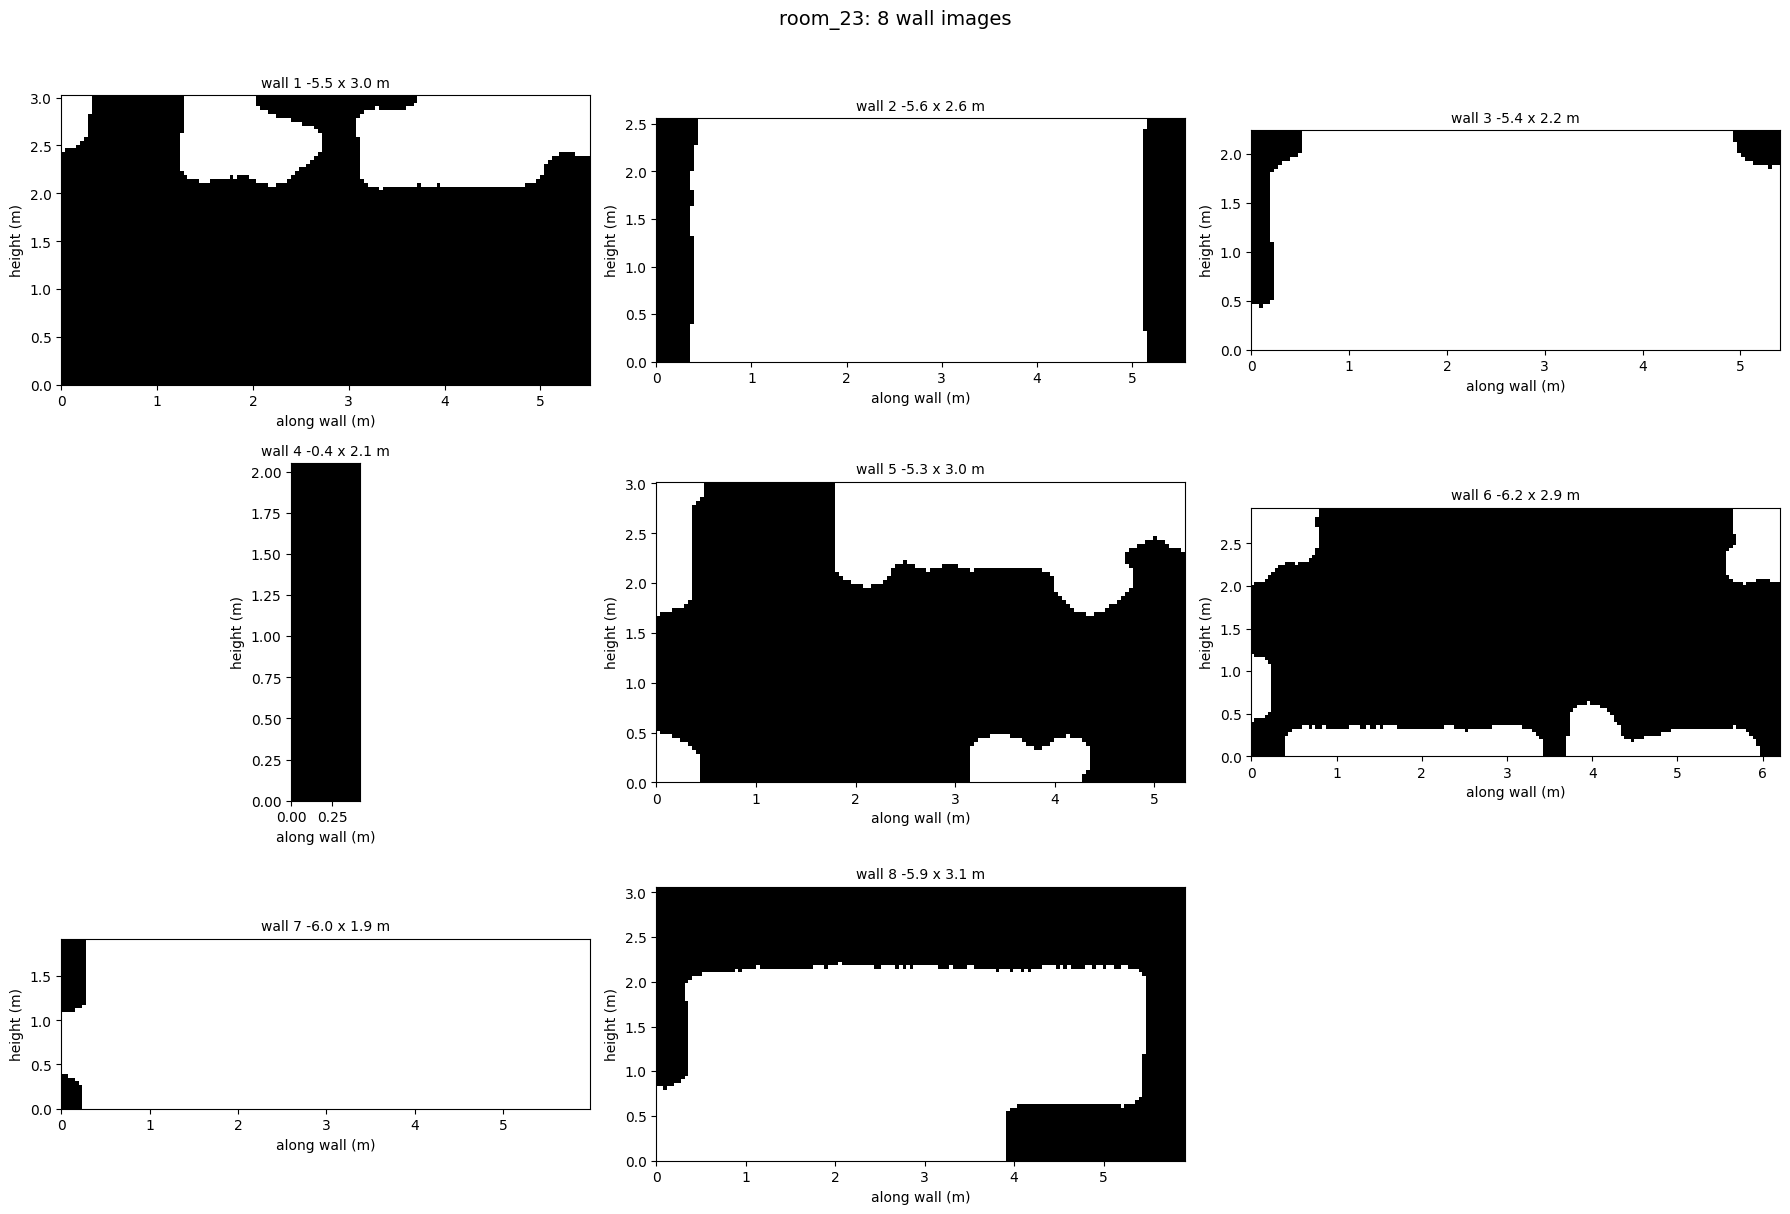

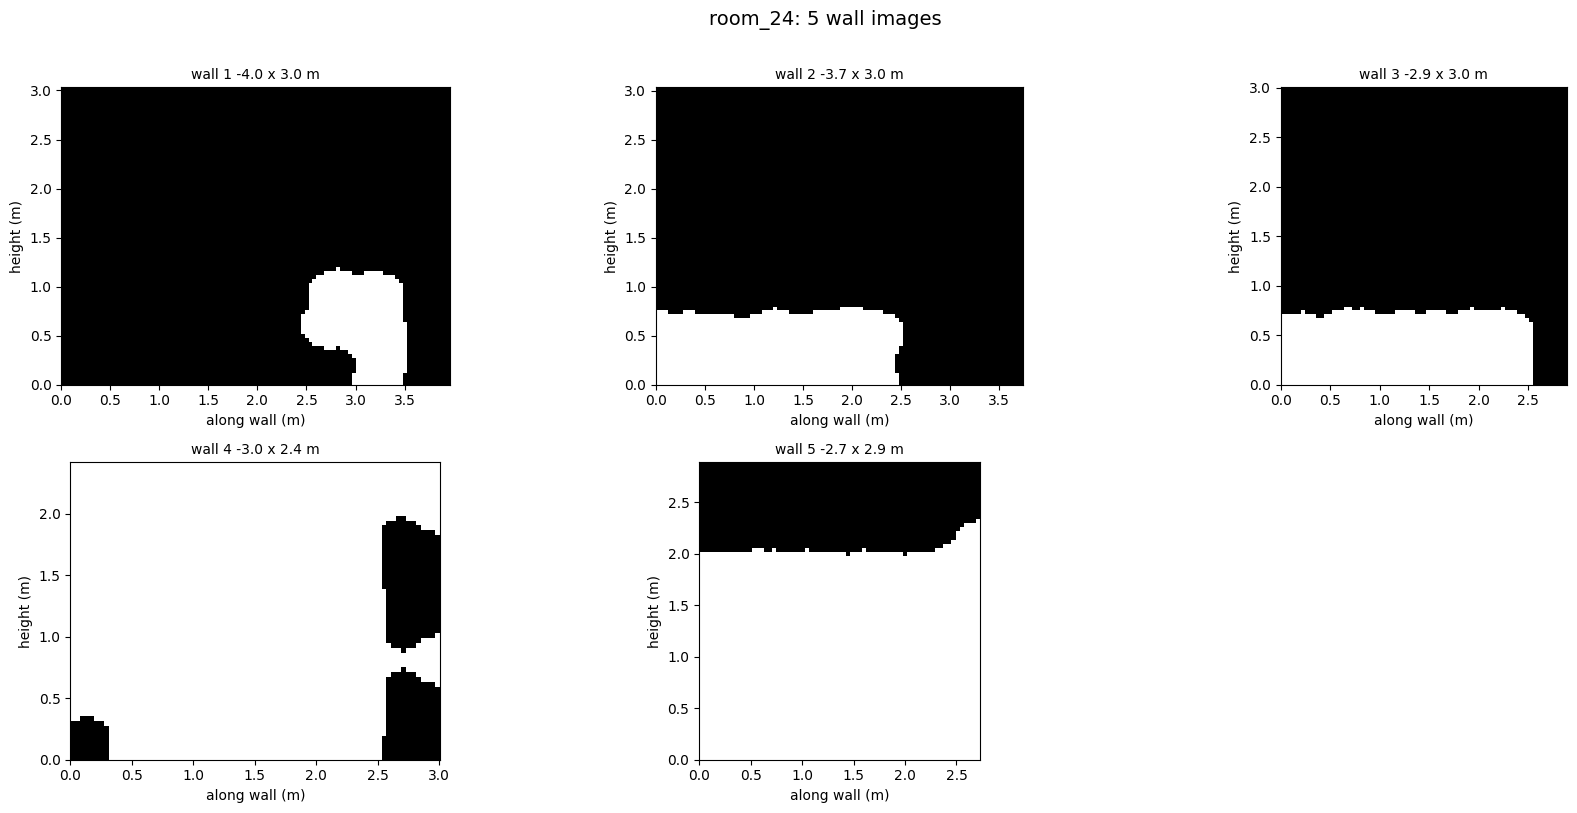

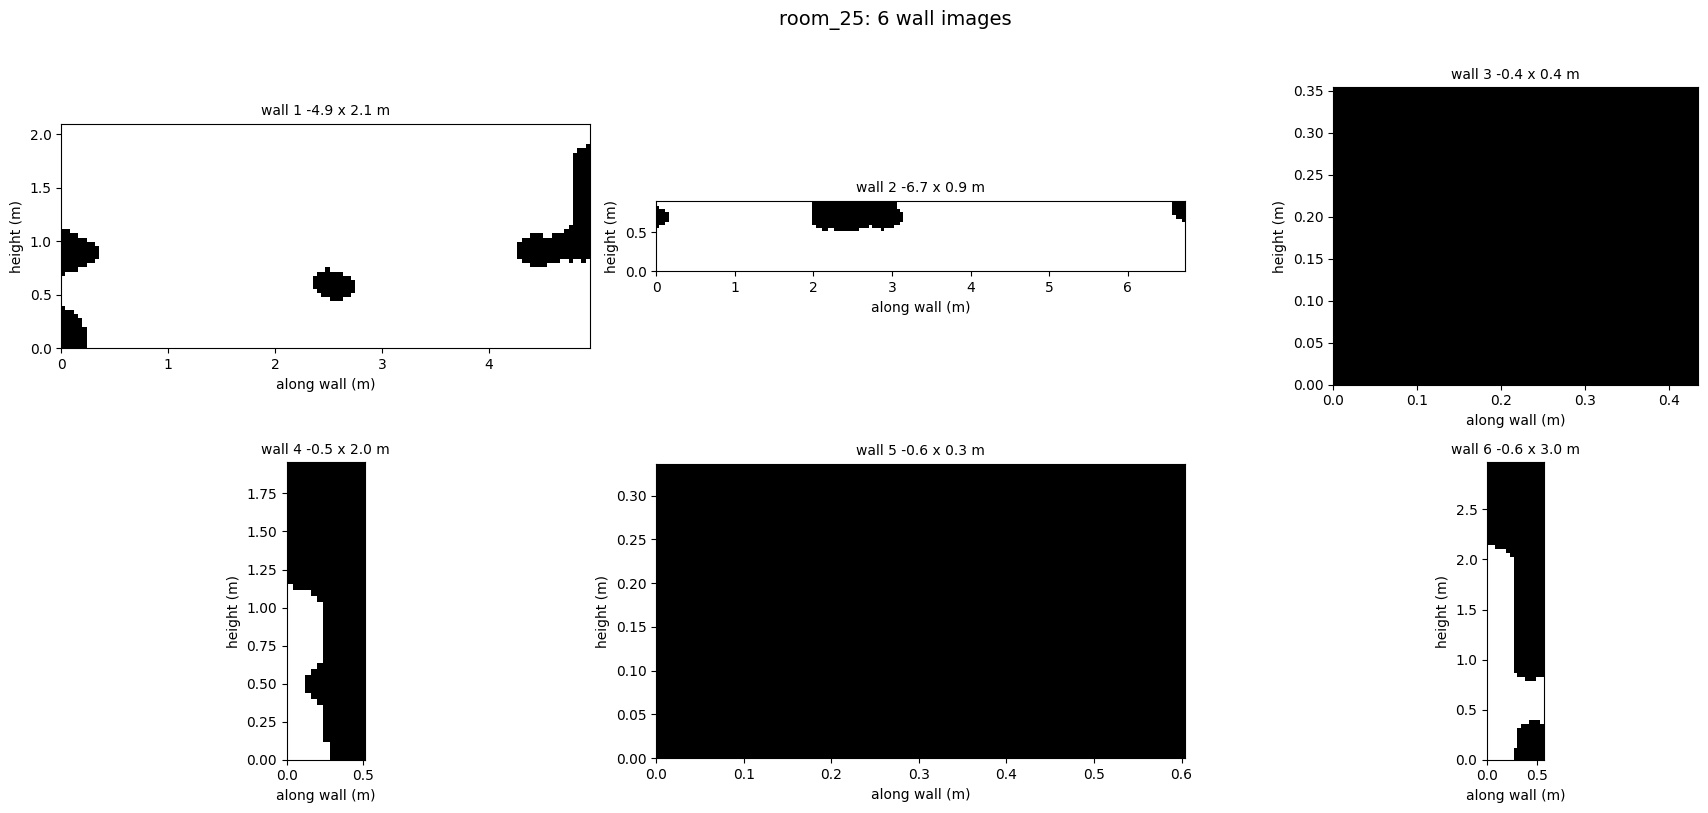

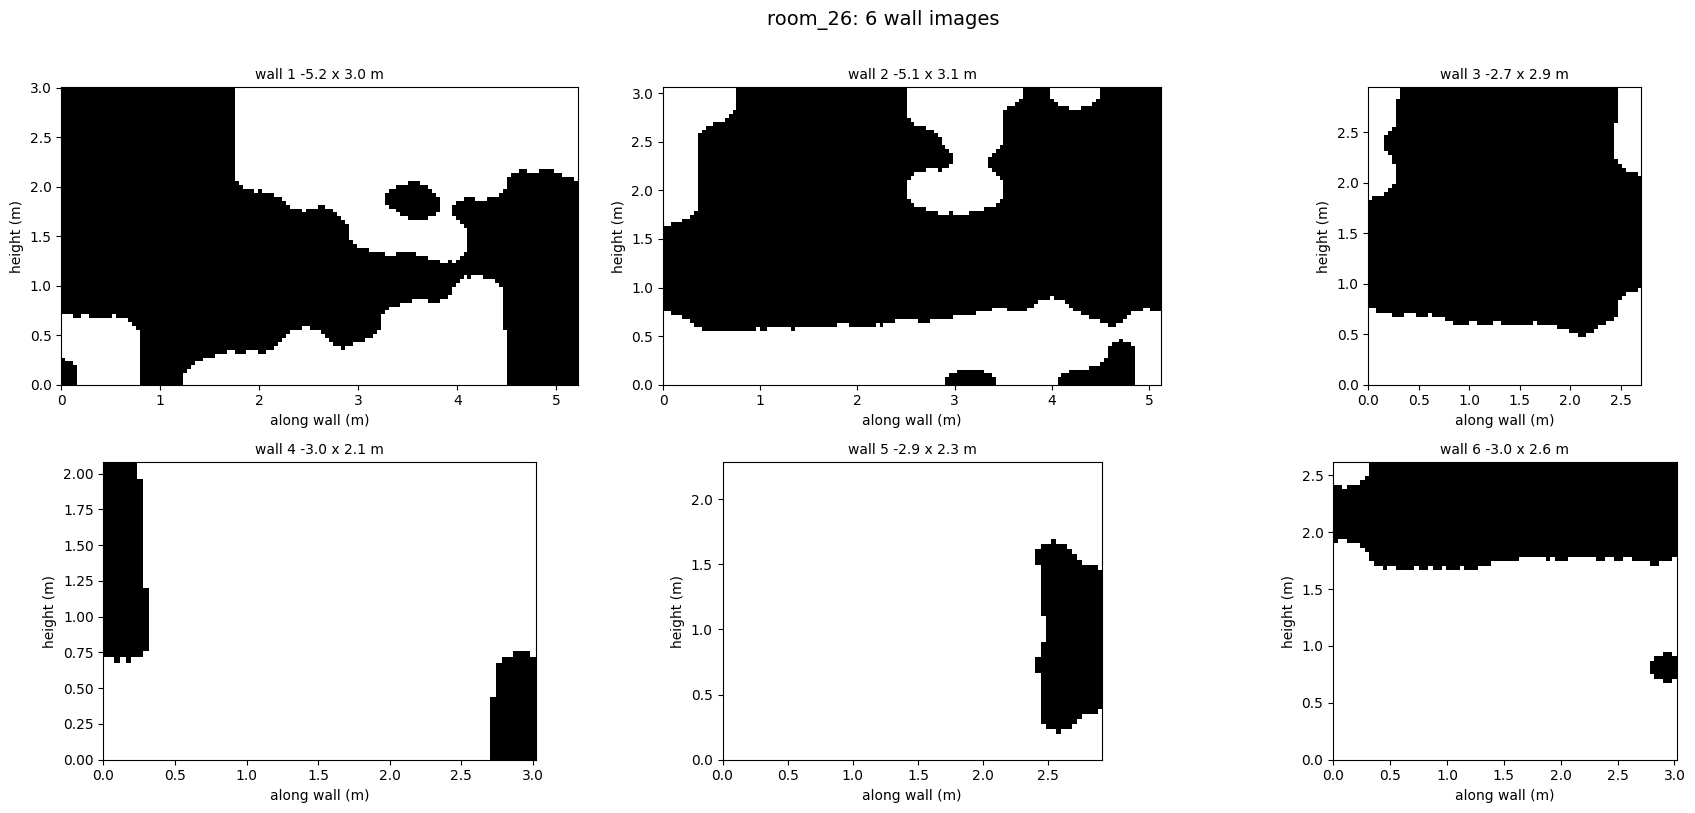

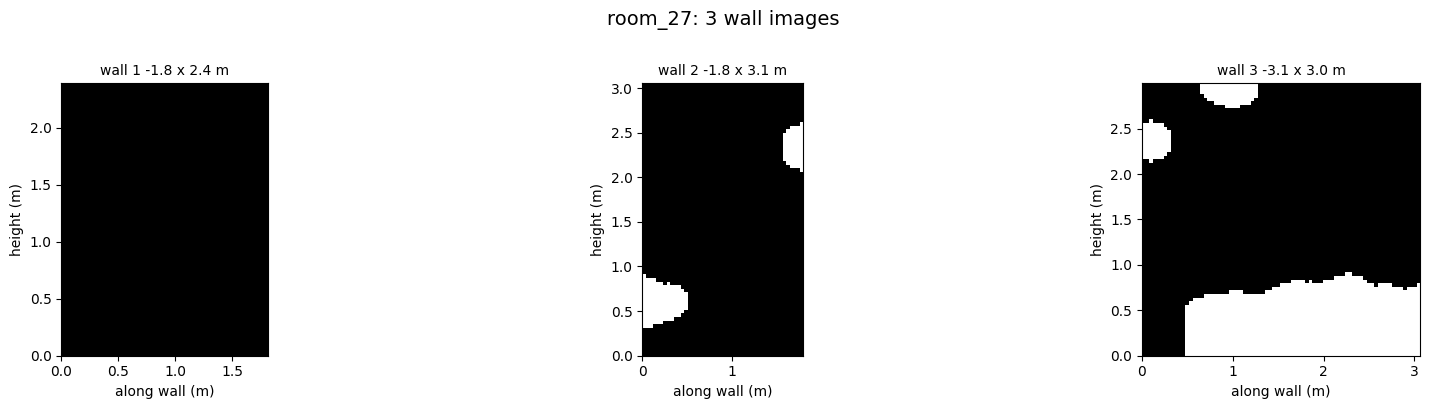

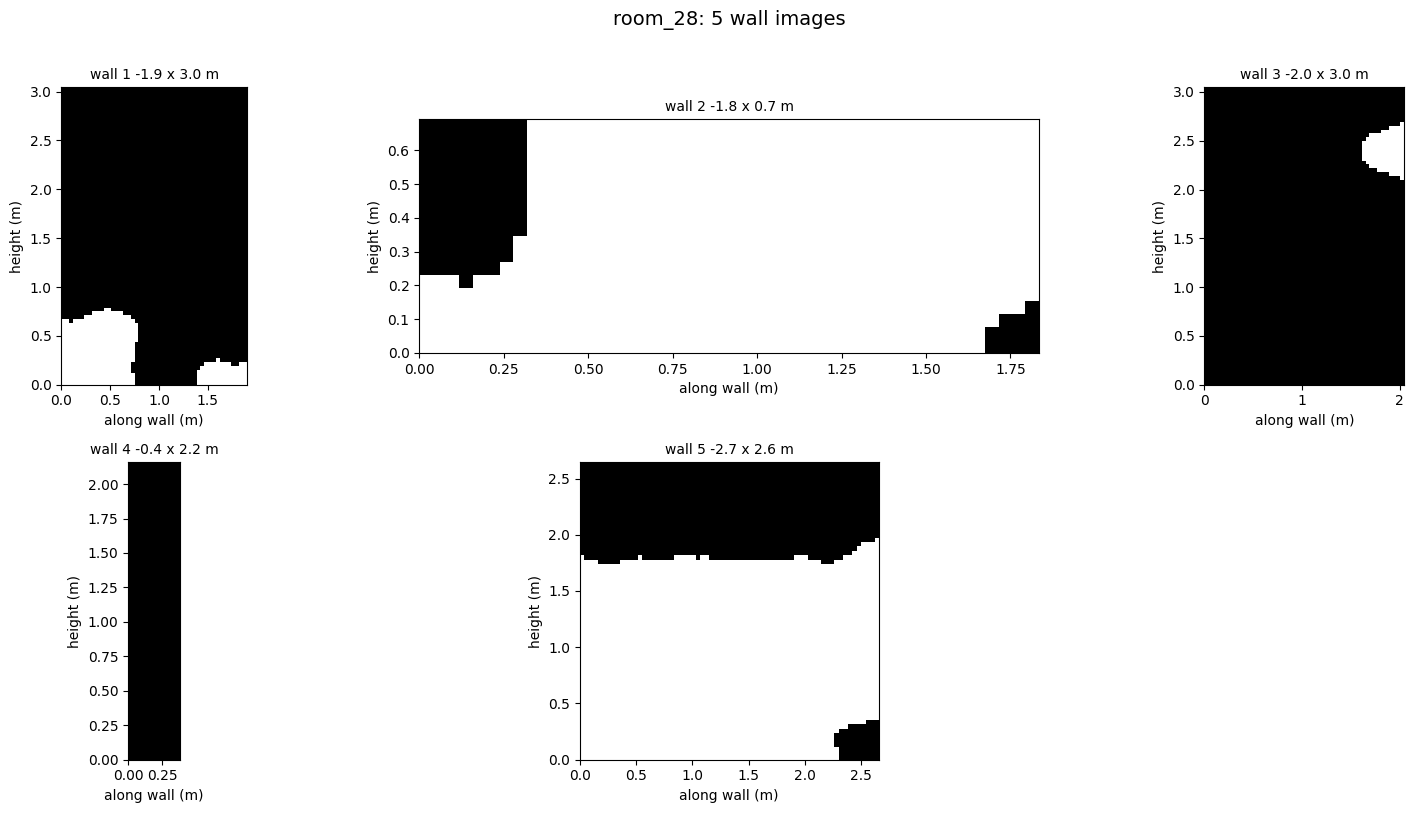

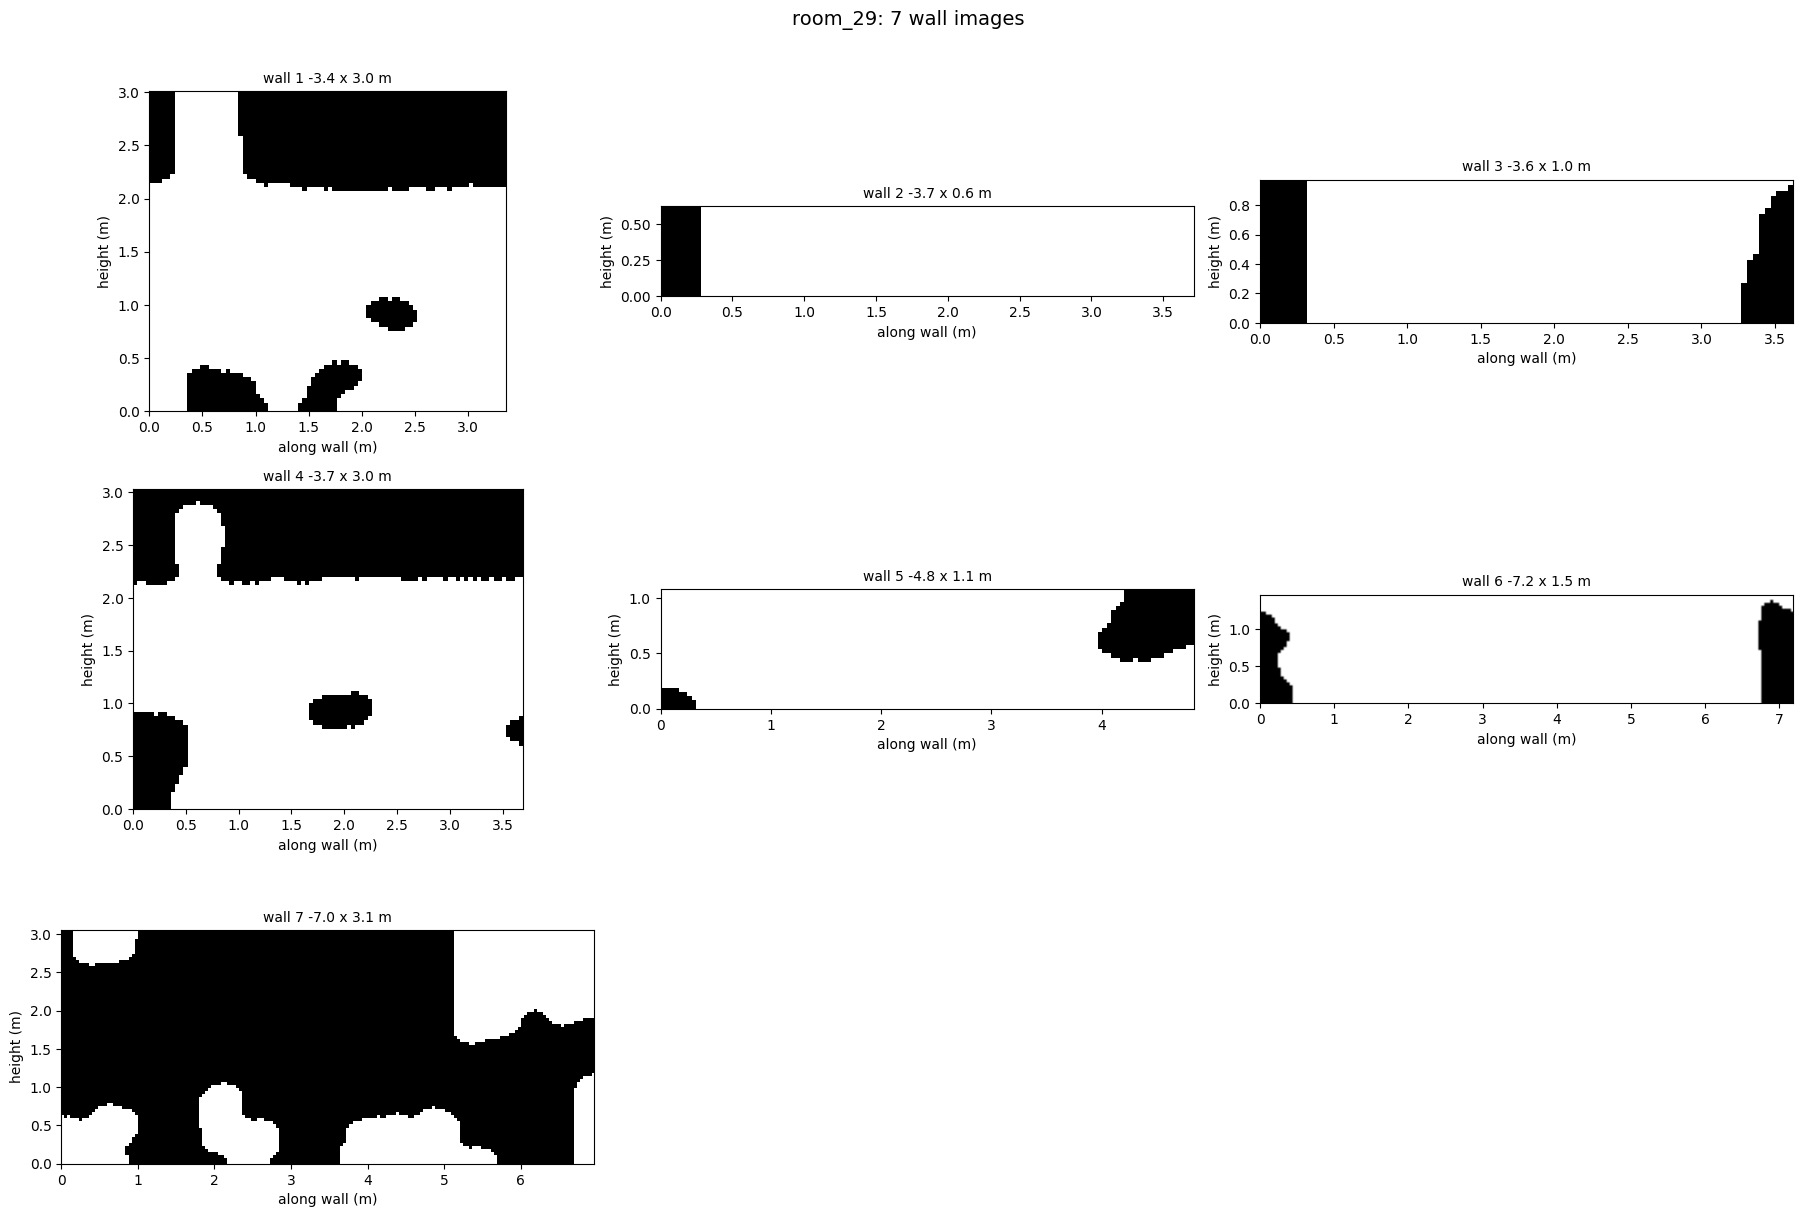

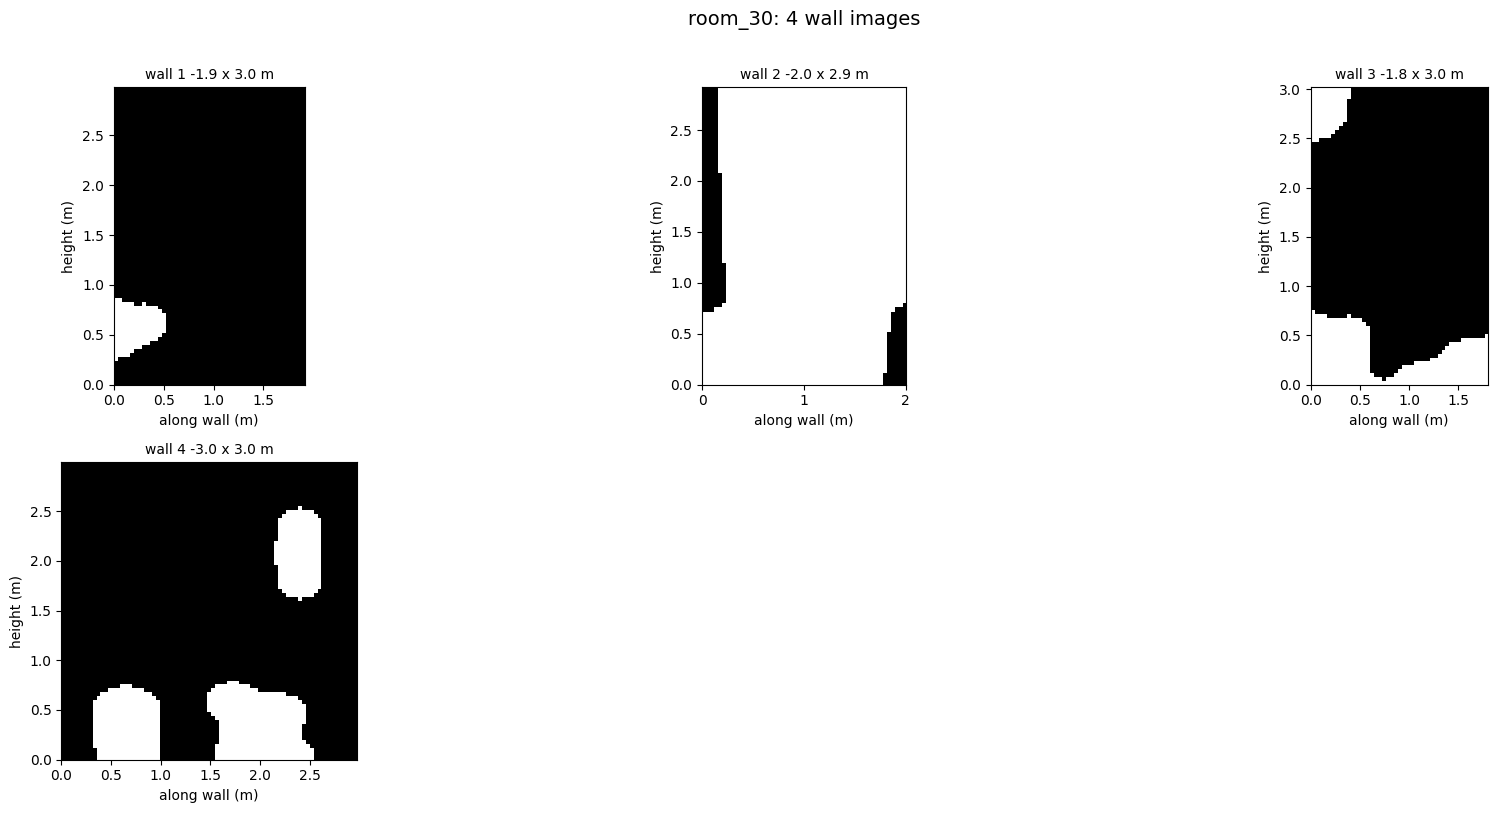

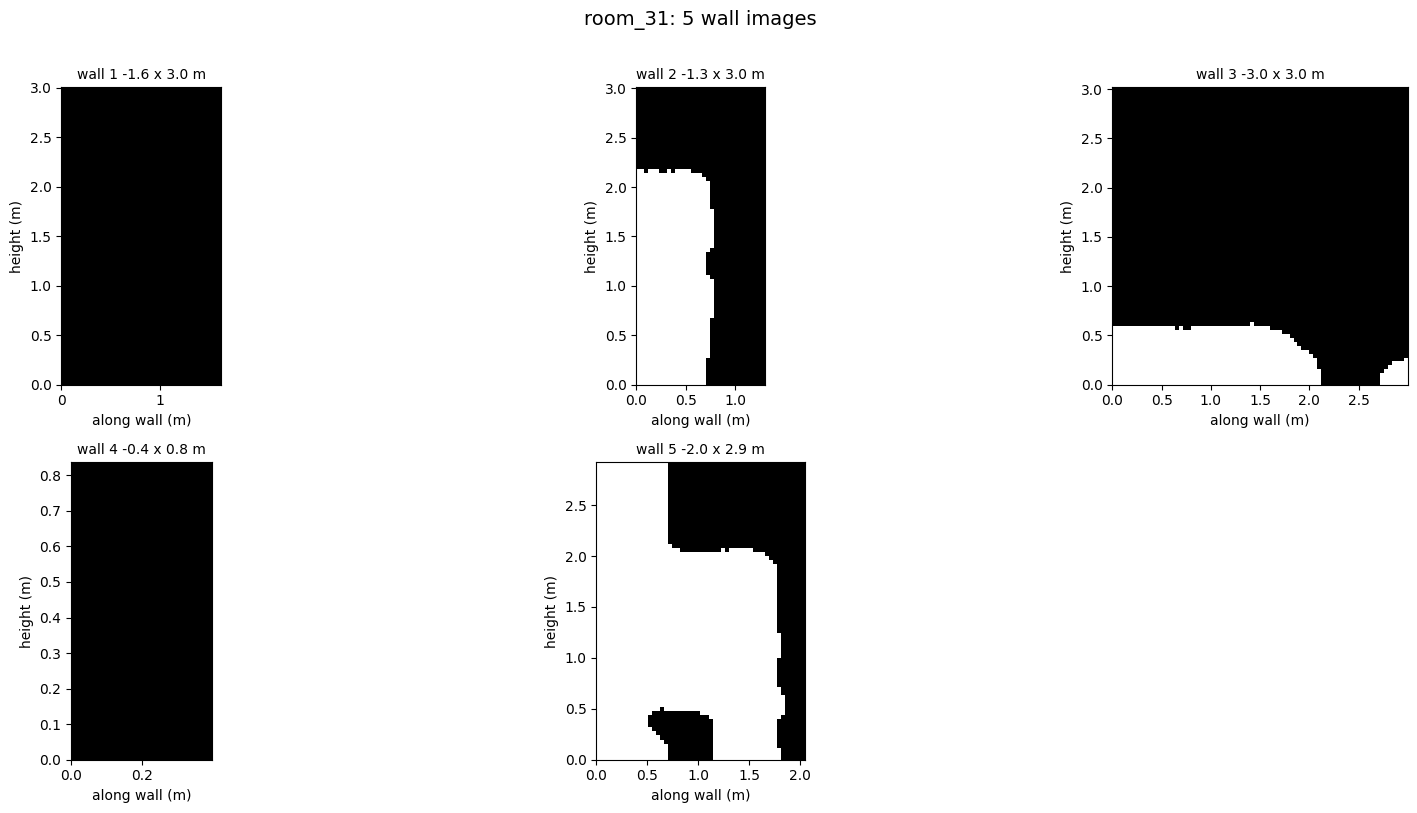

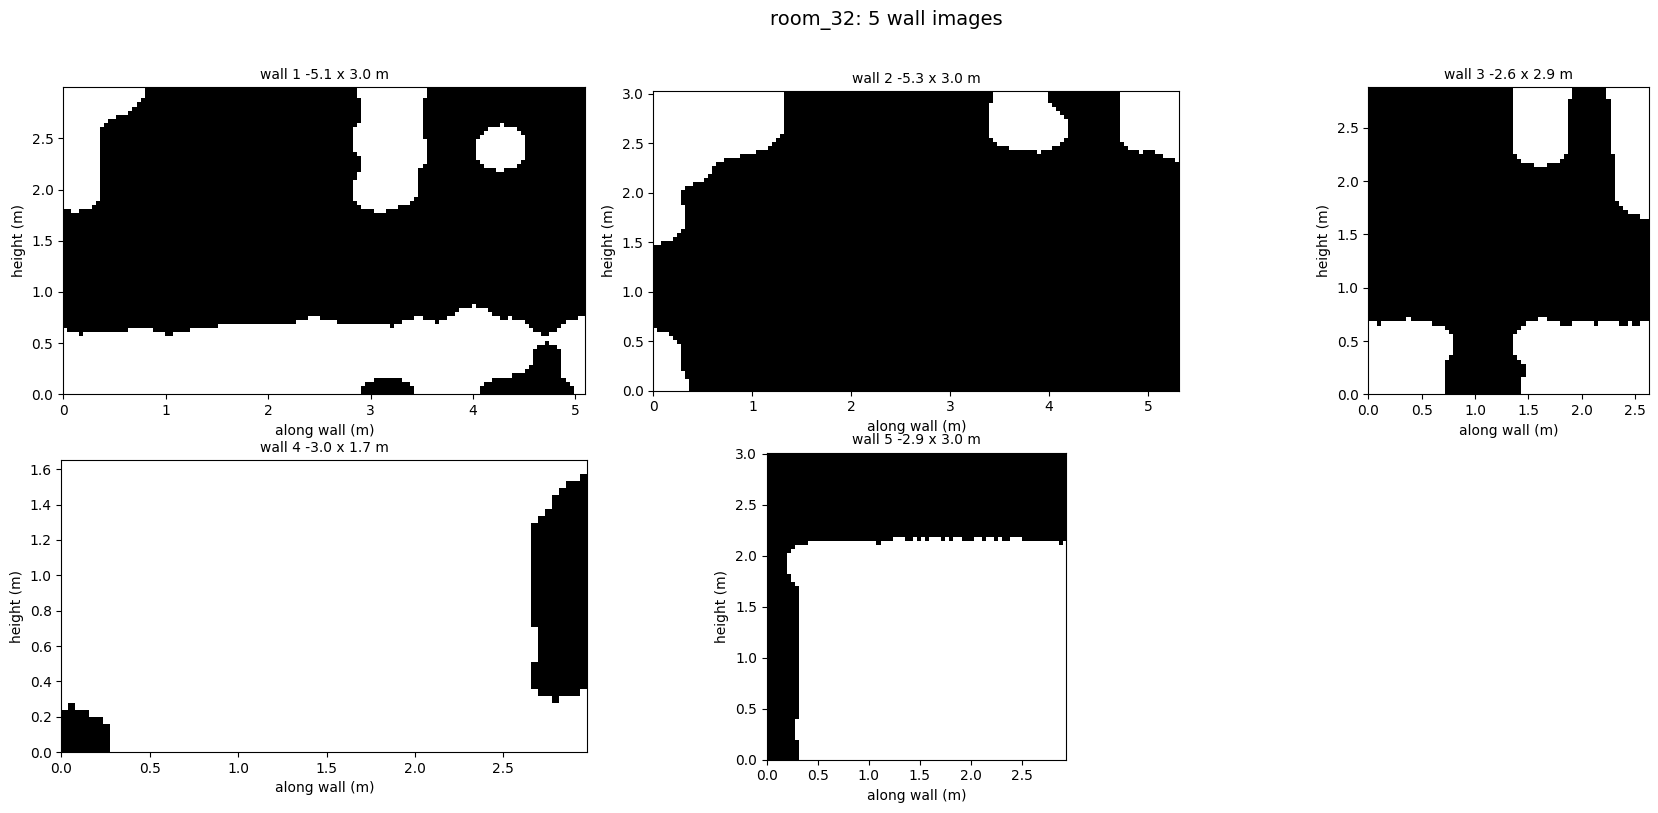

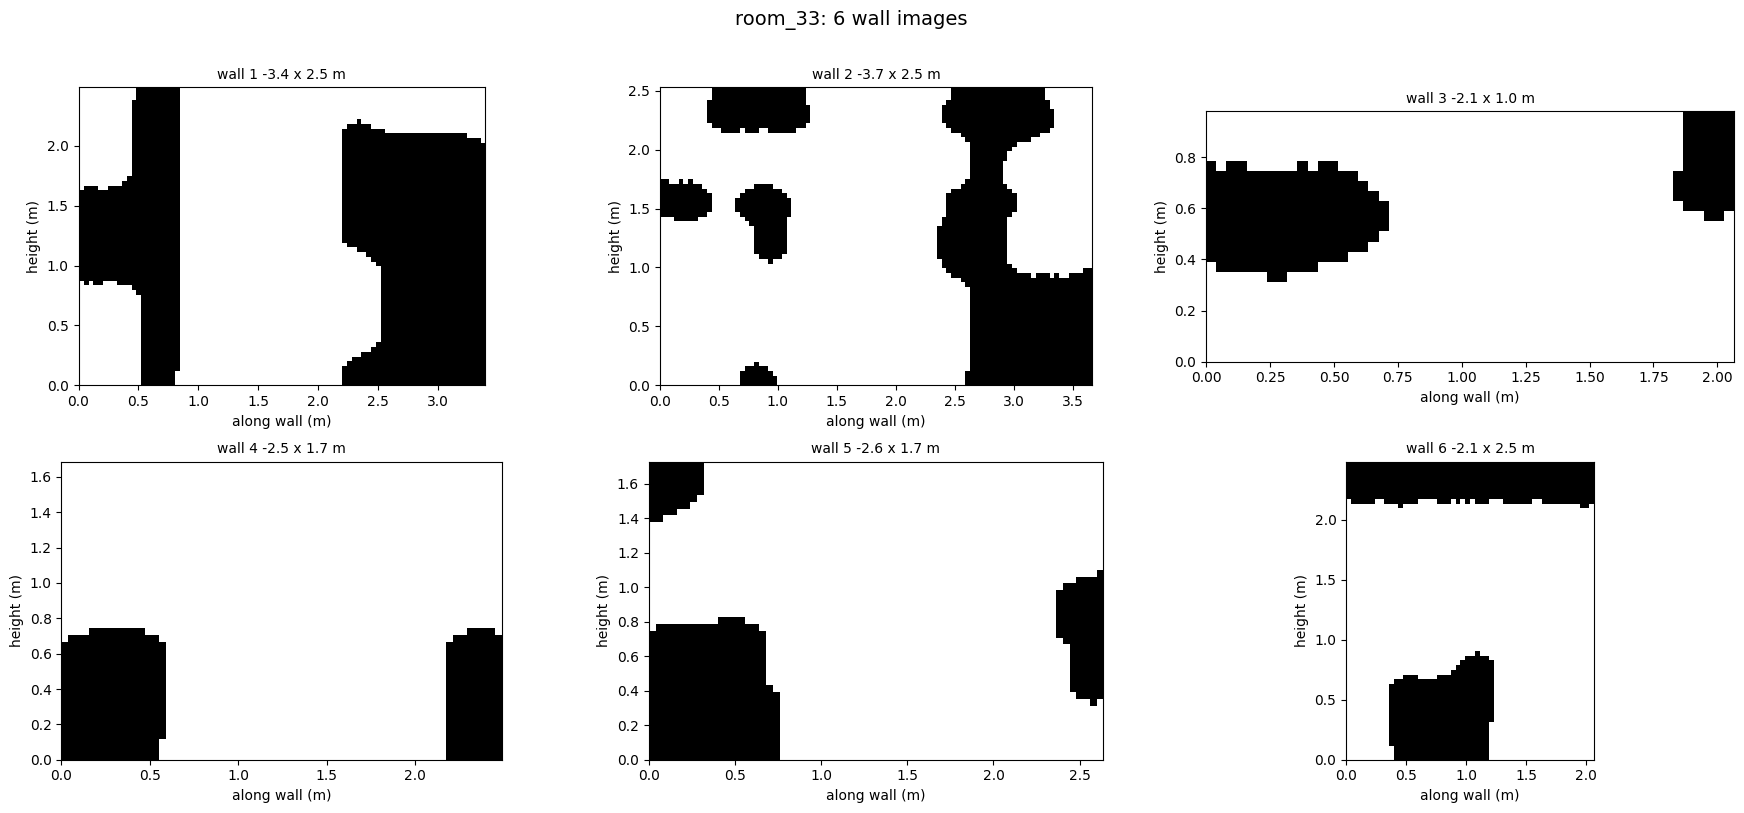

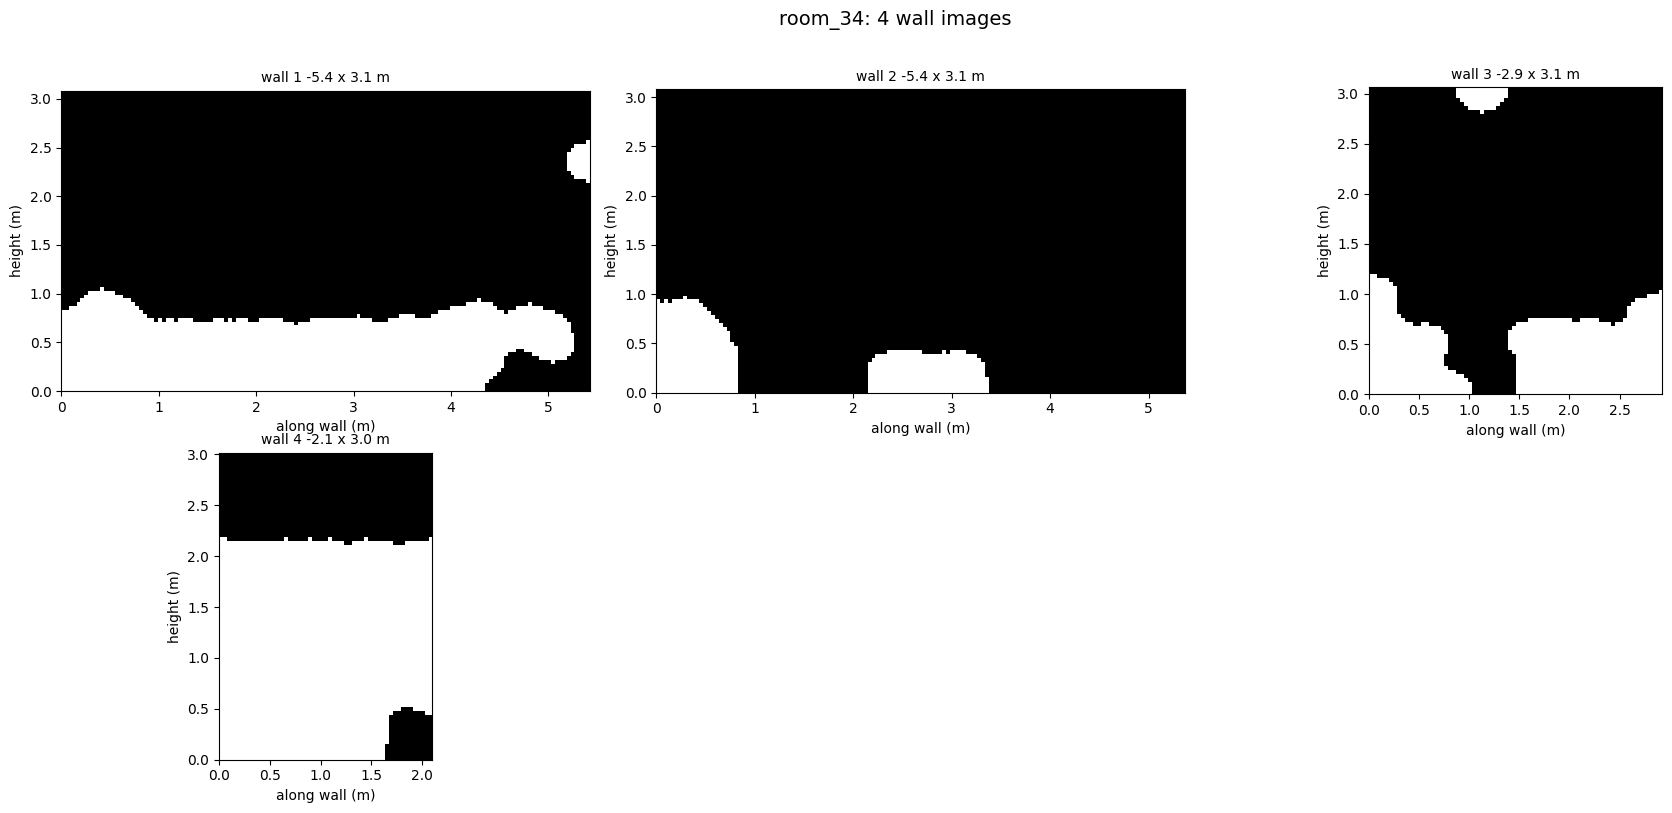

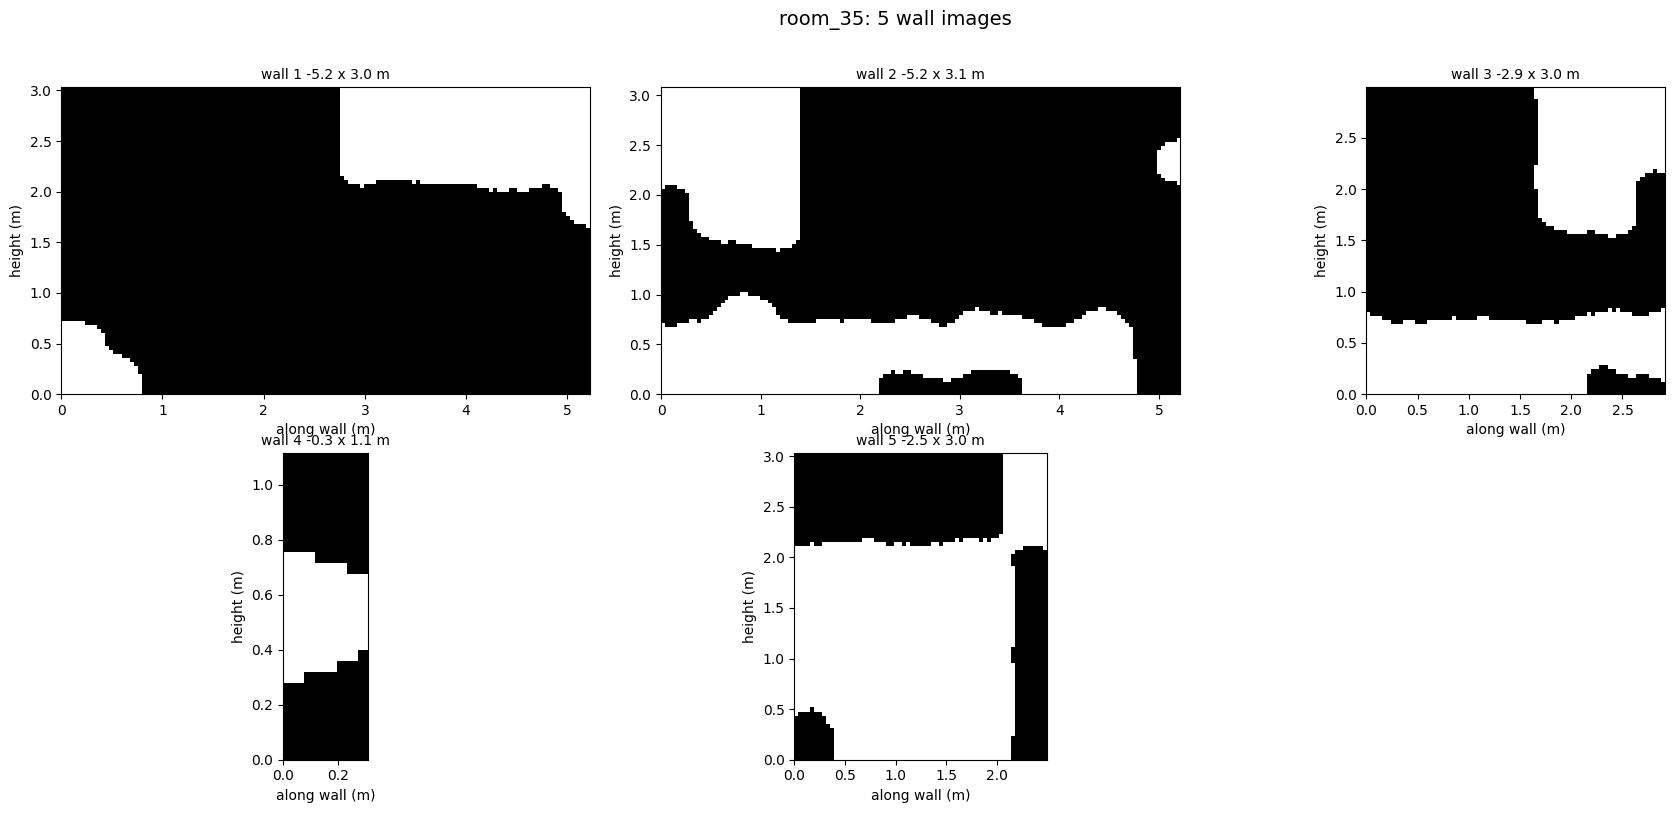

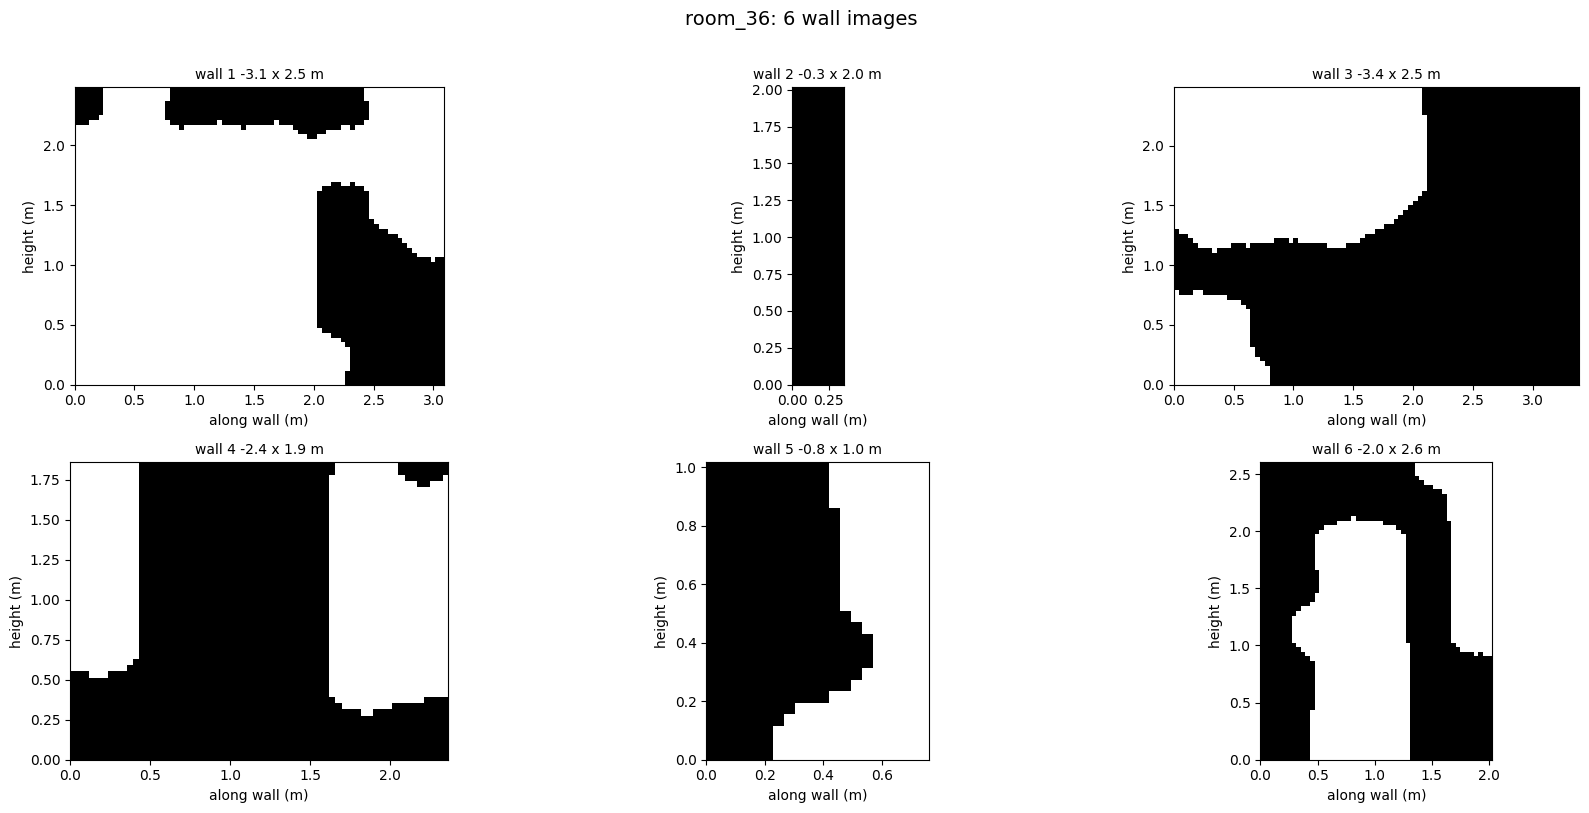

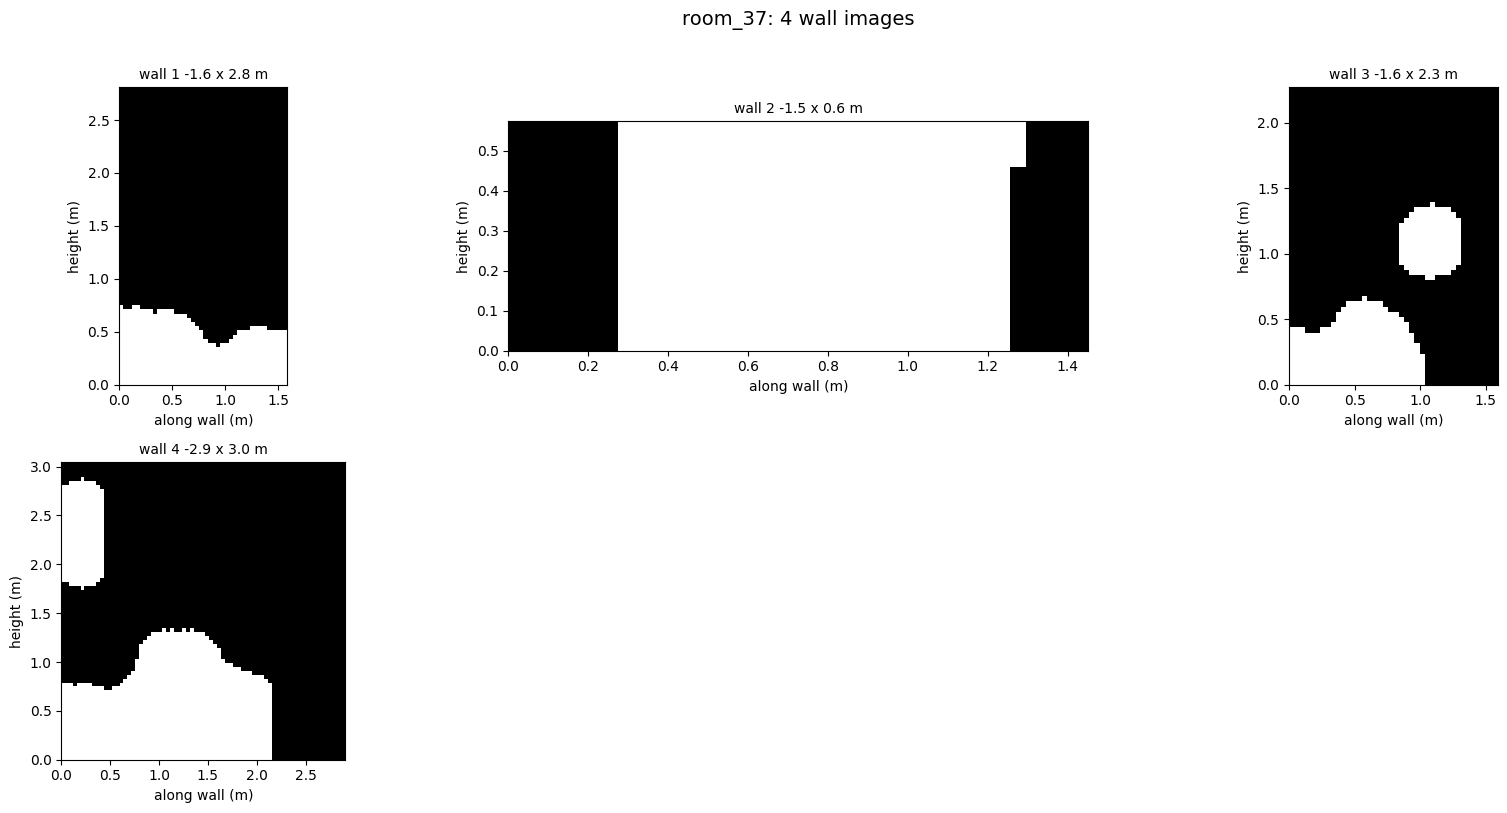

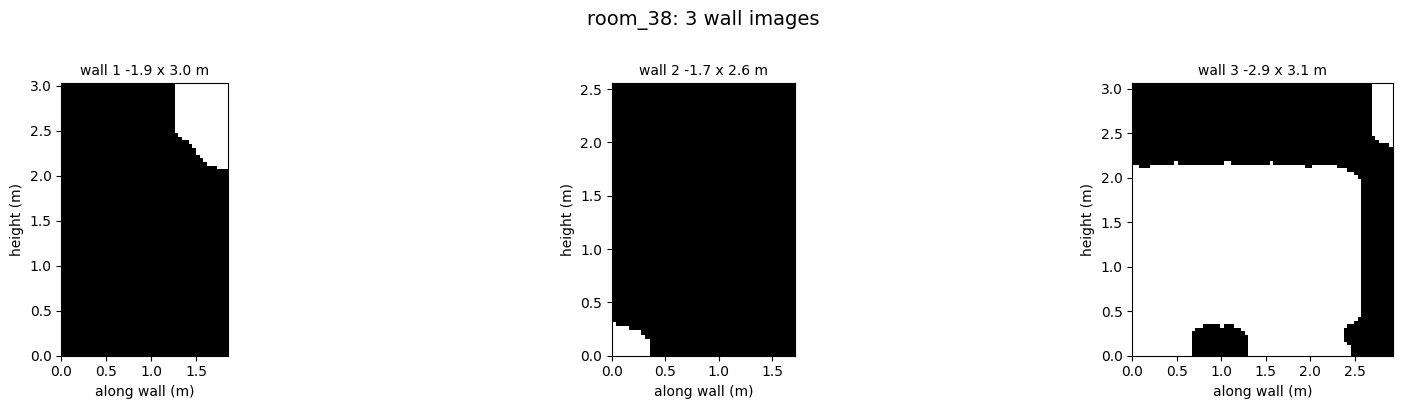

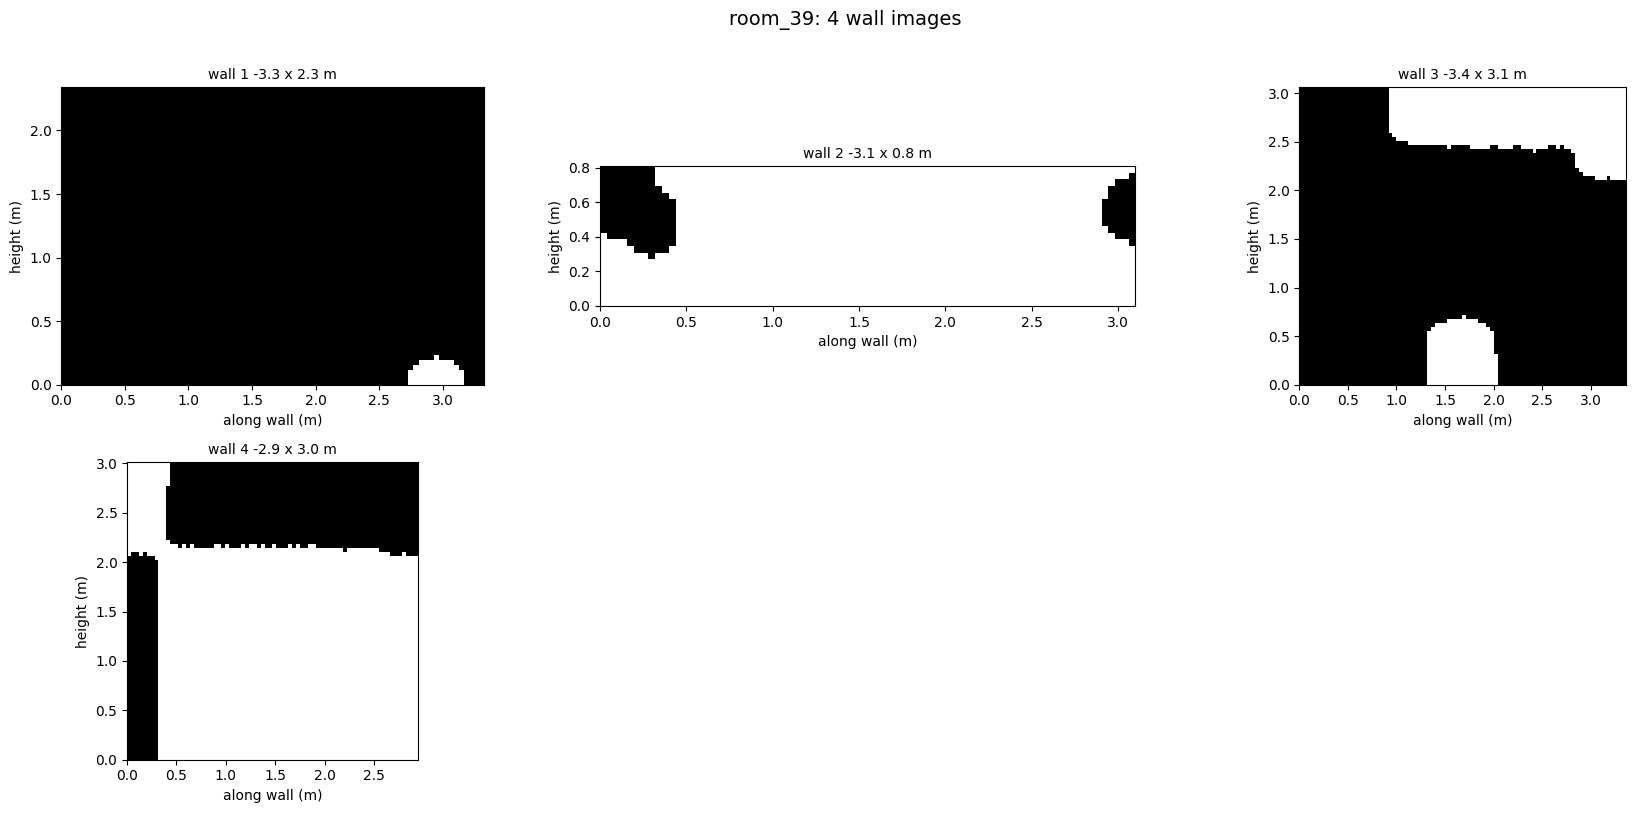

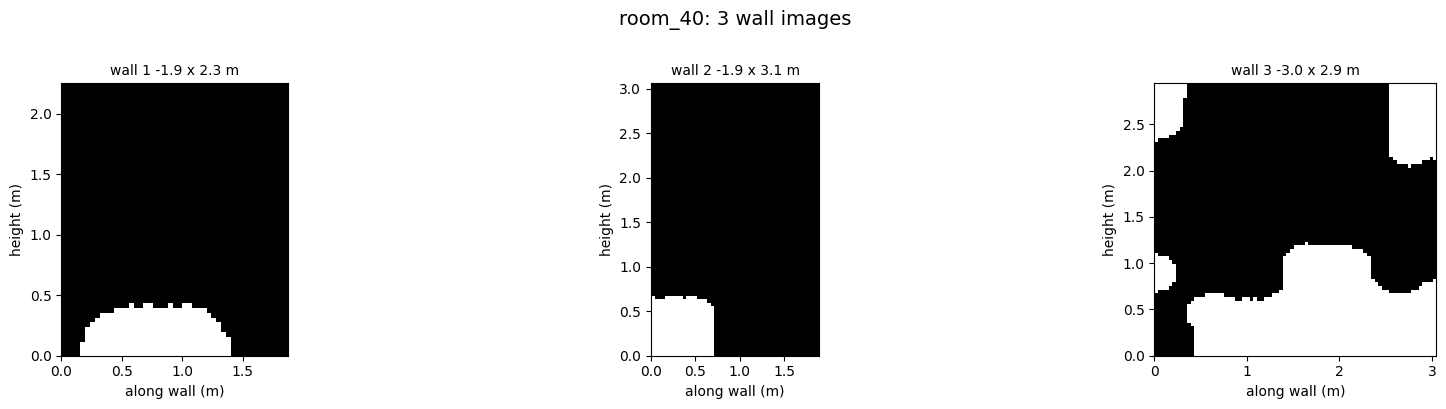

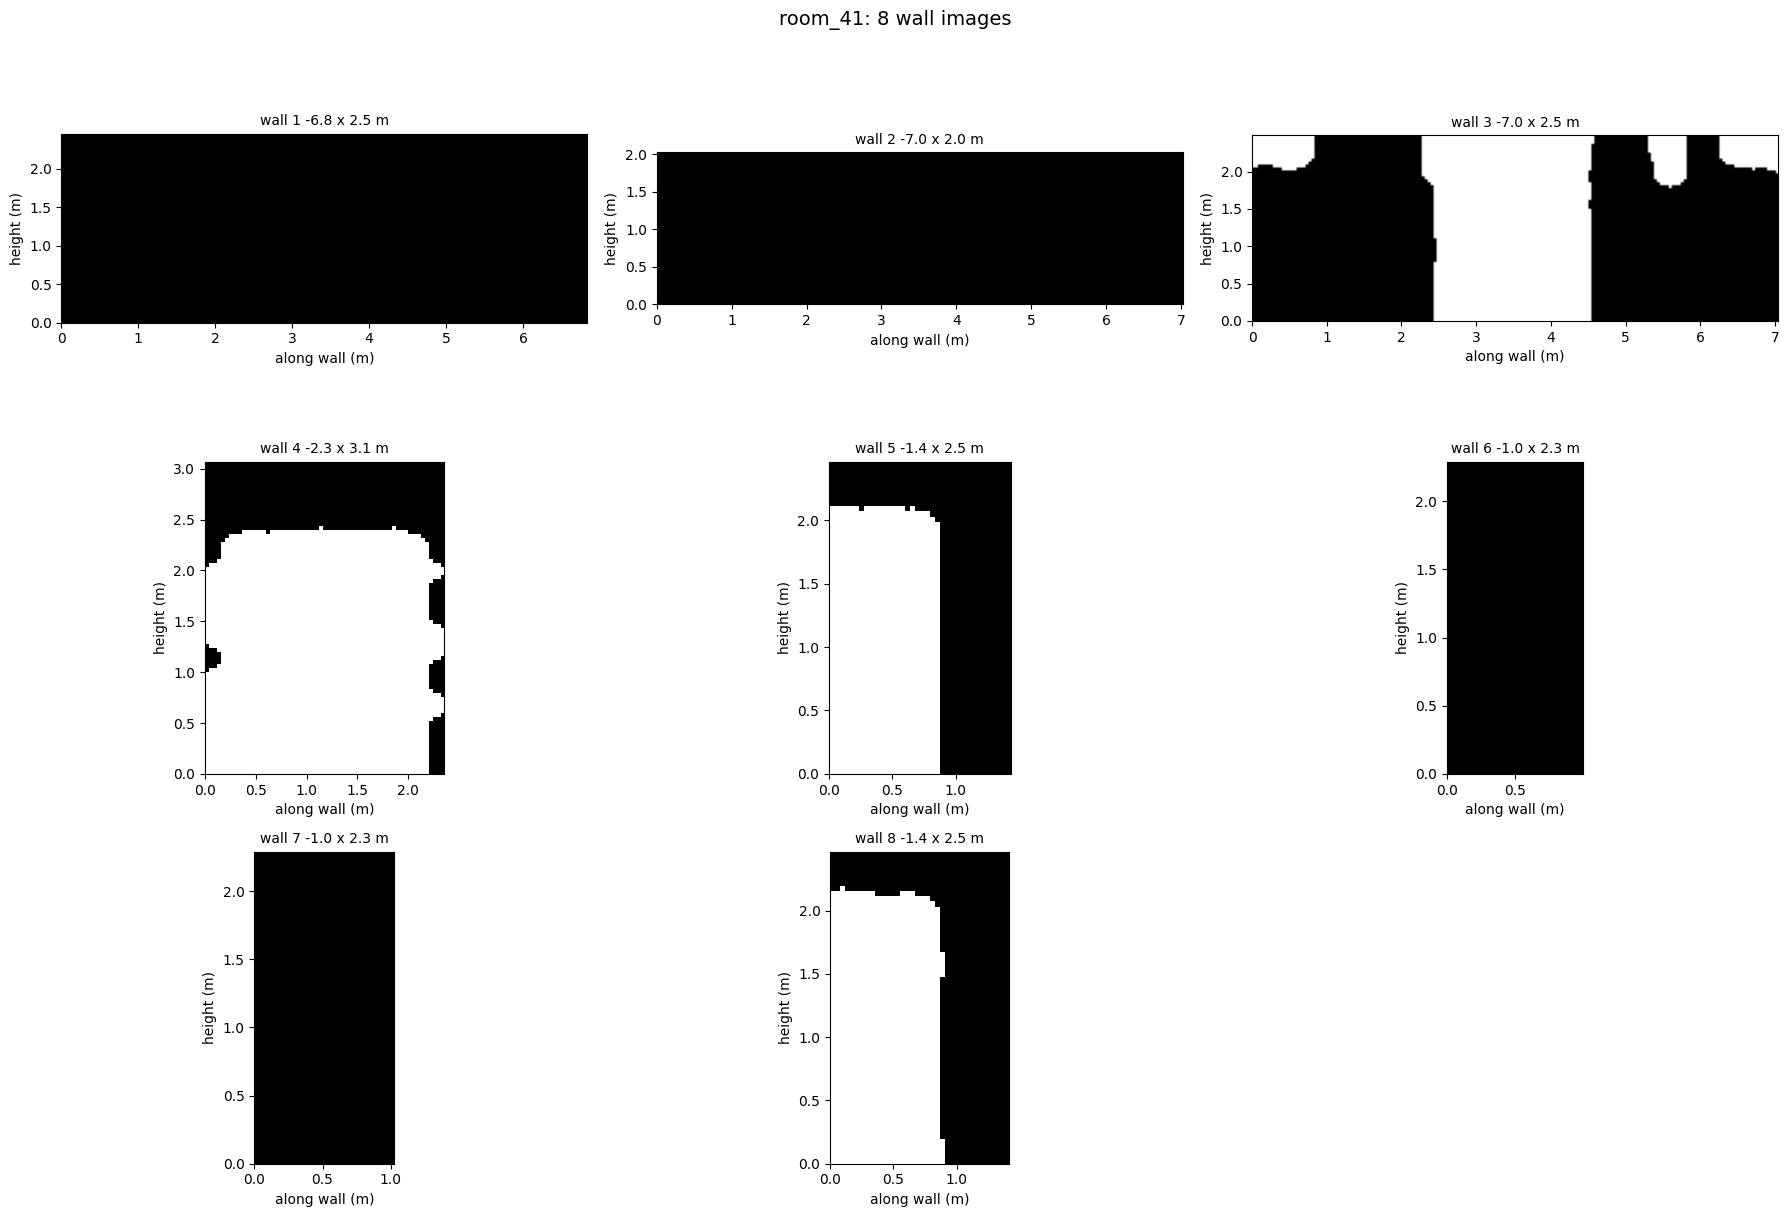

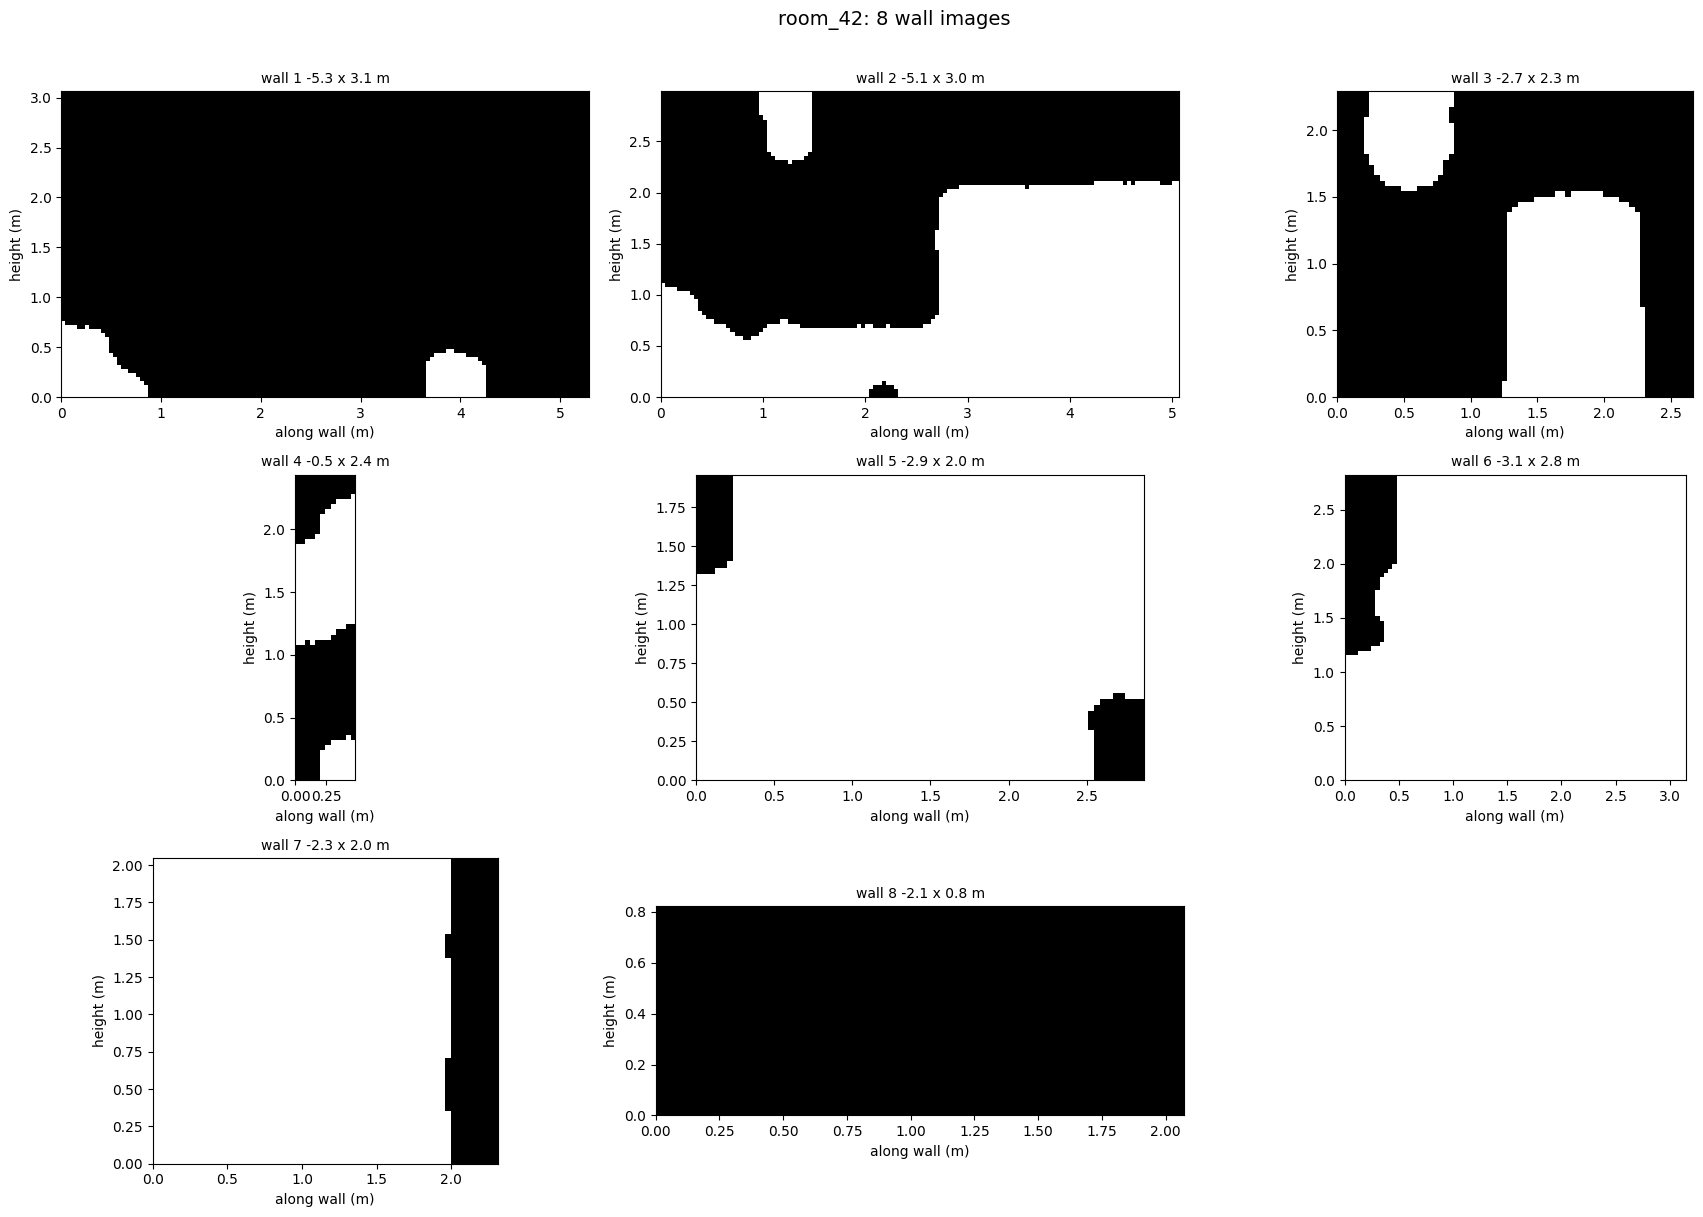

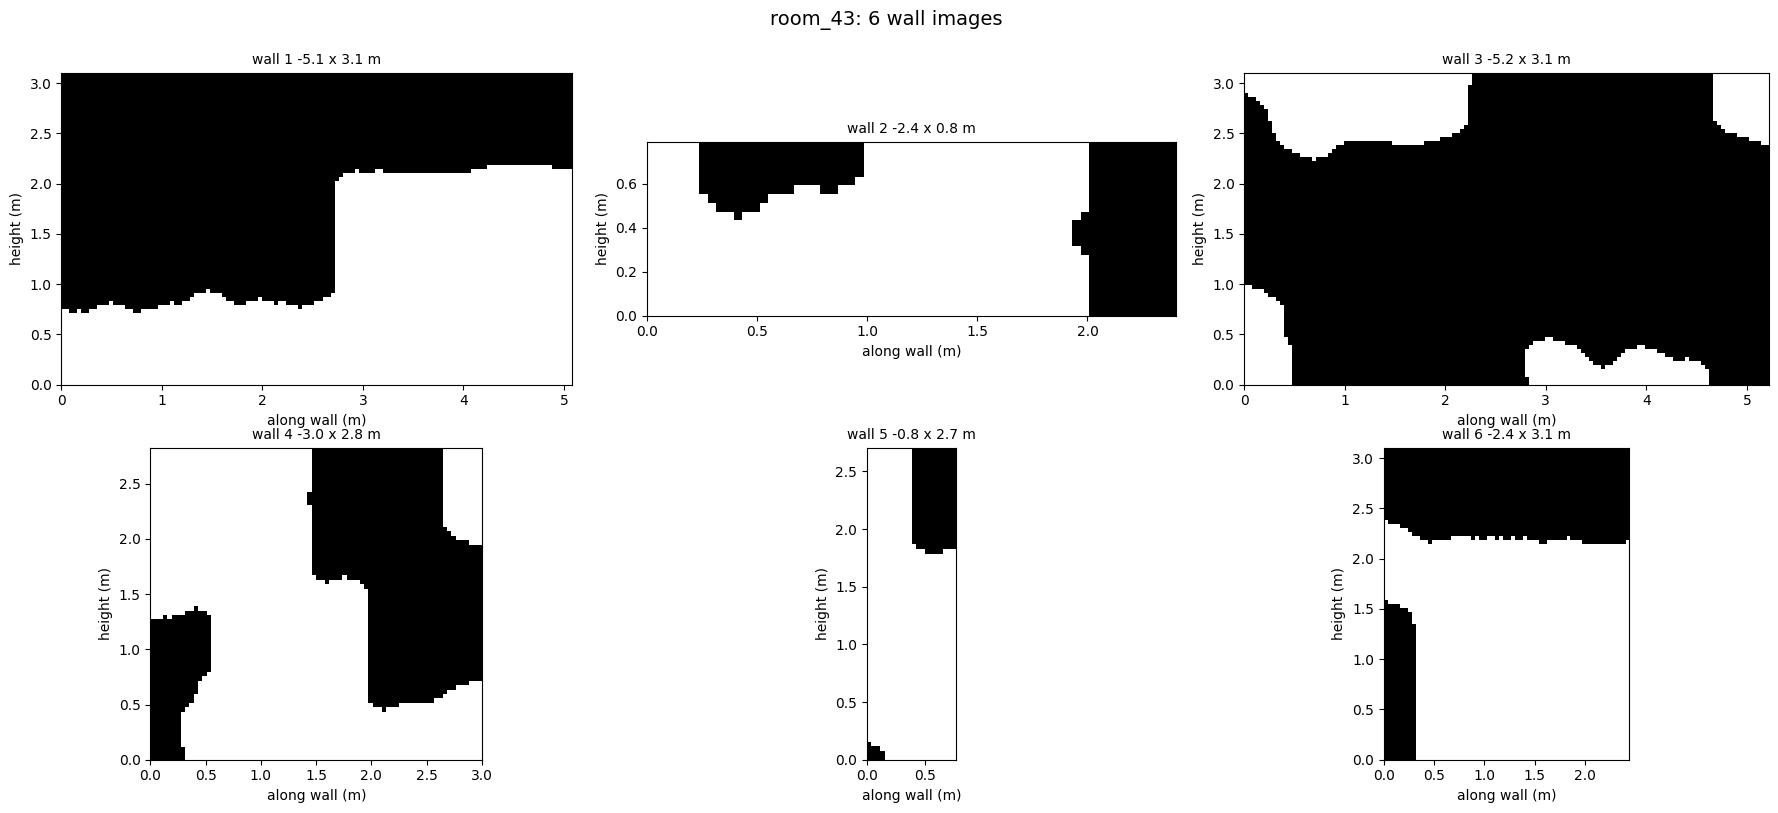

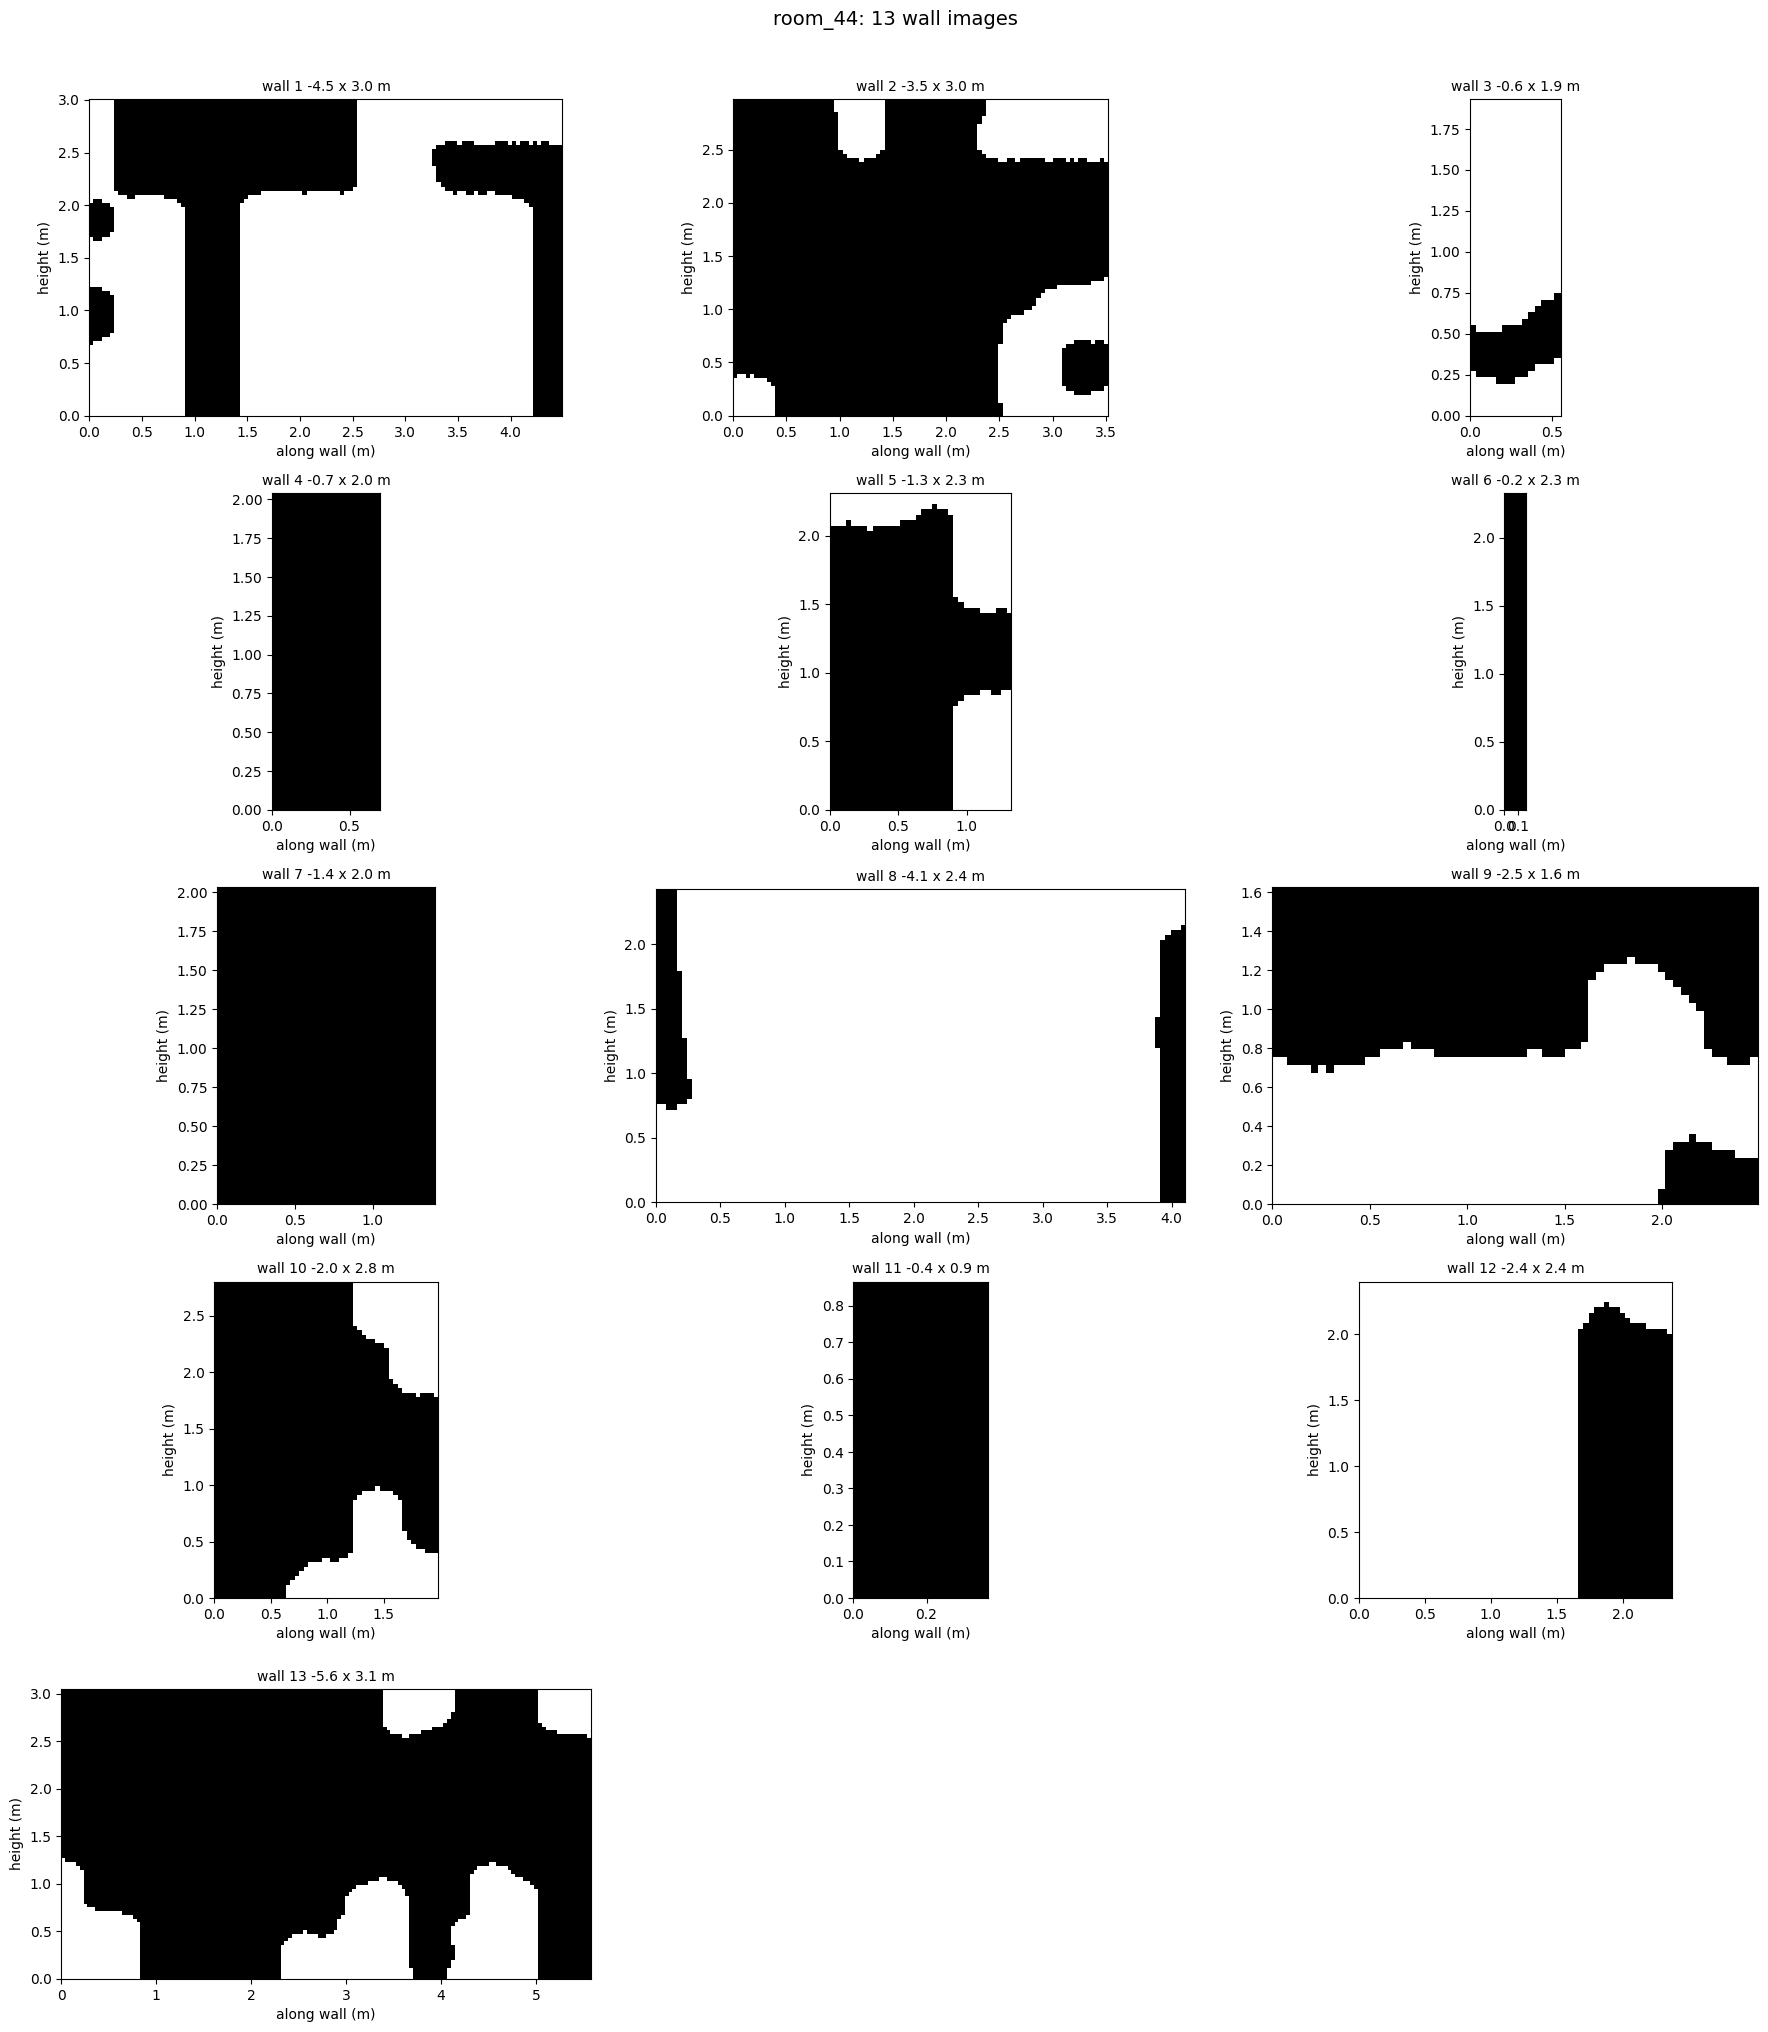

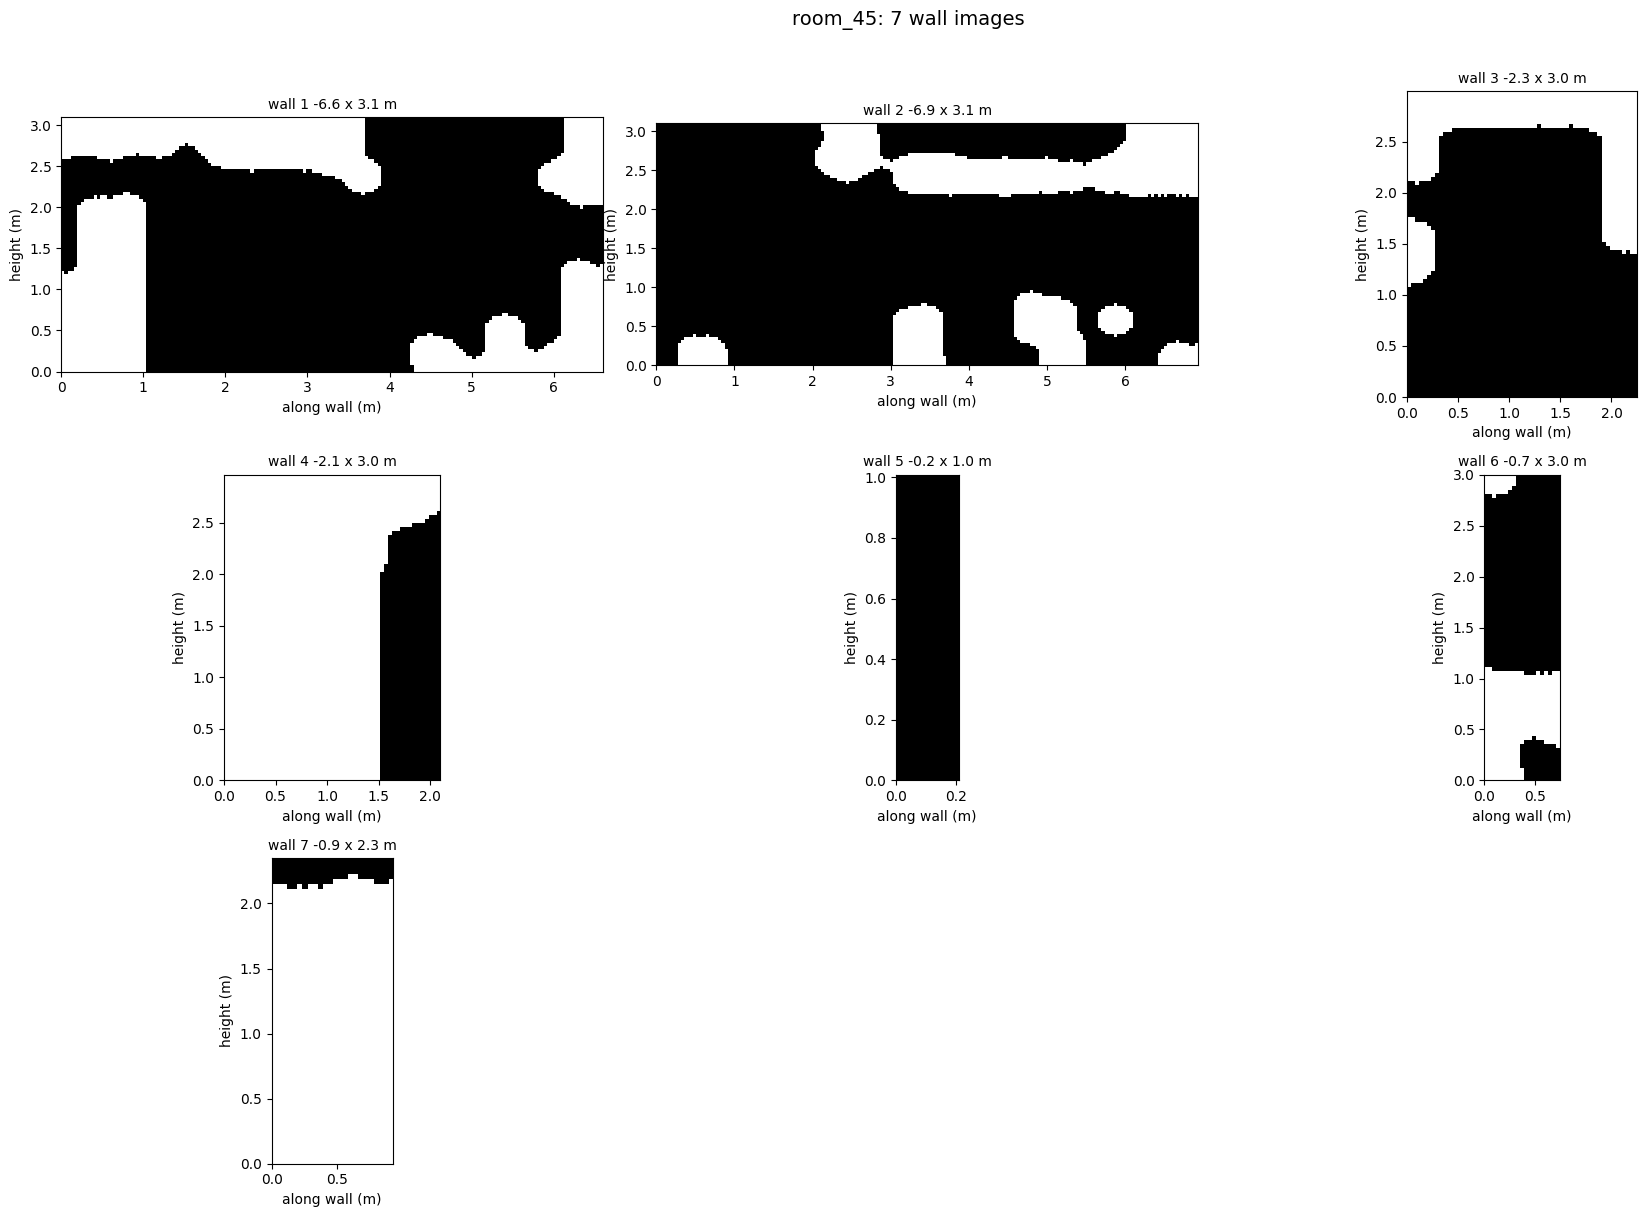

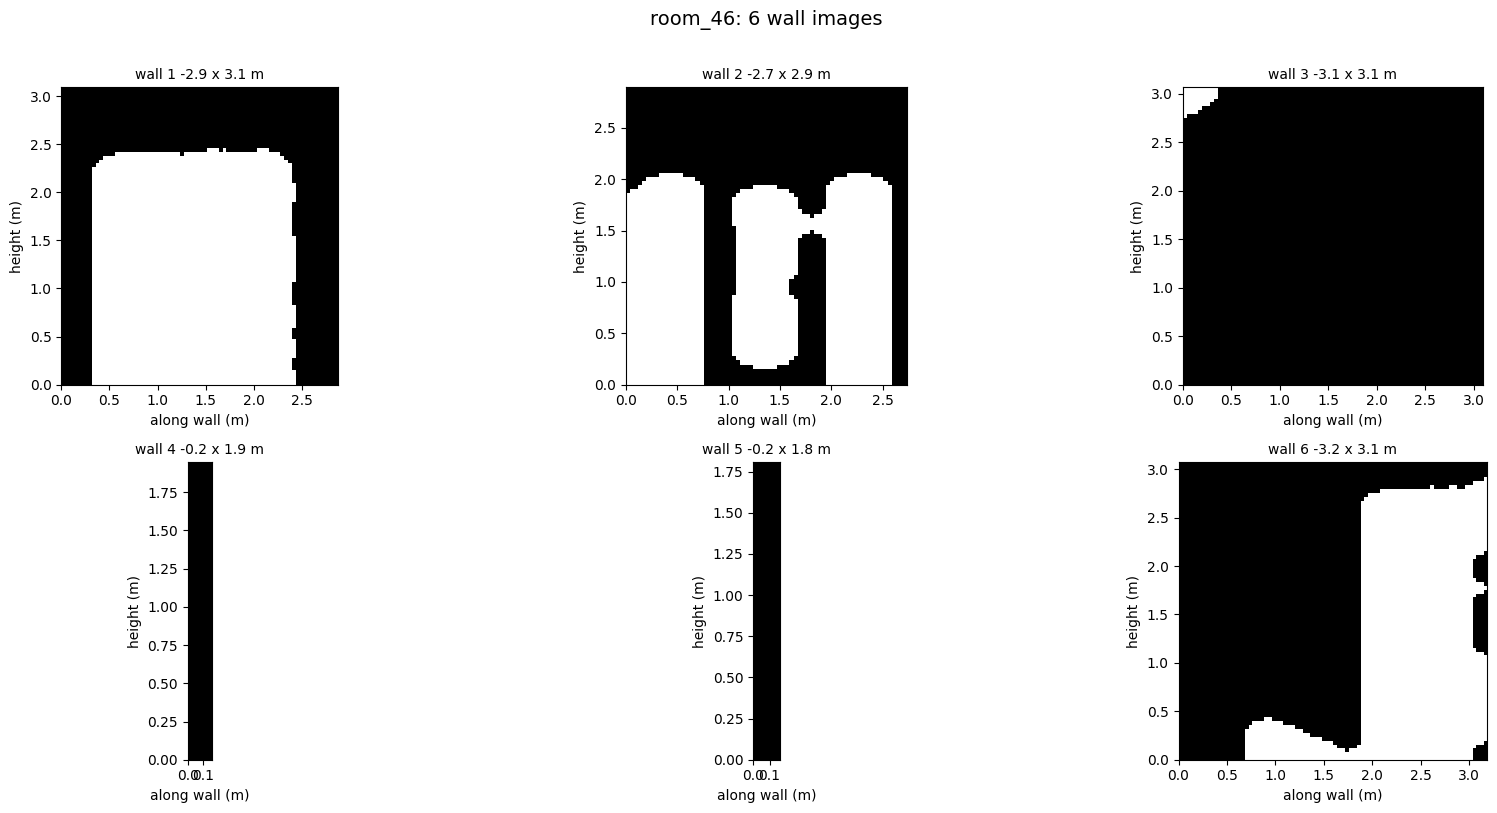

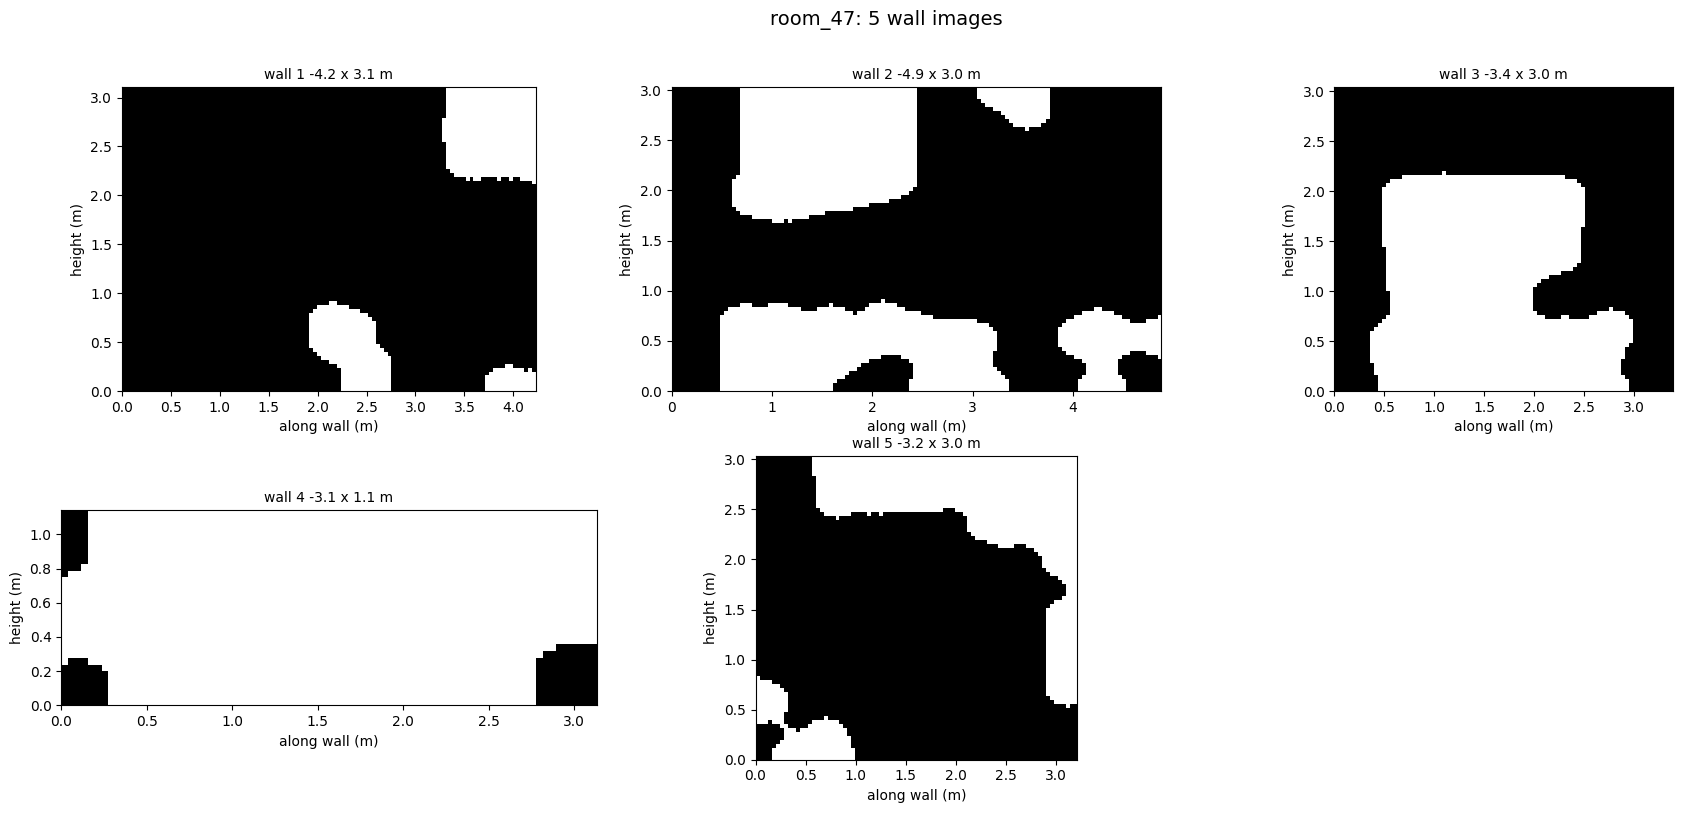

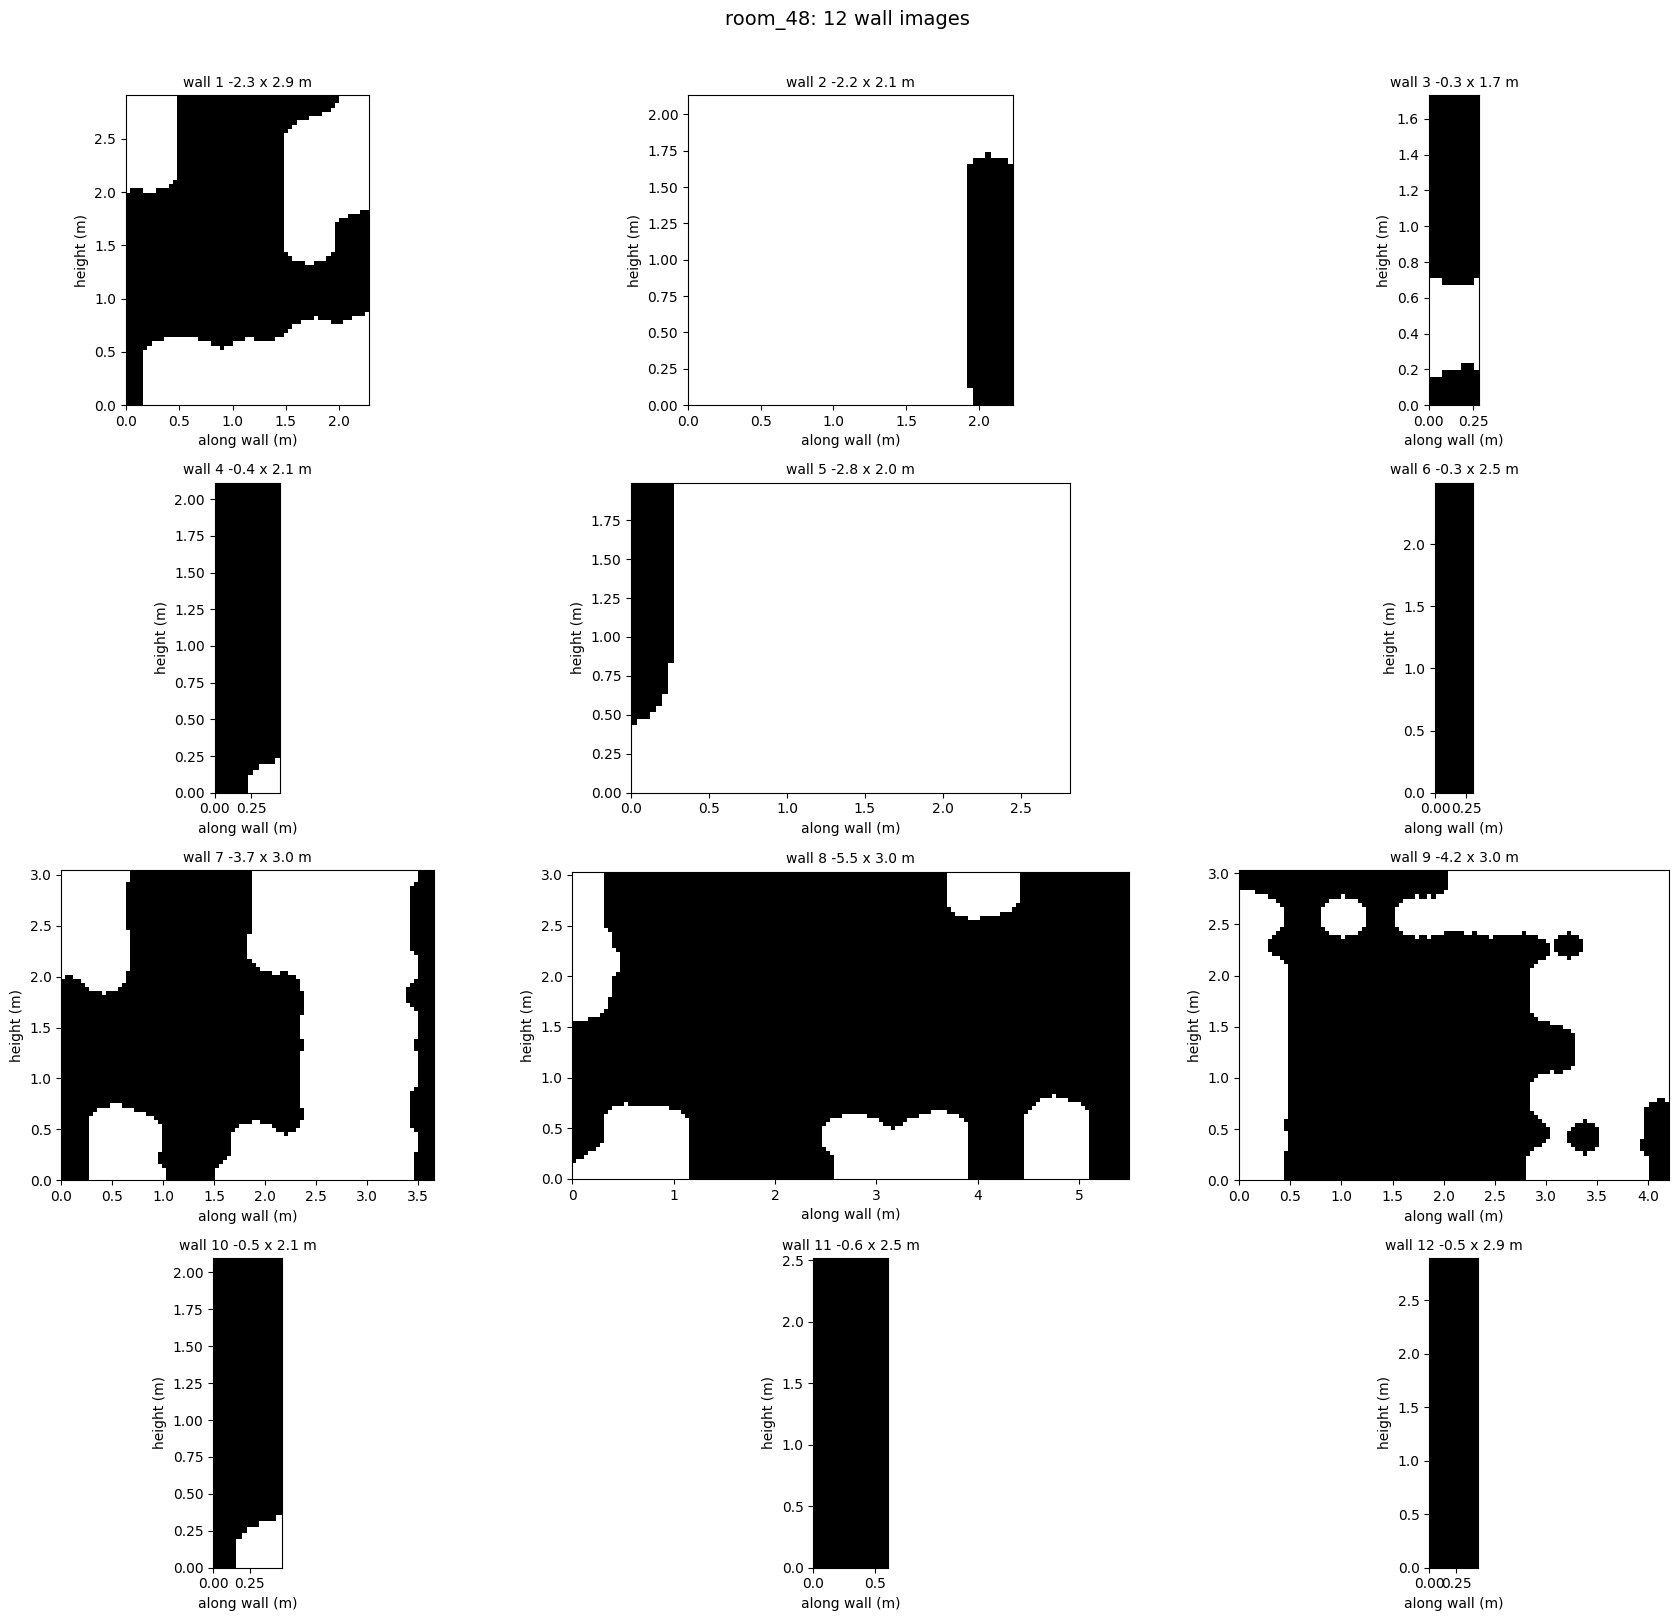

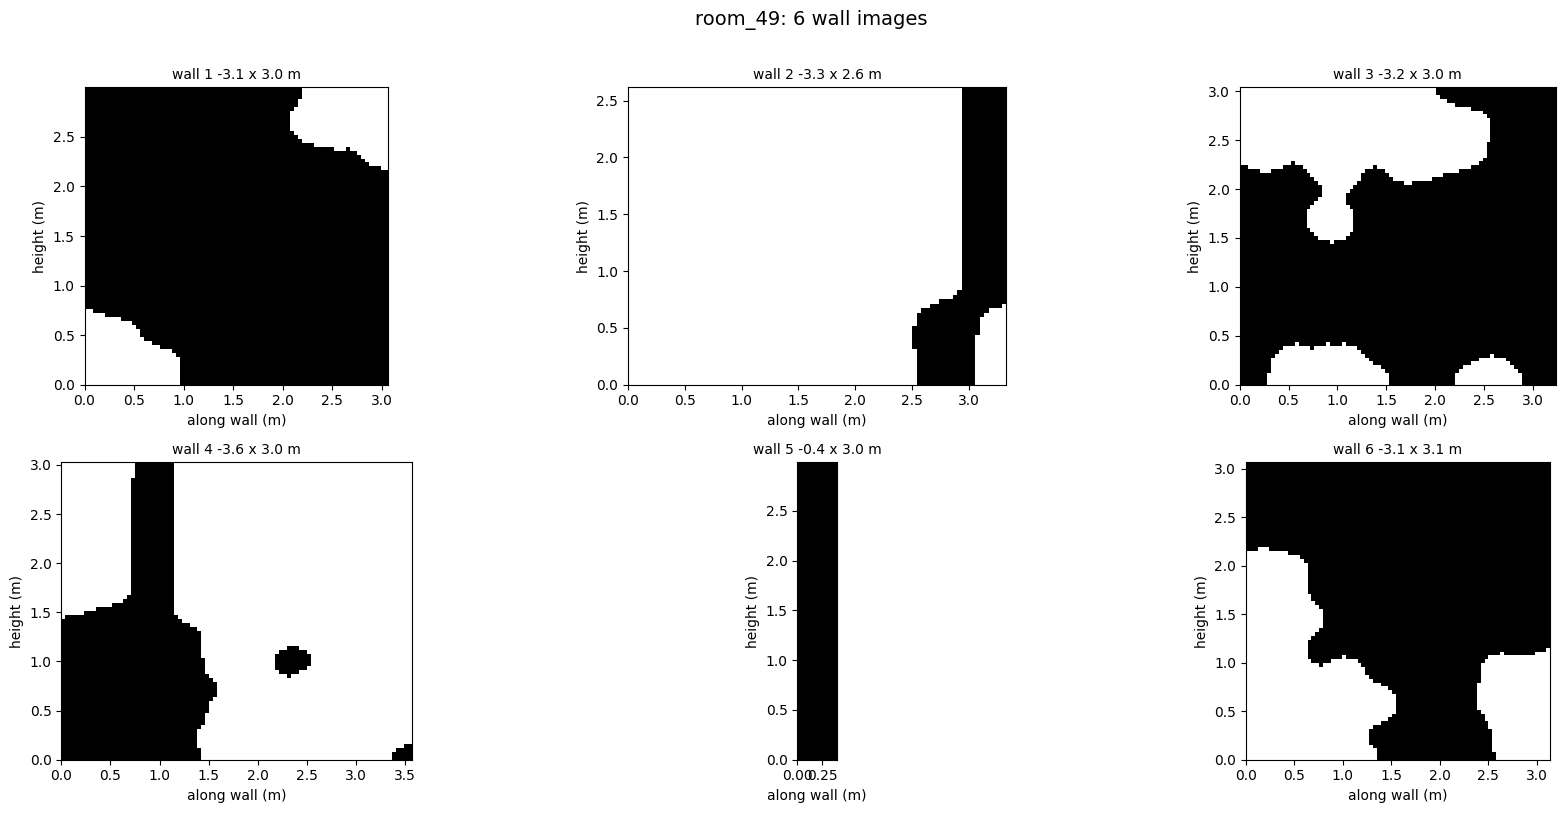

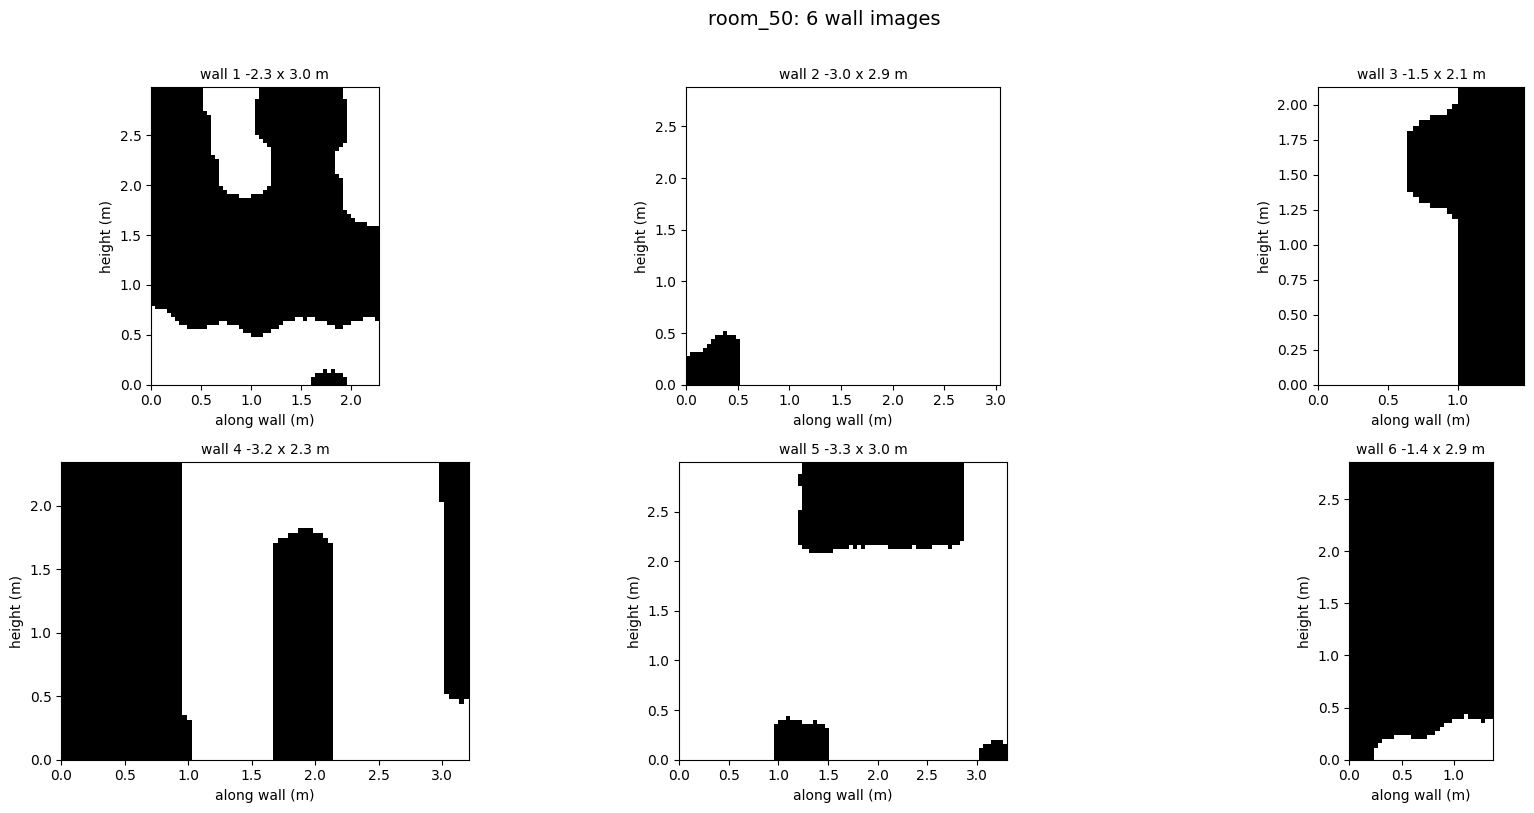

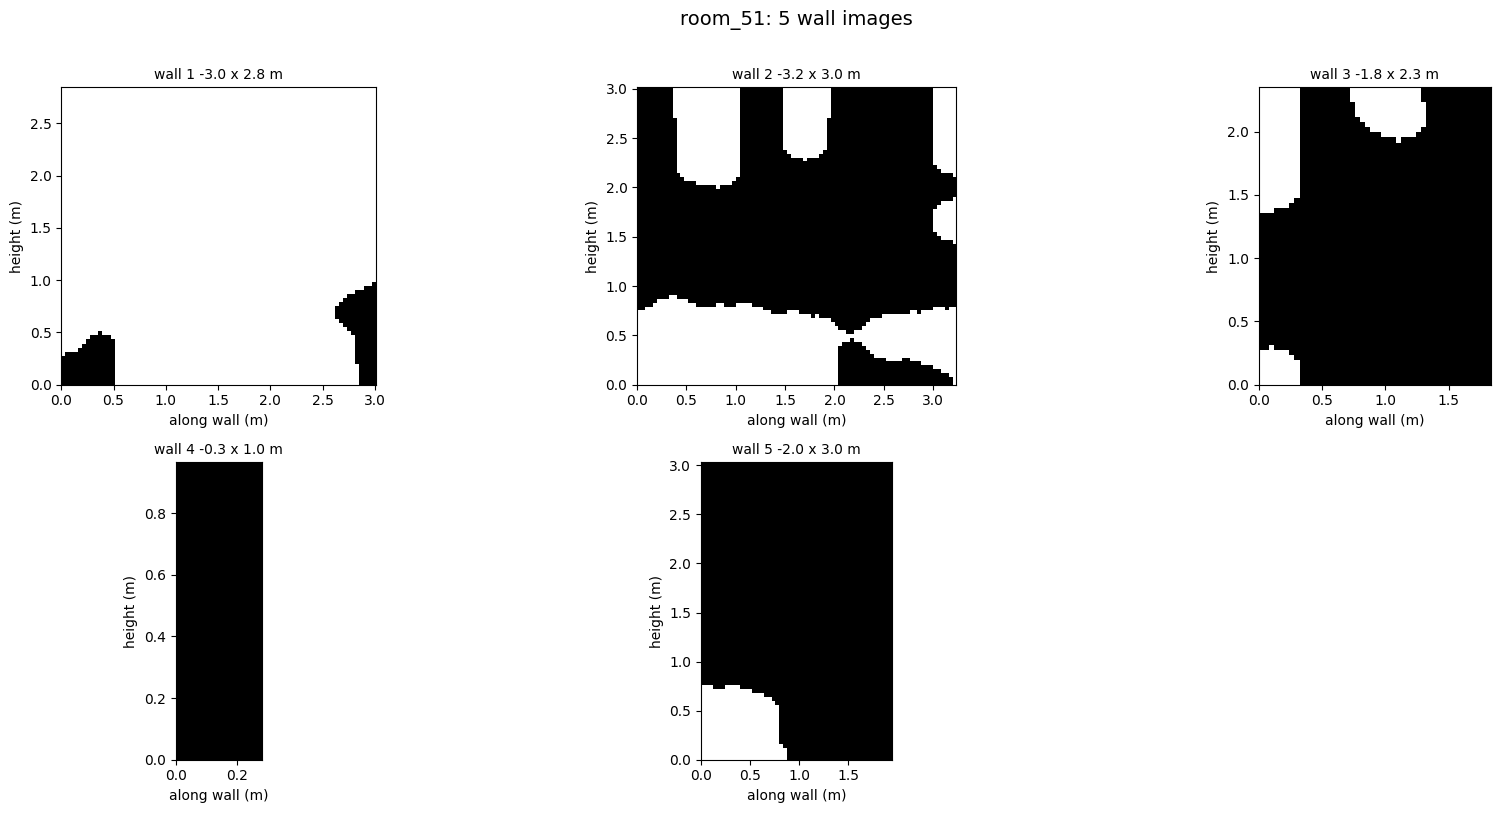

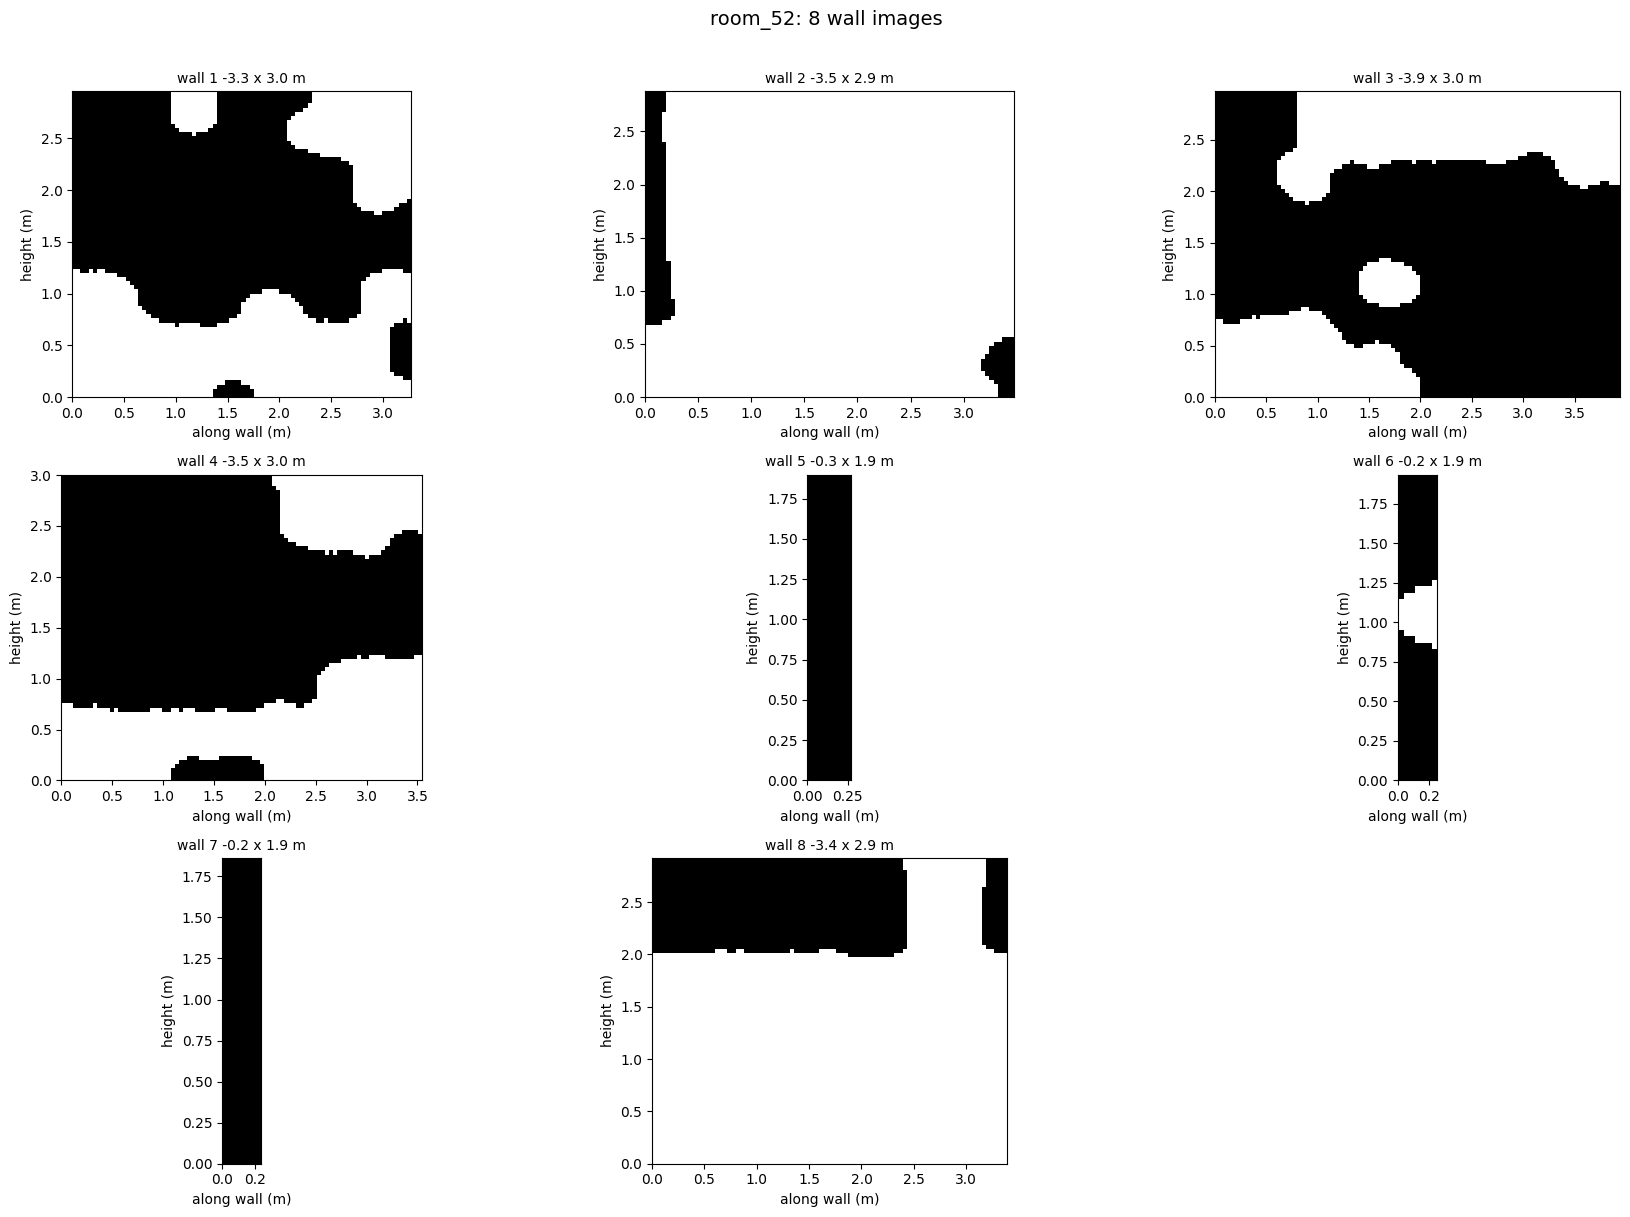

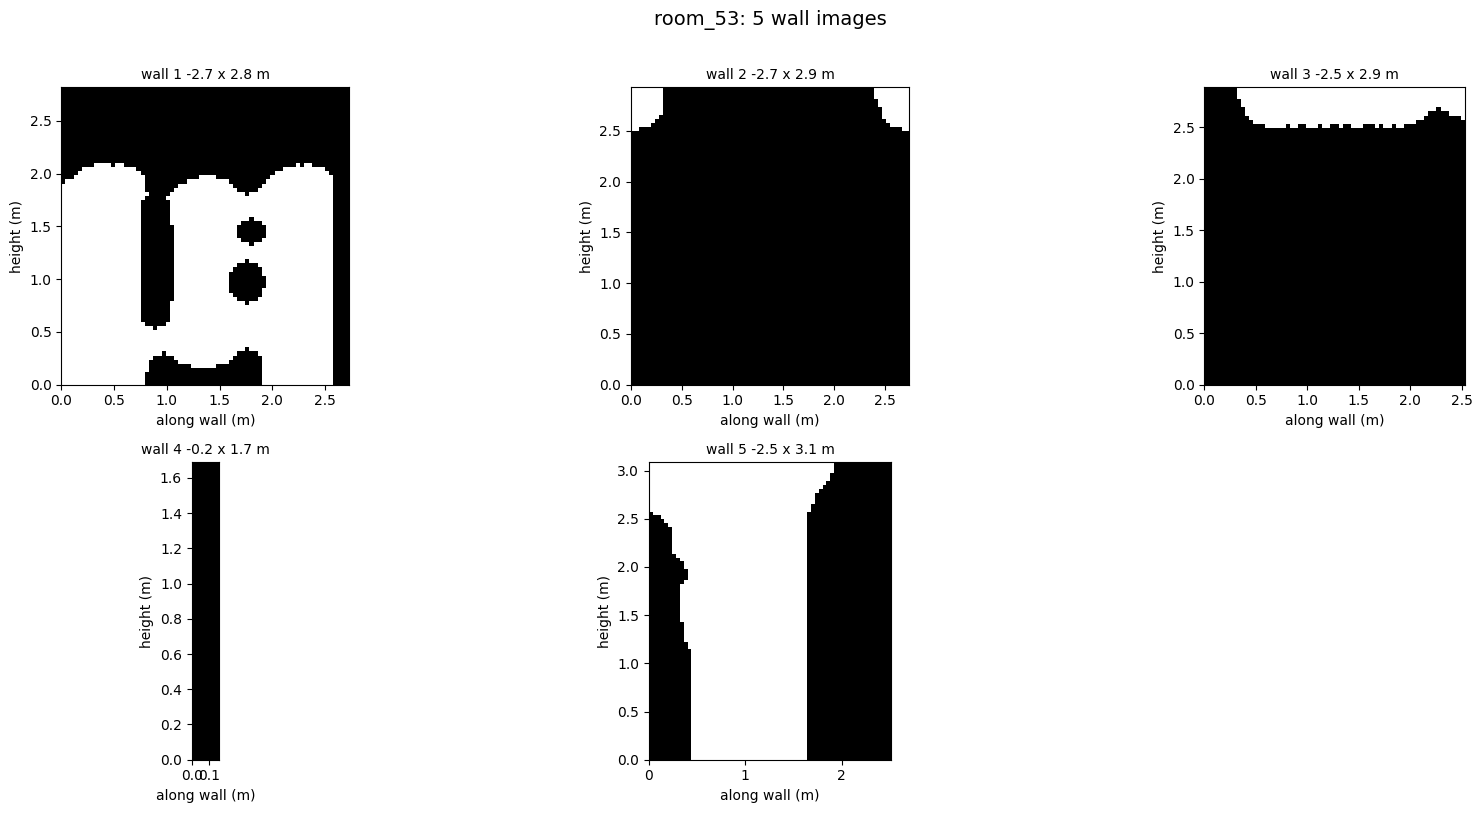

In [11]:
from scan2bim.viz import show_wall_images

for room_name, flats in results.items():
    show_wall_images(flats, room_name=room_name)

## Save config + package

In [12]:
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
z = A.package_stage(CFG.out_root, A.STAGE_WALL_SEG)
print(f'Packaged: {z}')

Packaged: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_wall_seg.zip
